# 1. Setup and Imports

Environment configuration, library imports, and hardware information for reproducibility.

In [ ]:
import os
try:
    os.listdir("/kaggle/input/")
except FileNotFoundError:
    print("Not in Kaggle environment -- running locally")

In [1]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 14.1 MB/s  0:00:00

   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   ---------------------------------------- 3/3 [shap]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import sys
import time
import platform
import multiprocessing
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import lightgbm as lgb
import shap

from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score, accuracy_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc,
                             precision_recall_curve, average_precision_score,
                             matthews_corrcoef, brier_score_loss)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from scipy import stats

warnings.filterwarnings('ignore')

In [2]:
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

In [3]:
##############################################################################
# Hardware & Environment Info (for reproducibility)
##############################################################################
print("=" * 60)
print("COMPUTATIONAL ENVIRONMENT")
print("=" * 60)
print(f"OS:            {platform.system()} {platform.release()}")
print(f"CPU:           {platform.processor()}")
print(f"CPU cores:     {os.cpu_count()} logical")
print(f"Python:        {platform.python_version()}")
print(f"PyTorch:       {torch.__version__}")
gpu_available = torch.cuda.is_available()
if gpu_available:
    print(f"GPU:           {torch.cuda.get_device_name(0)}")
    print(f"GPU count:     {torch.cuda.device_count()}")
else:
    print("GPU:           None (CPU only)")
try:
    import psutil
    ram_gb = psutil.virtual_memory().total / (1024**3)
    print(f"RAM:           {ram_gb:.1f} GB")
except ImportError:
    pass
print("=" * 60)

timing_results = {}

COMPUTATIONAL ENVIRONMENT
OS:            Linux 5.14.0-362.13.1.el9_3.x86_64
CPU:           x86_64
CPU cores:     64 logical
Python:        3.12.4
PyTorch:       2.8.0+cu128
GPU:           NVIDIA A100-SXM4-40GB
GPU count:     1
RAM:           503.0 GB


In [4]:
print(f"Total CPU cores (logical): {multiprocessing.cpu_count()}")
print(f"os.cpu_count(): {os.cpu_count()}")

Total CPU cores (logical): 64
os.cpu_count(): 64


# 2. Data Loading

Load encoded meningitis and non-meningitis datasets.

In [5]:
# Updated paths to match the exact filenames in your sidebar
meningitis_raw = pd.read_csv('full_encoded_meningitis.csv')
nonmeningitis_raw = pd.read_csv('full_encoded_non_meningitis.xls')

In [5]:
meningitis_raw = pd.read_csv('E:/Learning/NEU/Amal Lab/Meningitis paper/full_encoded_meningitis.csv')
nonmeningitis_raw = pd.read_csv('E:/Learning/NEU/Amal Lab/Meningitis paper/full_encoded_non_meningitis.xls')

# 3. Preprocessing -- Remove Leakage Columns

Exclude columns starting with '32' that directly indicate meningitis (data leakage prevention).

In [7]:
# Check whether there are meningitis related columns (starting with '32') in Meningitis dataset
print("Checking for columns starting with '32' in meningitis_raw...")
print("="*60)

# Get all column names
all_columns_men = meningitis_raw.columns.tolist()

# Find columns that start with "32"
columns_starting_32_men = [col for col in all_columns_men if str(col).startswith(('320','321','322'))]

print(f"Total columns in dataset: {len(all_columns_men)}")
print(f"Columns starting with '32': {len(columns_starting_32_men)}")
print()

if columns_starting_32_men:
    print("Found columns starting with '32':")
    print("-" * 40)
    
    # Sort the columns for better readability
    columns_starting_32_sorted_men = sorted(columns_starting_32_men)
    
    for i, col in enumerate(columns_starting_32_sorted_men, 1):
        # Check how many patients have this code
        count = meningitis_raw[col].sum() if col in meningitis_raw.columns else 0
        percentage = (count / len(meningitis_raw)) * 100 if len(meningitis_raw) > 0 else 0
        
        # Check positive rate when this code is present
        if count > 0:
            pos_rate = meningitis_raw[meningitis_raw[col] == 1]['CLASSIFIER'].mean()
        else:
            pos_rate = 0
            
        print(f"{i:2d}. {str(col):<8} - Present in {int(count):4d} patients ({percentage:5.2f}%) - Pos rate: {pos_rate:.3f}")
    
    print()
    print("Detailed analysis of '32' codes:")
    print("-" * 50)
    
    # Group by length for better understanding
    length_groups = {}
    for col in columns_starting_32_sorted_men:
        length = len(str(col))
        if length not in length_groups:
            length_groups[length] = []
        length_groups[length].append(col)
    
    for length in sorted(length_groups.keys()):
        print(f"\nLength {length} codes ({len(length_groups[length])} codes):")
        for col in length_groups[length]:
            count = int(meningitis_raw[col].sum())
            percentage = (count / len(meningitis_raw)) * 100
            if count > 0:
                pos_rate = meningitis_raw[meningitis_raw[col] == 1]['CLASSIFIER'].mean()
                print(f"  {str(col)}: {count} patients ({percentage:.2f}%) - Meningitis rate: {pos_rate:.3f}")
            else:
                print(f"  {str(col)}: {count} patients ({percentage:.2f}%) - No patients with this code")

Checking for columns starting with '32' in meningitis_raw...
Total columns in dataset: 983
Columns starting with '32': 14

Found columns starting with '32':
----------------------------------------
 1. 3200     - Present in    2 patients ( 0.93%) - Pos rate: 1.000
 2. 3201     - Present in   13 patients ( 6.07%) - Pos rate: 1.000
 3. 3202     - Present in   16 patients ( 7.48%) - Pos rate: 1.000
 4. 3203     - Present in   26 patients (12.15%) - Pos rate: 1.000
 5. 3207     - Present in    7 patients ( 3.27%) - Pos rate: 1.000
 6. 32082    - Present in   23 patients (10.75%) - Pos rate: 1.000
 7. 32089    - Present in    3 patients ( 1.40%) - Pos rate: 1.000
 8. 3209     - Present in   24 patients (11.21%) - Pos rate: 1.000
 9. 3210     - Present in    6 patients ( 2.80%) - Pos rate: 1.000
10. 3212     - Present in    1 patients ( 0.47%) - Pos rate: 1.000
11. 3220     - Present in    5 patients ( 2.34%) - Pos rate: 1.000
12. 3221     - Present in    1 patients ( 0.47%) - Pos rate: 1.00

In [8]:
# Check whether there are meningitis related columns (starting with '32') in non-meningitis dataset
print("Checking for columns starting with '32' in nonmeningitis_raw...")
print("="*60)

# Get all column names
all_columns_nonmen = nonmeningitis_raw.columns.tolist()

# Find columns that start with "32"
columns_starting_32_nonmen = [col for col in all_columns_nonmen if str(col).startswith(('320','321','322'))]

print(f"Total columns in dataset: {len(all_columns_nonmen)}")
print(f"Columns starting with '32': {len(columns_starting_32_nonmen)}")
print()

if columns_starting_32_nonmen:
    print("Found columns starting with '32':")
    print("-" * 40)
    
    # Sort the columns for better readability
    columns_starting_32_sorted_nonmen = sorted(columns_starting_32_nonmen)
    
    for i, col in enumerate(columns_starting_32_sorted_nonmen, 1):
        # Check how many patients have this code
        count = nonmeningitis_raw[col].sum() if col in nonmeningitis_raw.columns else 0
        percentage = (count / len(nonmeningitis_raw)) * 100 if len(nonmeningitis_raw) > 0 else 0
        
        # Check positive rate when this code is present
        if count > 0:
            pos_rate = nonmeningitis_raw[nonmeningitis_raw[col] == 1]['CLASSIFIER'].mean()
        else:
            pos_rate = 0
            
        print(f"{i:2d}. {str(col):<8} - Present in {int(count):4d} patients ({percentage:5.2f}%) - Pos rate: {pos_rate:.3f}")
    
    print()
    print("Detailed analysis of '32' codes:")
    print("-" * 50)
    
    # Group by length for better understanding
    length_groups = {}
    for col in columns_starting_32_sorted_nonmen:
        length = len(str(col))
        if length not in length_groups:
            length_groups[length] = []
        length_groups[length].append(col)
    
    for length in sorted(length_groups.keys()):
        print(f"\nLength {length} codes ({len(length_groups[length])} codes):")
        for col in length_groups[length]:
            count = int(nonmeningitis_raw[col].sum())
            percentage = (count / len(nonmeningitis_raw)) * 100
            if count > 0:
                pos_rate = nonmeningitis_raw[nonmeningitis_raw[col] == 1]['CLASSIFIER'].mean()
                print(f"  {str(col)}: {count} patients ({percentage:.2f}%) - Meningitis rate: {pos_rate:.3f}")
            else:
                print(f"  {str(col)}: {count} patients ({percentage:.2f}%) - No patients with this code")

Checking for columns starting with '32' in nonmeningitis_raw...
Total columns in dataset: 6962
Columns starting with '32': 0



In [9]:
# # Create new dataset without meningitis code columns
meningitis_clean = meningitis_raw.drop(columns=columns_starting_32_men)

In [10]:
# Check columns that start with "('320','321','322')"
all_columns_clean_men = meningitis_clean.columns.tolist()

columns_starting_32_clean = [col for col in all_columns_clean_men if str(col).startswith(('320','321','322'))]

print(f"Total columns in dataset: {len(all_columns_clean_men)}")
print(f"Columns starting with '('320','321','322')': {len(columns_starting_32_clean)}")
print()

Total columns in dataset: 969
Columns starting with '('320','321','322')': 0



In [11]:
(nonmeningitis_raw["CLASSIFIER"] == 1).any()

False

In [12]:
print(meningitis_clean.shape)
print(nonmeningitis_raw.shape)
print(meningitis_clean.head)
print(nonmeningitis_raw.head)

(214, 969)
(46303, 6962)
<bound method NDFrame.head of      SUBJECT_ID  GENDER  00845  0090  0270  0362  0380  03811  03812  03819  \
0         10144       0      0     0     0     0     0      0      1      0   
1         10316       1      0     0     0     0     0      0      0      0   
2         10361       0      1     0     0     0     0      0      0      0   
3         10614       1      0     0     0     0     0      0      0      0   
4         11093       0      0     0     0     0     0      0      0      0   
..          ...     ...    ...   ...   ...   ...   ...    ...    ...    ...   
209         994       0      0     0     0     0     0      0      0      0   
210        9971       0      0     0     0     0     0      0      0      0   
211       99776       1      0     0     0     0     0      0      0      0   
212        9981       0      0     0     0     0     0      0      0      0   
213       99957       1      0     0     0     0     0      0      0      0 

# 4. Train/Test Splitting and Sampling

Stratified sampling of meningitis and non-meningitis cohorts for training and testing.

In [13]:
# Ramdonly extract 180 samples for training set and 34 samples for testing set in meningitis cohort
men_180 = meningitis_clean.sample(n=180, random_state=42)
men_34 = meningitis_clean.drop(men_180.index)

In [14]:
print(men_180.head)
print(men_34.head)

<bound method NDFrame.head of      SUBJECT_ID  GENDER  00845  0090  0270  0362  0380  03811  03812  03819  \
9          1241       1      0     0     0     0     0      0      0      0   
197       87279       1      0     0     0     0     0      0      0      0   
66        25995       1      0     0     0     0     0      0      0      0   
191       83132       1      0     0     0     0     0      0      0      0   
117       48876       0      1     0     0     0     0      0      0      0   
..          ...     ...    ...   ...   ...   ...   ...    ...    ...    ...   
54        23385       1      0     0     0     0     0      0      0      0   
107       44793       0      0     0     0     0     0      0      0      0   
50        22894       0      0     0     0     0     0      0      0      0   
174        7466       1      0     0     0     0     0      0      0      0   
210        9971       0      0     0     0     0     0      0      0      0   

     ...  V600  V602 

In [15]:
# Ramdonly extract 38955 samples for training set and 7348 samples for testing set in the non-meningitis cohort
non_men_38955 = nonmeningitis_raw.sample(n=38955, random_state=42)
non_men_7348 = nonmeningitis_raw.drop(non_men_38955.index)

In [47]:
# Extract samples from non_men_38955 that at least 1 of the top-100 most important features has a value of 1
def extract_negatives_with_topk_ones(non_men_38955: pd.DataFrame,
                                     top_100_features,
                                     k: int = 1) -> pd.DataFrame:
    """
    Keep rows where at least k of the top-100 features == 1 (or True).
    - negative_samples: DataFrame with 0/1 (or bool) feature columns
    - top_100_features: iterable of feature names (list/Index)
    - k: threshold count (default 1)
    """
    cols = [c for c in top_100_features if c in non_men_38955.columns]
    if not cols:
        return non_men_38955.iloc[0:0].copy()

    sub = non_men_38955[cols]
    # Count how many of the selected features are 1/True in each row
    hits = (sub.eq(1) | sub.eq(True)).sum(axis=1)
    return non_men_38955.loc[hits >= k].copy()

# Example
nonmen_1plus = extract_negatives_with_topk_ones(non_men_38955, top_100_features, k=1)
print(nonmen_1plus.shape)

(38184, 6962)


In [17]:
# Ramdonly extract 180 and 8000 samples for training set in the non-meningitis cohort
non_men_180 = non_men_38955.sample(n=180, random_state=42)

# Randonly extract 180*10 = 1800, 180*20 = 3600, 180*30 = 5400 from 38955 non-meningitis samples for model training with Case-control subgroups
non_men_1800 = non_men_38955.sample(n=1800, random_state=42)
non_men_3600 = non_men_38955.sample(n=3600, random_state=42)
non_men_5400 = non_men_38955.sample(n=5400, random_state=42)

In [48]:
non_men_180_sim = nonmen_1plus.sample(n=180, random_state=42)
non_men_1800_sim = nonmen_1plus.sample(n=1800, random_state=42)
non_men_3600_sim = nonmen_1plus.sample(n=3600, random_state=42)
non_men_5400_sim = nonmen_1plus.sample(n=5400, random_state=42)

In [49]:
print(non_men_38955.head)
print(non_men_7348.head)
print(non_men_180.head)
print(non_men_1800.head)
print(non_men_3600.head)
print(non_men_5400.head)
print(non_men_180_sim.head)
print(non_men_1800_sim.head)
print(non_men_3600_sim.head)

<bound method NDFrame.head of        SUBJECT_ID  GENDER  0030  0031  0038  0039  0041  0048  0049  0051  \
27088       47410       1     0     0     0     0     0     0     0     0   
36936       74284       1     0     0     0     0     0     0     0     0   
35360       69781       1     0     0     0     0     0     0     0     0   
40875        8507       0     0     0     0     0     0     0     0     0   
29586       54172       1     0     0     0     0     0     0     0     0   
...           ...     ...   ...   ...   ...   ...   ...   ...   ...   ...   
27370       48149       1     0     0     0     0     0     0     0     0   
8399        18031       1     0     0     0     0     0     0     0     0   
9079        18692       0     0     0     0     0     0     0     0     0   
524         10495       0     0     0     0     0     0     0     0     0   
42392        8930       1     0     0     0     0     0     0     0     0   

       ...  V8811  V8812  V8821  V9010  V902 

In [20]:
# Combine data for training set and testing set
training_combined = pd.concat([men_180, non_men_38955], ignore_index = True)

# Combine data for training set 
# This is useful for testing purposes or small-scale experiments
training_combined_360 = pd.concat([men_180, non_men_180], ignore_index = True)
training_combined_1980 = pd.concat([men_180, non_men_1800], ignore_index = True)
training_combined_3780 = pd.concat([men_180, non_men_3600], ignore_index = True)
training_combined_5580 = pd.concat([men_180, non_men_5400], ignore_index = True)
testing_combined_7382 = pd.concat([men_34, non_men_7348], ignore_index = True)

In [50]:
# Combine data for training set of simulation
training_combined_360_sim = pd.concat([men_180, non_men_180_sim], ignore_index = True)
training_combined_1980_sim = pd.concat([men_180, non_men_1800_sim], ignore_index = True)
training_combined_3780_sim = pd.concat([men_180, non_men_3600_sim], ignore_index = True)
training_combined_5580_sim = pd.concat([men_180, non_men_5400_sim], ignore_index = True)

In [22]:
# Drop SUBJECT_ID of training sets
training_ID_Drop = training_combined.drop('SUBJECT_ID', axis = 1)
training_ID_Drop_360 = training_combined_360.drop('SUBJECT_ID', axis = 1)
training_ID_Drop_1980 = training_combined_1980.drop('SUBJECT_ID', axis = 1)
training_ID_Drop_3780 = training_combined_3780.drop('SUBJECT_ID', axis = 1)
training_ID_Drop_5580 = training_combined_5580.drop('SUBJECT_ID', axis = 1)

# Drop SUBJECT_ID of testing sets
testing_ID_Drop_7382 = testing_combined_7382.drop('SUBJECT_ID', axis = 1)

In [51]:
training_ID_Drop_360_sim = training_combined_360_sim.drop('SUBJECT_ID', axis = 1)
training_ID_Drop_1980_sim = training_combined_1980_sim.drop('SUBJECT_ID', axis = 1)
training_ID_Drop_3780_sim = training_combined_3780_sim.drop('SUBJECT_ID', axis = 1)
training_ID_Drop_5580_sim = training_combined_5580_sim.drop('SUBJECT_ID', axis = 1)

In [24]:
# Shuffle the training datasets to ensure random distribution
training_shuffled = training_ID_Drop.sample(frac=1, random_state=42).reset_index(drop=True)
training_shuffled_360 = training_ID_Drop_360.sample(frac=1, random_state=42).reset_index(drop=True)
training_shuffled_1980 = training_ID_Drop_1980.sample(frac=1, random_state=42).reset_index(drop=True)
training_shuffled_3780 = training_ID_Drop_3780.sample(frac=1, random_state=42).reset_index(drop=True)
training_shuffled_5580 = training_ID_Drop_5580.sample(frac=1, random_state=42).reset_index(drop=True)

# Shuffle the testing datasets to ensure random distribution
testing_shuffled_7382 = testing_ID_Drop_7382.sample(frac=1, random_state=42).reset_index(drop=True)

In [52]:
training_shuffled_360_sim = training_ID_Drop_360_sim.sample(frac=1, random_state=42).reset_index(drop=True)
training_shuffled_1980_sim = training_ID_Drop_1980_sim.sample(frac=1, random_state=42).reset_index(drop=True)
training_shuffled_3780_sim = training_ID_Drop_3780_sim.sample(frac=1, random_state=42).reset_index(drop=True)
training_shuffled_5580_sim = training_ID_Drop_5580_sim.sample(frac=1, random_state=42).reset_index(drop=True)

In [26]:
print(training_shuffled.shape)
print(training_shuffled_360.shape)
print(training_shuffled_1980.shape)
print(training_shuffled_3780.shape)
print(training_shuffled_5580.shape)

print(testing_shuffled_7382.shape)

(39135, 6970)
(360, 6970)
(1980, 6970)
(3780, 6970)
(5580, 6970)
(7382, 6970)


In [27]:
# Check for NaN values in each dataset
print("NaN values in training data:\n", training_shuffled.isnull().sum())
print("\n" + "NaN values in training data (360 samples):\n", training_shuffled_360.isnull().sum())
print("\n" + "NaN values in training data (1980 samples):\n", training_shuffled_1980.isnull().sum())
print("\n" + "NaN values in training data (3780 samples):\n", training_shuffled_3780.isnull().sum())
print("\n" + "NaN values in training data (5580 samples):\n", training_shuffled_5580.isnull().sum())
print("\n" + "NaN values in testing data with 7382 samples:\n", testing_shuffled_7382.isnull().sum())

NaN values in training data:
 GENDER      0
00845       0
0090        0
0270        0
0362        0
         ... 
V902      180
V9039     180
V9081     180
V9089     180
V9103     180
Length: 6970, dtype: int64

NaN values in training data (360 samples):
 GENDER      0
00845       0
0090        0
0270        0
0362        0
         ... 
V902      180
V9039     180
V9081     180
V9089     180
V9103     180
Length: 6970, dtype: int64

NaN values in training data (1980 samples):
 GENDER      0
00845       0
0090        0
0270        0
0362        0
         ... 
V902      180
V9039     180
V9081     180
V9089     180
V9103     180
Length: 6970, dtype: int64

NaN values in training data (3780 samples):
 GENDER      0
00845       0
0090        0
0270        0
0362        0
         ... 
V902      180
V9039     180
V9081     180
V9089     180
V9103     180
Length: 6970, dtype: int64

NaN values in training data (5580 samples):
 GENDER      0
00845       0
0090        0
0270        0
0362   

In [53]:
df_training_360_sim = training_shuffled_360_sim.fillna(0)
df_training_1980_sim = training_shuffled_1980_sim.fillna(0)
df_training_3780_sim = training_shuffled_3780_sim.fillna(0)
df_training_5580_sim = training_shuffled_5580_sim.fillna(0)

In [54]:
df_training_360_sim.shape
df_training_1980_sim.shape
df_training_3780_sim.shape
df_training_5580_sim.shape

(5580, 6970)

In [30]:
# Replace NaN values with 0 in each dataset
df_training = training_shuffled.fillna(0)
df_training_360 = training_shuffled_360.fillna(0)
df_training_1980 = training_shuffled_1980.fillna(0)
df_training_3780 = training_shuffled_3780.fillna(0)
df_training_5580 = training_shuffled_5580.fillna(0)
df_testing_7382 = testing_shuffled_7382.fillna(0)
# Verify if NaN values are replaced
print("NaN values in df_training:\n", df_training.isnull().sum())
print("\nNaN values in df_testing:\n", df_testing_7382.isnull().sum())
print("\nNaN values in df_training_1980:\n", df_training_1980.isnull().sum())
print("\nNaN values in df_training_3780:\n", df_training_3780.isnull().sum())
print("\nNaN values in df_training_5580:\n", df_training_5580.isnull().sum())


NaN values in df_training:
 GENDER    0
00845     0
0090      0
0270      0
0362      0
         ..
V902      0
V9039     0
V9081     0
V9089     0
V9103     0
Length: 6970, dtype: int64

NaN values in df_testing:
 GENDER    0
00845     0
0090      0
0270      0
0362      0
         ..
V902      0
V9039     0
V9081     0
V9089     0
V9103     0
Length: 6970, dtype: int64

NaN values in df_training_1980:
 GENDER    0
00845     0
0090      0
0270      0
0362      0
         ..
V902      0
V9039     0
V9081     0
V9089     0
V9103     0
Length: 6970, dtype: int64

NaN values in df_training_3780:
 GENDER    0
00845     0
0090      0
0270      0
0362      0
         ..
V902      0
V9039     0
V9081     0
V9089     0
V9103     0
Length: 6970, dtype: int64

NaN values in df_training_5580:
 GENDER    0
00845     0
0090      0
0270      0
0362      0
         ..
V902      0
V9039     0
V9081     0
V9089     0
V9103     0
Length: 6970, dtype: int64


In [31]:
# Check duplicate column names in training data
duplicate_columns = df_training_360.columns[df_training_360.columns.duplicated()].unique()
duplicate_columns_1980 = df_training_1980.columns[df_training_1980.columns.duplicated()].unique()
duplicate_columns_3780 = df_training_3780.columns[df_training_3780.columns.duplicated()].unique()
duplicate_columns_5580 = df_training_5580.columns[df_training_5580.columns.duplicated()].unique()

print(duplicate_columns)
print(duplicate_columns_1980)
print(duplicate_columns_3780)
print(duplicate_columns_5580)


Index([], dtype='object')
Index([], dtype='object')
Index([], dtype='object')
Index([], dtype='object')


# 5. Feature Engineering -- Feature Importance

1. Identify features most related to meningitis.
2. Construct simulated ER scenario with challenging non-meningitis cases.

In [32]:
# Separate features and labels
X = df_training.drop('CLASSIFIER', axis=1)
y = df_training['CLASSIFIER']

print("Class distribution:")
print(y.value_counts())
print(f"Positive class ratio: {y.mean():.4f}")
print()

Class distribution:
CLASSIFIER
0    38955
1      180
Name: count, dtype: int64
Positive class ratio: 0.0046



In [33]:
# Train Random Forest for feature importance
print("Training Random Forest for feature importance...")
rf_importance = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # Handle class imbalance
)

rf_importance.fit(X, y)

Training Random Forest for feature importance...


RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [34]:
# Get feature importances
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_importance.feature_importances_
}).sort_values('importance', ascending=False)

In [35]:
print(feature_importance_df.head(100))

    feature  importance
338   41401    0.029788
232    3314    0.023201
373     430    0.018300
809   99663    0.015618
712   78039    0.014837
..      ...         ...
386    4373    0.002293
30      042    0.002284
631   73300    0.002279
895   V1011    0.002256
38     0549    0.002236

[100 rows x 2 columns]


In [36]:
print("Top 100 most important features:")
print("-" * 50)
for i, (idx, row) in enumerate(feature_importance_df.head(100).iterrows(), 1):
    print(f"{i:2d}. {row['feature']:8s} : {row['importance']:.6f}")

print("/n" + "Feature importance distribution:")
print(f"Max importance: {feature_importance_df['importance'].max():.6f}")
print(f"Mean importance: {feature_importance_df['importance'].mean():.6f}")
print(f"Min importance: {feature_importance_df['importance'].min():.6f}")
print(f"Features with importance > 0.001: {(feature_importance_df['importance'] > 0.001).sum()}")

Top 100 most important features:
--------------------------------------------------
 1. 41401    : 0.029788
 2. 3314     : 0.023201
 3. 430      : 0.018300
 4. 99663    : 0.015618
 5. 78039    : 0.014837
 6. 431      : 0.014136
 7. V290     : 0.013691
 8. GENDER   : 0.010588
 9. V053     : 0.010376
10. 42731    : 0.009854
11. 7907     : 0.009410
12. 51881    : 0.009336
13. 4019     : 0.009102
14. 2761     : 0.008943
15. 4280     : 0.006816
16. 77181    : 0.006478
17. 2724     : 0.006309
18. 5849     : 0.006135
19. 769      : 0.005922
20. 3453     : 0.005913
21. 7766     : 0.005811
22. 53081    : 0.005757
23. 99592    : 0.005752
24. 3829     : 0.005682
25. 25000    : 0.005658
26. 3240     : 0.005648
27. 08881    : 0.005647
28. 496      : 0.005627
29. 03811    : 0.005466
30. 2760     : 0.005284
31. 3510     : 0.005192
32. 5990     : 0.005135
33. 486      : 0.005135
34. 5070     : 0.005093
35. 3488     : 0.004830
36. 99859    : 0.004802
37. 1175     : 0.004713
38. 2449     : 0.004698
39. 

In [37]:
# Select top 100 features
top_100_features = feature_importance_df.head(100)['feature'].tolist()

print("Top 100 most important features selected:")
print(f"Feature importance range: {top_100_features[0]} ({feature_importance_df.iloc[0]['importance']:.6f}) to {top_100_features[99]} ({feature_importance_df.iloc[99]['importance']:.6f})")
print()

Top 100 most important features selected:
Feature importance range: 41401 (0.029788) to 0549 (0.002236)



In [38]:
# Create new training dataset with top 50 features + target
df_training_important = df_training[top_100_features + ['CLASSIFIER']].copy()

print("New dataset created: df_training_important")
print(f"New dataset shape: {df_training_important.shape}")
print(f"Features reduced from {X.shape[1]} to {len(top_100_features)}")
print()

New dataset created: df_training_important
New dataset shape: (39135, 101)
Features reduced from 6969 to 100



In [39]:
# Verify the selection worked correctly
print("Verification:")
print(f"All features present: {set(top_100_features).issubset(set(df_training_important.columns))}")
print(f"CLASSIFIER column present: {'CLASSIFIER' in df_training_important.columns}")
print(f"No missing values in new dataset: {df_training_important.isnull().sum().sum() == 0}")

Verification:
All features present: True
CLASSIFIER column present: True
No missing values in new dataset: True


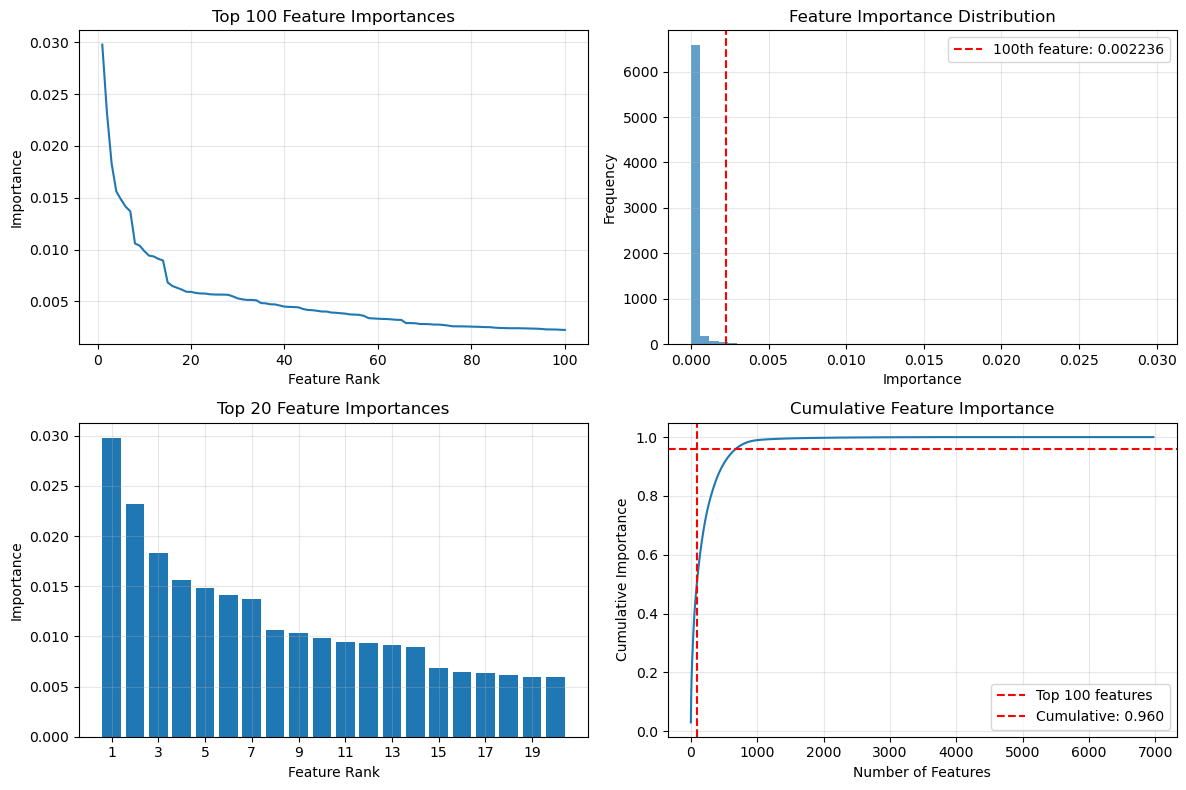

In [40]:
# Visualize feature importance distribution
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(range(1, 101), feature_importance_df.head(100)['importance'])
plt.title('Top 100 Feature Importances')
plt.xlabel('Feature Rank')
plt.ylabel('Importance')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.hist(feature_importance_df['importance'], bins=50, alpha=0.7)
plt.axvline(feature_importance_df.iloc[99]['importance'], color='red', linestyle='--', 
           label=f'100th feature: {feature_importance_df.iloc[99]["importance"]:.6f}')
plt.title('Feature Importance Distribution')
plt.xlabel('Importance')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.bar(range(1, 21), feature_importance_df.head(20)['importance'])
plt.title('Top 20 Feature Importances')
plt.xlabel('Feature Rank')
plt.ylabel('Importance')
plt.xticks(range(1, 21, 2))
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
cumulative_importance = np.cumsum(feature_importance_df['importance'])
plt.plot(range(1, len(cumulative_importance) + 1), cumulative_importance)
plt.axvline(100, color='red', linestyle='--', label='Top 100 features')
plt.axhline(cumulative_importance[99], color='red', linestyle='--', 
           label=f'Cumulative: {cumulative_importance[99]:.3f}')
plt.title('Cumulative Feature Importance')
plt.xlabel('Number of Features')
plt.ylabel('Cumulative Importance')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
df_training_important.head()

,41401,3314,430,99663,78039,431,V290,GENDER,V053,42731,...,42789,51882,5845,77081,4373,042,73300,V1011,0549,CLASSIFIER
0,0,0,0,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# 6. Test Dataset Construction

Extract positive samples and combine with negative samples to test model performance under balanced and imbalanced conditions. Search negatives where each has at least 2 similar features from top 100.

In [42]:
# Separate positive and negative samples
positive_samples = df_testing_7382[df_testing_7382['CLASSIFIER'] == 1]
negative_samples = df_testing_7382[df_testing_7382['CLASSIFIER'] == 0]

len(positive_samples)

34

In [43]:
# Extract samples from negative_samples that at least 2 of the top-100 most important features has a value of 1
def extract_negatives_with_topk_ones(negative_samples: pd.DataFrame,
                                     top_100_features,
                                     k: int = 2) -> pd.DataFrame:
    """
    Keep rows where at least k of the top-100 features == 1 (or True).
    - negative_samples: DataFrame with 0/1 (or bool) feature columns
    - top_100_features: iterable of feature names (list/Index)
    - k: threshold count (default 1)
    """
    cols = [c for c in top_100_features if c in negative_samples.columns]
    if not cols:
        return negative_samples.iloc[0:0].copy()

    sub = negative_samples[cols]
    # Count how many of the selected features are 1/True in each row
    hits = (sub.eq(1) | sub.eq(True)).sum(axis=1)
    return negative_samples.loc[hits >= k].copy()

# Example
selected_2plus = extract_negatives_with_topk_ones(negative_samples, top_100_features, k=2)
print(selected_2plus.shape)

(6776, 6970)


In [44]:
# Create multiple testing sets
df_testing_68 = pd.concat([positive_samples, negative_samples.sample(n=34, random_state=42)], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
df_testing_374 = pd.concat([positive_samples, negative_samples.sample(n=340, random_state=42)], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
df_testing_714 = pd.concat([positive_samples, negative_samples.sample(n=680, random_state=42)], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
df_testing_1054 = pd.concat([positive_samples, negative_samples.sample(n=1020, random_state=42)], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
df_testing_7382 = pd.concat([positive_samples, negative_samples.sample(n=7348, random_state=42)], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

# Simulation testing sets (no df_testing_7382 due to less similation sample size than original size)
df_testing_68_sim = pd.concat([positive_samples, selected_2plus.sample(n=34, random_state=42)], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
df_testing_374_sim = pd.concat([positive_samples, selected_2plus.sample(n=340, random_state=42)], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
df_testing_714_sim = pd.concat([positive_samples, selected_2plus.sample(n=680, random_state=42)], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
df_testing_1054_sim = pd.concat([positive_samples, selected_2plus.sample(n=1020, random_state=42)], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)


In [45]:
print(df_testing_374_sim.shape)
print(df_testing_714_sim.shape)
print(df_testing_1054_sim.shape)


print(df_testing_68.shape)
print(df_testing_374.shape)
print(df_testing_714.shape)
print(df_testing_1054.shape)
print(df_testing_7382.shape)


(374, 6970)
(714, 6970)
(1054, 6970)
(68, 6970)
(374, 6970)
(714, 6970)
(1054, 6970)
(7382, 6970)


In [46]:
# Check duplicate column names after concatenation
duplicate_columns_testing_68 = df_testing_68.columns[df_testing_68.columns.duplicated()].unique()

print(df_testing_68.shape)
duplicate_columns_testing_68_sim = df_testing_68_sim.columns[df_testing_68_sim.columns.duplicated()].unique()

print(f'Number of duplicate_columns_testing_68: {duplicate_columns_testing_68}')
print(f'Number of duplicate_columns_testing_68_sim: {duplicate_columns_testing_68_sim}')


(68, 6970)
Number of duplicate_columns_testing_68: Index([], dtype='object')
Number of duplicate_columns_testing_68_sim: Index([], dtype='object')


# 7. Model Training (RF, LightGBM, DNN)

1. Random Forest, LightGBM, and DNN are trained with cost-sensitive learning.
2. Out-of-fold predictions serve as meta-features for ensemble learning.

In [55]:
def train_RF(df, batch_size=64, n_splits=5, n_estimators=500):
    t_start = time.time()

    # Separate features and target variable
    X = df.drop('CLASSIFIER', axis=1).values
    y = df['CLASSIFIER'].values

    # Cross-validation setup
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    metrics = {'AUC': [], 'Sensitivity': [], 'Specificity': [], 'PPV': [], 'NPV': [], 'F1-score': [], 'MCC': [], 'PR-AUC': []}

    fold_number = 1
    fpr_list = []
    tpr_list = []

    # Placeholder for out-of-fold predictions
    oof_preds = np.zeros(X.shape[0])
    
    # Print the training dataset size
    print(f"Training Random Forest with {X.shape[0]} samples:")

    for train_index, test_index in skf.split(X, y):
        df_name = [name for name, val in globals().items() if val is df][0]

        # Split data
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # Convert data to numpy arrays
        X_train = X_train.astype(np.float32)
        X_test = X_test.astype(np.float32)

        n_neg = np.sum(y_train == 0)
        n_pos = np.sum(y_train == 1)
        # Standard balanced weight
        weight_ratio = n_neg / n_pos
        # More aggressive: multiply by 2-3x
        aggressive_weight_ratio = weight_ratio * 0.8
        class_weight_dict = {0: 1.0, 1: aggressive_weight_ratio}

        # Define and train Random Forest model
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            n_jobs=-1,
            random_state=42,
            class_weight=class_weight_dict  # Keep this
        )
        model.fit(X_train, y_train)

        # Predictions
        y_pred_probs = model.predict_proba(X_test)[:, 1]
        
        # OPTIMAL THRESHOLD SELECTION - Youden's J statistic
        fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
        youden_j = tpr - fpr
        optimal_idx = np.argmax(youden_j)
        optimal_threshold = thresholds[optimal_idx]
        
        # Alternative: F1-maximizing threshold
        # from sklearn.metrics import f1_score
        # thresholds_f1 = np.arange(0.1, 0.9, 0.01)
        # f1_scores = [f1_score(y_test, (y_pred_probs >= t).astype(int)) for t in thresholds_f1]
        # optimal_threshold = thresholds_f1[np.argmax(f1_scores)]
        
        # Use optimal threshold instead of 0.5
        y_pred = (y_pred_probs >= optimal_threshold).astype(int)
        
        # Print threshold info for debugging
        if fold_number == 1:
            print(f"  Optimal threshold (fold {fold_number}): {optimal_threshold:.4f}")
            print(f"  Probability range: [{y_pred_probs.min():.4f}, {y_pred_probs.max():.4f}]")
            print(f"  Positive predictions with optimal threshold: {y_pred.sum()} / {len(y_pred)}")

        # Save OOF predictions in the correct indices
        oof_preds[test_index] = y_pred_probs
        
        # Calculate metrics
        auc = roc_auc_score(y_test, y_pred_probs)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        sensitivity = tp / (tp + fn)
        specificity = tn / (tn + fp)
        ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan
        f1 = 2 * (ppv * sensitivity) / (ppv + sensitivity) if (ppv + sensitivity) > 0 else np.nan
        mcc = matthews_corrcoef(y_test, y_pred)
        pr_auc = average_precision_score(y_test, y_pred_probs)

        # Append metrics for the fold
        metrics['AUC'].append(auc)
        metrics['Sensitivity'].append(sensitivity)
        metrics['Specificity'].append(specificity)
        metrics['PPV'].append(ppv)
        metrics['NPV'].append(npv)
        metrics['F1-score'].append(f1)
        metrics['MCC'].append(mcc)
        metrics['PR-AUC'].append(pr_auc)

        # Collect data for plotting ROC curve
        fpr_list.append(fpr)
        tpr_list.append(tpr)

        fold_number += 1

    # Calculate mean and 95% CI for each metric
    def compute_mean_ci(values):
        mean = np.mean(values)
        lower = np.percentile(values, 2.5)
        upper = np.percentile(values, 97.5)
        return mean, (lower, upper)

    for metric, values in metrics.items():
        mean, ci = compute_mean_ci(values)
        print(f"{metric}: {mean:.4f} (95% CI: {ci[0]:.4f} - {ci[1]:.4f})")

    # Plot ROC curve for each fold
    plt.figure(figsize=(6, 6))
    for i in range(n_splits):
        plt.plot(fpr_list[i], tpr_list[i], label=f'Fold {i+1} (AUC = {metrics["AUC"][i]:.4f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f"ROC Curve of {df_name} using Random Forest")
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

    elapsed = time.time() - t_start
    print(f"Training time: {elapsed:.1f}s")
    timing_results[f'RF_{X.shape[0]}'] = elapsed
    return model, oof_preds

Training Random Forest with 360 samples:
  Optimal threshold (fold 1): 0.5060
  Probability range: [0.0080, 0.8040]
  Positive predictions with optimal threshold: 28 / 72
AUC: 0.8641 (95% CI: 0.7724 - 0.9183)
Sensitivity: 0.7889 (95% CI: 0.6417 - 0.9611)
Specificity: 0.8222 (95% CI: 0.7306 - 0.8861)
PPV: 0.8185 (95% CI: 0.7678 - 0.8567)
NPV: 0.8107 (95% CI: 0.6942 - 0.9524)
F1-score: 0.7978 (95% CI: 0.7023 - 0.8627)
MCC: 0.6200 (95% CI: 0.4627 - 0.7150)
PR-AUC: 0.8667 (95% CI: 0.7851 - 0.9223)


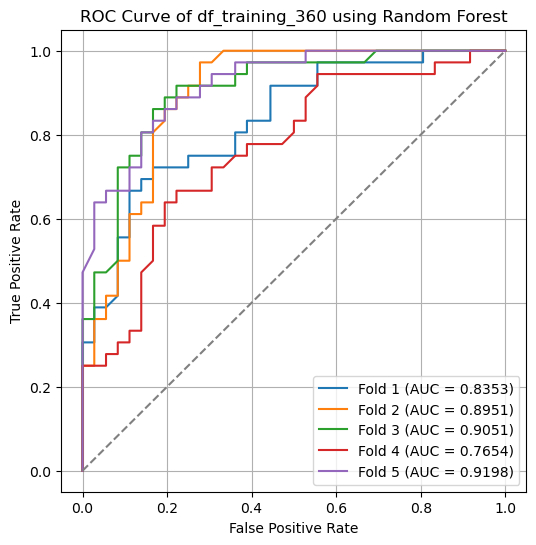

Training time: 3.6s


In [56]:
model_RF_360, oof_preds_RF_360 = train_RF(df_training_360)

Training Random Forest with 1980 samples:
  Optimal threshold (fold 1): 0.1460
  Probability range: [0.0000, 0.6720]
  Positive predictions with optimal threshold: 71 / 396
AUC: 0.9007 (95% CI: 0.8754 - 0.9304)
Sensitivity: 0.8056 (95% CI: 0.7250 - 0.9083)
Specificity: 0.8839 (95% CI: 0.8372 - 0.9228)
PPV: 0.4180 (95% CI: 0.3580 - 0.4851)
NPV: 0.9787 (95% CI: 0.9711 - 0.9892)
F1-score: 0.5460 (95% CI: 0.5127 - 0.5819)
MCC: 0.5216 (95% CI: 0.4984 - 0.5457)
PR-AUC: 0.5799 (95% CI: 0.5319 - 0.6414)


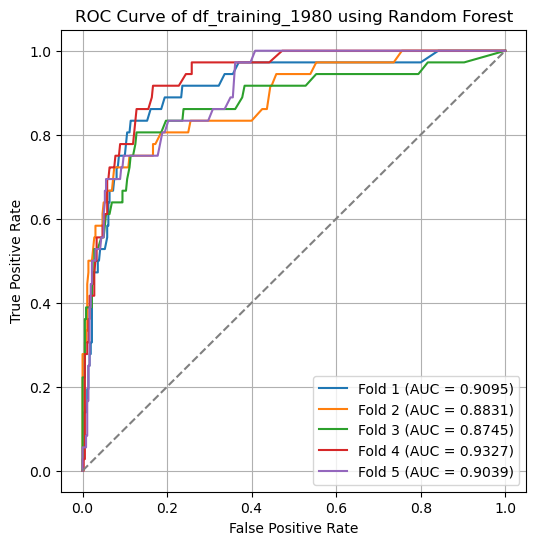

Training time: 6.7s


In [57]:
# Use 180 + 1800 samples (in df_training_198) as training set
model_RF_1980, oof_preds_RF_1980 = train_RF(df_training_1980)

Training Random Forest with 3780 samples:
  Optimal threshold (fold 1): 0.0680
  Probability range: [0.0000, 0.5200]
  Positive predictions with optimal threshold: 171 / 756
AUC: 0.8896 (95% CI: 0.8604 - 0.9246)
Sensitivity: 0.8000 (95% CI: 0.6972 - 0.8861)
Specificity: 0.8714 (95% CI: 0.8074 - 0.9211)
PPV: 0.2554 (95% CI: 0.1858 - 0.3181)
NPV: 0.9888 (95% CI: 0.9838 - 0.9930)
F1-score: 0.3807 (95% CI: 0.3058 - 0.4581)
MCC: 0.4019 (95% CI: 0.3460 - 0.4749)
PR-AUC: 0.4509 (95% CI: 0.4360 - 0.4828)


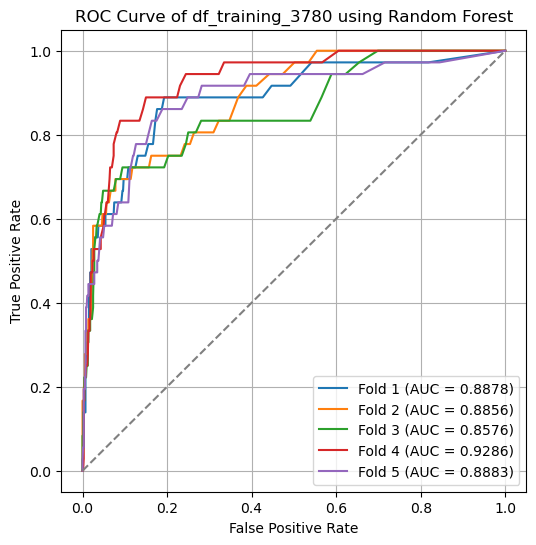

Training time: 24.9s


In [58]:
# Use 180 + 3600 samples (in df_training_3780) as training set
model_RF_3780, oof_preds_RF_3780 = train_RF(df_training_3780)

Training Random Forest with 5580 samples:
  Optimal threshold (fold 1): 0.0660
  Probability range: [0.0000, 0.3820]
  Positive predictions with optimal threshold: 151 / 1116
AUC: 0.8784 (95% CI: 0.8495 - 0.9057)
Sensitivity: 0.7778 (95% CI: 0.7222 - 0.8583)
Specificity: 0.8876 (95% CI: 0.8592 - 0.9221)
PPV: 0.1930 (95% CI: 0.1590 - 0.2392)
NPV: 0.9917 (95% CI: 0.9897 - 0.9946)
F1-score: 0.3074 (95% CI: 0.2626 - 0.3605)
MCC: 0.3494 (95% CI: 0.3036 - 0.4008)
PR-AUC: 0.3714 (95% CI: 0.2763 - 0.4145)


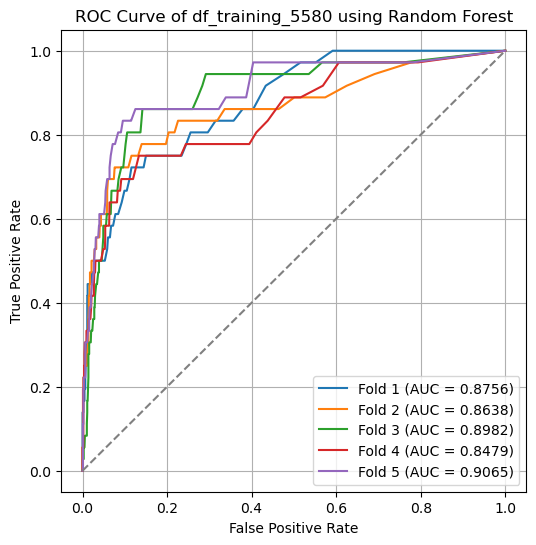

Training time: 51.2s


In [59]:
# Use 180 + 5400 samples (in df_training_5580) as training set
model_RF_5580, oof_preds_RF_5580 = train_RF(df_training_5580)

In [60]:
def train_LightGBM(df, batch_size=64, n_splits=5, n_estimators=100):
    t_start = time.time()
    # Separate features and target variable
    X = df.drop('CLASSIFIER', axis=1).values
    y = df['CLASSIFIER'].values

    # Cross-validation setup
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    metrics = {'AUC': [], 'Sensitivity': [], 'Specificity': [], 'PPV': [], 'NPV': [], 'F1-score': [], 'MCC': [], 'PR-AUC': []}

    fold_number = 1
    fpr_list = []
    tpr_list = []

    oof_preds = np.zeros(X.shape[0])

    print(f"Training LightGBM with {X.shape[0]} samples:")

    for train_index, test_index in skf.split(X, y):
        df_name = [name for name, val in globals().items() if val is df][0]

        # Split data
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # Convert data to numpy arrays
        X_train = X_train.astype(np.float32)
        X_test = X_test.astype(np.float32)

        # Calculate class weights - conservative approach for better PPV and Specificity
        n_neg = np.sum(y_train == 0)
        n_pos = np.sum(y_train == 1)
        
        if n_pos > 0:
            pos_weight = n_neg / n_pos
            # Further reduced multiplier to improve PPV and Specificity
            # Lower multiplier reduces false positives
            aggressive_pos_weight = pos_weight * 0.75  # Reduced from 0.9
        else:
            aggressive_pos_weight = 1.0

        # Enhanced LightGBM with hyperparameters optimized for PPV and Specificity
        model = lgb.LGBMClassifier(
            n_estimators=500,
            learning_rate=0.01,
            max_depth=8,  # Further reduced depth to reduce overfitting
            num_leaves=40,  # Further reduced leaves
            min_child_samples=60,  # Further increased to reduce false positives
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=aggressive_pos_weight,  # Cost-sensitive learning
            reg_alpha=0.3,  # Further increased regularization
            reg_lambda=0.3,
            random_state=42,
            verbose=-1,
            boost_from_average=False,
            objective='binary',
            metric='binary_logloss',
        )
        model.fit(X_train, y_train)

        # Predictions
        y_pred_probs = model.predict_proba(X_test)[:, 1]
        
        # OPTIMIZE THRESHOLD: Prioritize PPV and Specificity
        # Use precision-recall curve for better PPV optimization
        precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_probs)
        
        best_score = -1
        optimal_threshold = 0.5
        best_metrics = {}
        
        # Target: High PPV (>= 0.25) and High Specificity (>= 0.70) with reasonable sensitivity (>= 0.70)
        min_sensitivity = 0.70  # Minimum acceptable sensitivity
        min_ppv = 0.25  # Minimum PPV target
        min_specificity = 0.70  # Minimum Specificity target
        
        # Strategy 1: Find threshold that maximizes composite score of PPV and Specificity
        for i, threshold in enumerate(thresholds_pr):
            y_pred_temp = (y_pred_probs >= threshold).astype(int)
            
            if np.sum(y_pred_temp) > 0 and np.sum(y_test) > 0:
                tn, fp, fn, tp = confusion_matrix(y_test, y_pred_temp).ravel()
                sensitivity_temp = tp / (tp + fn) if (tp + fn) > 0 else 0
                ppv_temp = precision[i]  # Use precision from PR curve
                specificity_temp = tn / (tn + fp) if (tn + fp) > 0 else 0
                
                # Check if minimum sensitivity is met
                if sensitivity_temp >= min_sensitivity:
                    # Composite score: balance PPV and Specificity (both reduce false positives)
                    # Equal weight on PPV and Specificity, with some weight on sensitivity
                    composite_score = 0.5 * ppv_temp + 0.4 * specificity_temp + 0.1 * sensitivity_temp
                    
                    if composite_score > best_score:
                        best_score = composite_score
                        optimal_threshold = threshold
                        best_metrics = {
                            'sensitivity': sensitivity_temp,
                            'ppv': ppv_temp,
                            'specificity': specificity_temp,
                            'composite': composite_score,
                            'f1': 2 * (ppv_temp * sensitivity_temp) / (ppv_temp + sensitivity_temp + 1e-10)
                        }
        
        # Strategy 2: If no threshold meets all requirements, relax constraints
        if best_score == -1:
            print(f"  Warning: No threshold meets all constraints. Relaxing...")
            
            # Try with relaxed PPV and Specificity
            min_ppv_relaxed = 0.20
            min_specificity_relaxed = 0.65
            
            for i, threshold in enumerate(thresholds_pr):
                y_pred_temp = (y_pred_probs >= threshold).astype(int)
                
                if np.sum(y_pred_temp) > 0 and np.sum(y_test) > 0:
                    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_temp).ravel()
                    sensitivity_temp = tp / (tp + fn) if (tp + fn) > 0 else 0
                    ppv_temp = precision[i]
                    specificity_temp = tn / (tn + fp) if (tn + fp) > 0 else 0
                    
                    if (sensitivity_temp >= min_sensitivity and 
                        ppv_temp >= min_ppv_relaxed and 
                        specificity_temp >= min_specificity_relaxed):
                        composite_score = 0.5 * ppv_temp + 0.4 * specificity_temp + 0.1 * sensitivity_temp
                        if composite_score > best_score:
                            best_score = composite_score
                            optimal_threshold = threshold
                            best_metrics = {
                                'sensitivity': sensitivity_temp,
                                'ppv': ppv_temp,
                                'specificity': specificity_temp,
                                'composite': composite_score,
                                'f1': 2 * (ppv_temp * sensitivity_temp) / (ppv_temp + sensitivity_temp + 1e-10)
                            }
        
        # Strategy 3: If still no threshold, use grid search with PPV+Specificity optimization
        if best_score == -1:
            thresholds_grid = np.arange(0.3, 0.95, 0.01)
            
            for threshold in thresholds_grid:
                y_pred_temp = (y_pred_probs >= threshold).astype(int)
                if np.sum(y_pred_temp) > 0:
                    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_temp).ravel()
                    sensitivity_temp = tp / (tp + fn) if (tp + fn) > 0 else 0
                    ppv_temp = tp / (tp + fp) if (tp + fp) > 0 else 0
                    specificity_temp = tn / (tn + fp) if (tn + fp) > 0 else 0
                    
                    if sensitivity_temp >= 0.65:  # Minimum sensitivity
                        # Optimize for PPV and Specificity
                        composite_score = 0.5 * ppv_temp + 0.4 * specificity_temp + 0.1 * sensitivity_temp
                        if composite_score > best_score:
                            best_score = composite_score
                            optimal_threshold = threshold
                            best_metrics = {
                                'sensitivity': sensitivity_temp,
                                'ppv': ppv_temp,
                                'specificity': specificity_temp,
                                'composite': composite_score,
                                'f1': 2 * (ppv_temp * sensitivity_temp) / (ppv_temp + sensitivity_temp + 1e-10)
                            }
        
        # Use optimal threshold
        y_pred = (y_pred_probs >= optimal_threshold).astype(int)
        
        # Debug info for first fold
        if fold_number == 1:
            print(f"  Optimal threshold (fold {fold_number}): {optimal_threshold:.4f}")
            print(f"  Best composite score: {best_metrics.get('composite', 0):.4f}")
            print(f"  Sensitivity: {best_metrics.get('sensitivity', 0):.4f}, PPV: {best_metrics.get('ppv', 0):.4f}")
            print(f"  Specificity: {best_metrics.get('specificity', 0):.4f}, F1: {best_metrics.get('f1', 0):.4f}")
            print(f"  Scale pos weight: {aggressive_pos_weight:.2f}")

        oof_preds[test_index] = y_pred_probs

        # Calculate metrics
        auc = roc_auc_score(y_test, y_pred_probs)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan

        # Calculate F1-score
        f1 = 2 * (ppv * sensitivity) / (ppv + sensitivity) if (ppv + sensitivity) > 0 else np.nan
        mcc = matthews_corrcoef(y_test, y_pred)
        pr_auc = average_precision_score(y_test, y_pred_probs)

        # Append metrics for the fold
        metrics['AUC'].append(auc)
        metrics['Sensitivity'].append(sensitivity)
        metrics['Specificity'].append(specificity)
        metrics['PPV'].append(ppv)
        metrics['NPV'].append(npv)
        metrics['F1-score'].append(f1)
        metrics['MCC'].append(mcc)
        metrics['PR-AUC'].append(pr_auc)

        # Collect data for plotting ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
        fpr_list.append(fpr)
        tpr_list.append(tpr)

        fold_number += 1

    # Calculate mean and 95% CI for each metric
    def compute_mean_ci(values):
        mean = np.mean(values)
        lower = np.percentile(values, 2.5)
        upper = np.percentile(values, 97.5)
        return mean, (lower, upper)

    for metric, values in metrics.items():
        mean, ci = compute_mean_ci(values)
        print(f"{metric}: {mean:.4f} (95% CI: {ci[0]:.4f} - {ci[1]:.4f})")

    # Calculate and display average F1-score
    avg_f1 = np.mean(metrics['F1-score'])
    print(f"F1-Score Across Folds: {avg_f1:.4f}")

    # Plot ROC curve for each fold
    plt.figure(figsize=(6, 6))
    for i in range(n_splits):
        plt.plot(fpr_list[i], tpr_list[i], label=f'Fold {i+1} (AUC = {metrics["AUC"][i]:.4f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f"ROC Curve of {df_name} using LightGBM")
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

    elapsed = time.time() - t_start
    print(f"Training time: {elapsed:.1f}s")
    timing_results[f'LGBM_{X.shape[0]}'] = elapsed
    return model, oof_preds

Training LightGBM with 360 samples:
  Optimal threshold (fold 1): 0.3768
  Best composite score: 0.3930
  Sensitivity: 0.8056, PPV: 0.4915
  Specificity: 0.1667, F1: 0.6105
  Scale pos weight: 0.75
AUC: 0.5383 (95% CI: 0.4337 - 0.6430)
Sensitivity: 0.9056 (95% CI: 0.7306 - 1.0000)
Specificity: 0.1500 (95% CI: 0.0000 - 0.5417)
PPV: 0.5251 (95% CI: 0.4924 - 0.6207)
NPV: nan (95% CI: nan - nan)
F1-score: 0.6572 (95% CI: 0.6161 - 0.6745)
MCC: 0.0545 (95% CI: -0.0325 - 0.2777)
PR-AUC: 0.5249 (95% CI: 0.4677 - 0.5901)
F1-Score Across Folds: 0.6572


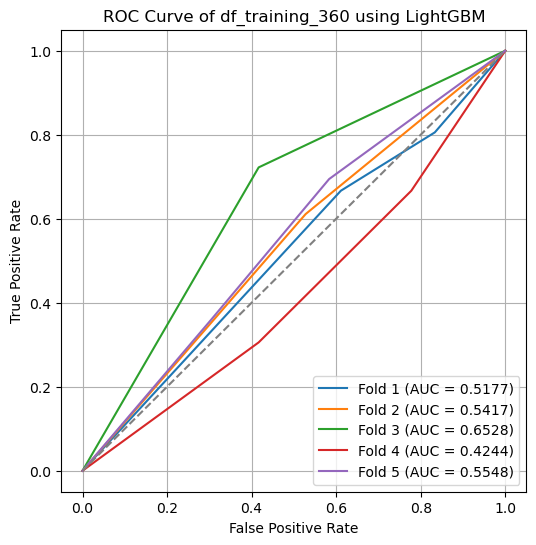

Training time: 1.9s


In [61]:
model_LGBM_360, oof_preds_LGBM_360 = train_LightGBM(df_training_360)

Training LightGBM with 1980 samples:
  Optimal threshold (fold 1): 0.4133
  Best composite score: 0.4864
  Sensitivity: 0.7222, PPV: 0.2261
  Specificity: 0.7528, F1: 0.3444
  Scale pos weight: 7.50
AUC: 0.7929 (95% CI: 0.7653 - 0.8135)
Sensitivity: 0.7222 (95% CI: 0.7222 - 0.7222)
Specificity: 0.7272 (95% CI: 0.6853 - 0.7519)
PPV: 0.2104 (95% CI: 0.1869 - 0.2255)
NPV: 0.9632 (95% CI: 0.9610 - 0.9644)
F1-score: 0.3256 (95% CI: 0.2969 - 0.3437)
MCC: 0.2792 (95% CI: 0.2455 - 0.3001)
PR-AUC: 0.2907 (95% CI: 0.2392 - 0.3463)
F1-Score Across Folds: 0.3256


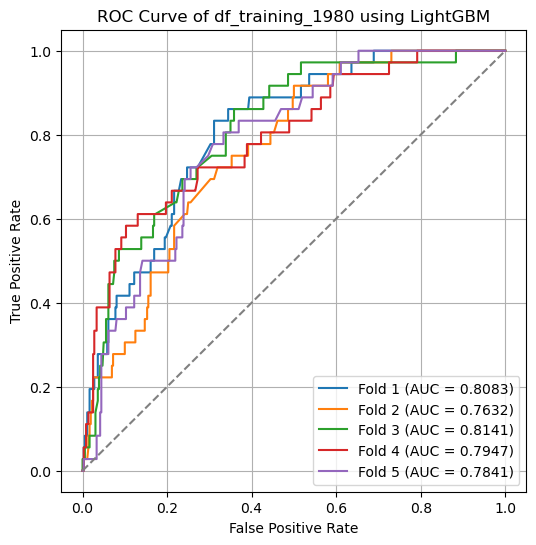

Training time: 5.9s


In [62]:
# Use 180 + 1800 samples (in df_training_1980) as training set
model_LGBM_1980, oof_preds_LGBM_1980 = train_LightGBM(df_training_1980)

Training LightGBM with 3780 samples:
  Optimal threshold (fold 1): 0.4155
  Best composite score: 0.4667
  Sensitivity: 0.7222, PPV: 0.1512
  Specificity: 0.7972, F1: 0.2500
  Scale pos weight: 15.00
AUC: 0.8256 (95% CI: 0.7949 - 0.8842)
Sensitivity: 0.7278 (95% CI: 0.7222 - 0.7472)
Specificity: 0.7508 (95% CI: 0.6499 - 0.8672)
PPV: 0.1399 (95% CI: 0.0938 - 0.2168)
NPV: 0.9820 (95% CI: 0.9791 - 0.9842)
F1-score: 0.2312 (95% CI: 0.1660 - 0.3329)
MCC: 0.2400 (95% CI: 0.1646 - 0.3440)
PR-AUC: 0.2697 (95% CI: 0.1955 - 0.3514)
F1-Score Across Folds: 0.2312


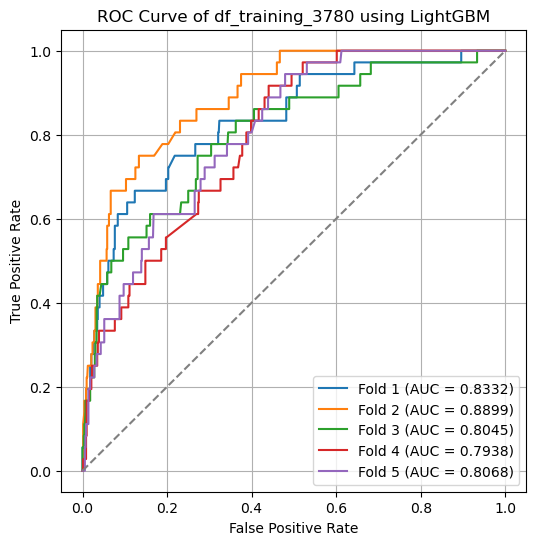

Training time: 5.9s


In [63]:
# Use 180 + 3600 samples (in df_training_3780) as training set
model_LGBM_3780, oof_preds_LGBM_3780 = train_LightGBM(df_training_3780)

Training LightGBM with 5580 samples:
  Optimal threshold (fold 1): 0.3936
  Best composite score: 0.4378
  Sensitivity: 0.7500, PPV: 0.1019
  Specificity: 0.7796, F1: 0.1794
  Scale pos weight: 22.50
AUC: 0.8228 (95% CI: 0.7687 - 0.8617)
Sensitivity: 0.7333 (95% CI: 0.7222 - 0.7500)
Specificity: 0.7574 (95% CI: 0.6657 - 0.8313)
PPV: 0.0960 (95% CI: 0.0676 - 0.1260)
NPV: 0.9883 (95% CI: 0.9863 - 0.9894)
F1-score: 0.1690 (95% CI: 0.1235 - 0.2146)
MCC: 0.2029 (95% CI: 0.1445 - 0.2530)
PR-AUC: 0.2579 (95% CI: 0.0984 - 0.3852)
F1-Score Across Folds: 0.1690


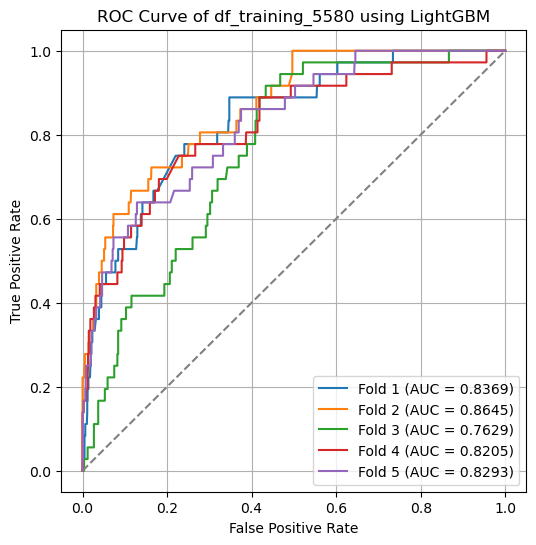

Training time: 6.9s


In [64]:
# Use 180 + 5400 samples (in df_training_5580) as training set
model_LGBM_5580, oof_preds_LGBM_5580 = train_LightGBM(df_training_5580)

In [65]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpu_count = torch.cuda.device_count()
print(f"Number of GPUs available: {gpu_count}")

Number of GPUs available: 1


In [66]:
# --- 1. Weighted Focal Loss Class ---
class WeightedFocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2.0, weight=None):
        super(WeightedFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.weight = weight 

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.weight)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * ce_loss
        return focal_loss.mean()

# --- 2. Main Training Function ---
def train_dnn(df, epochs=250, batch_size=128, n_splits=5, learning_rate=0.003):
    t_start = time.time()
    # Separate features and target variable
    X = df.drop('CLASSIFIER', axis=1).values
    y = df['CLASSIFIER'].values

    # Cross-validation setup
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    metrics = {'AUC': [], 'Sensitivity': [], 'Specificity': [], 'PPV': [], 'NPV': [], 'F1-score': [], 'MCC': [], 'PR-AUC': []}

    fold_number = 1
    fpr_list = []
    tpr_list = []
    oof_preds = np.zeros(X.shape[0])
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    gpu_count = torch.cuda.device_count()
    print(f"Training DNN with {X.shape[0]} samples on {gpu_count} GPU(s):")

    for train_index, test_index in skf.split(X, y):
        # Extract df's variable name for plot title
        df_name = [name for name, val in globals().items() if val is df][0]

        # Split data
        X_train_fold, X_test_fold = X[train_index], X[test_index]
        y_train_fold, y_test_fold = y[train_index], y[test_index]

        # Convert data to PyTorch tensors
        X_train = torch.tensor(X_train_fold, dtype=torch.float32).to(device)
        y_train = torch.tensor(y_train_fold, dtype=torch.long).to(device)
        X_test = torch.tensor(X_test_fold, dtype=torch.float32).to(device)
        y_test = torch.tensor(y_test_fold, dtype=torch.long).to(device)

        # Create DataLoaders (Fixed NameError)
        train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

        # Define the DNN model
        input_size = X_train.shape[1]
        model = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        ).to(device)

        # Wrap for Multi-GPU
        if gpu_count > 1:
            model = nn.DataParallel(model)

        # Cost-Sensitive Weights
        class_counts = np.bincount(y_train_fold)
        cw = torch.tensor([1.0, class_counts[0] / class_counts[1]], dtype=torch.float32).to(device)

        criterion = WeightedFocalLoss(alpha=1, gamma=2.0, weight=cw)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=5e-5)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.8)

        # Training loop
        for epoch in range(epochs):
            model.train()
            for inputs, labels in train_loader:
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
            scheduler.step()

        # Evaluation for the fold
        model.eval()
        y_true = []
        y_pred_probs = []
        with torch.no_grad():
            for inputs, labels in test_loader:
                outputs = model(inputs)
                probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
                y_pred_probs.extend(probs)
                y_true.extend(labels.cpu().numpy())

        # Dynamic Thresholding for Sensitivity Fix
        fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
        optimal_idx = np.argmax(tpr - fpr)
        best_threshold = thresholds[optimal_idx]
        
        y_pred = (np.array(y_pred_probs) >= best_threshold).astype(int)
        oof_preds[test_index] = y_pred_probs

        # Calculate metrics
        auc = roc_auc_score(y_true, y_pred_probs)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        sensitivity = tp / (tp + fn)
        specificity = tn / (tn + fp)
        ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan
        f1 = 2 * (ppv * sensitivity) / (ppv + sensitivity) if (ppv + sensitivity) > 0 else np.nan
        mcc = matthews_corrcoef(y_true, y_pred)
        pr_auc = average_precision_score(y_true, y_pred_probs)

        metrics['AUC'].append(auc)
        metrics['Sensitivity'].append(sensitivity)
        metrics['Specificity'].append(specificity)
        metrics['PPV'].append(ppv)
        metrics['NPV'].append(npv)
        metrics['F1-score'].append(f1)
        metrics['MCC'].append(mcc)
        metrics['PR-AUC'].append(pr_auc)

        fpr_list.append(fpr)
        tpr_list.append(tpr)
        fold_number += 1

    # Calculate mean and 95% CI
    def compute_mean_ci(values):
        mean = np.mean(values)
        lower = np.percentile(values, 2.5)
        upper = np.percentile(values, 97.5)
        return mean, (lower, upper)

    for metric, values in metrics.items():
        mean, ci = compute_mean_ci(values)
        print(f"{metric}: {mean:.4f} (95% CI: {ci[0]:.4f} - {ci[1]:.4f})")

    # Plot ROC curve (Original format)
    plt.figure(figsize=(6, 6))
    for i in range(n_splits):
        plt.plot(fpr_list[i], tpr_list[i], label=f'Fold {i+1} (AUC = {metrics["AUC"][i]:.4f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f"ROC Curve of {df_name} using DNN")
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

    elapsed = time.time() - t_start
    print(f"Training time: {elapsed:.1f}s")
    timing_results[f'DNN_{X.shape[0]}'] = elapsed
    return model, oof_preds

Training DNN with 360 samples on 1 GPU(s):
AUC: 0.8412 (95% CI: 0.7959 - 0.8874)
Sensitivity: 0.8389 (95% CI: 0.8056 - 0.8611)
Specificity: 0.7667 (95% CI: 0.6972 - 0.8556)
PPV: 0.7843 (95% CI: 0.7386 - 0.8566)
NPV: 0.8259 (95% CI: 0.7885 - 0.8603)
F1-score: 0.8102 (95% CI: 0.7744 - 0.8588)
MCC: 0.6079 (95% CI: 0.5323 - 0.7168)
PR-AUC: 0.8246 (95% CI: 0.7899 - 0.8677)


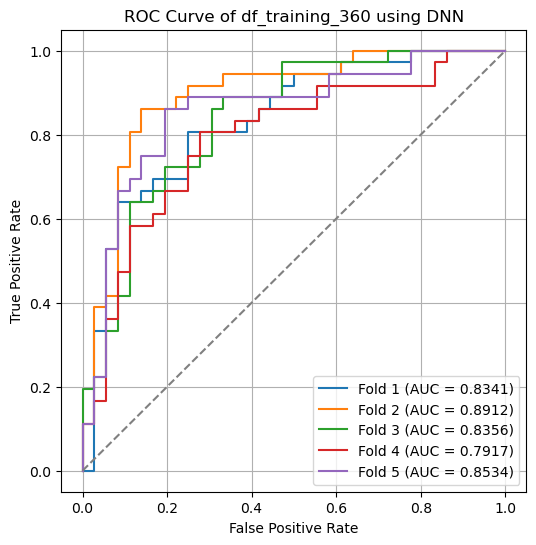

Training time: 19.1s


In [67]:
model_DNN_360, oof_preds_DNN_360 = train_dnn(df_training_360)

Training DNN with 1980 samples on 1 GPU(s):
AUC: 0.8113 (95% CI: 0.7818 - 0.8306)
Sensitivity: 0.6778 (95% CI: 0.5639 - 0.7750)
Specificity: 0.8617 (95% CI: 0.7931 - 0.9367)
PPV: 0.3501 (95% CI: 0.2730 - 0.4761)
NPV: 0.9644 (95% CI: 0.9555 - 0.9724)
F1-score: 0.4506 (95% CI: 0.4029 - 0.5145)
MCC: 0.4084 (95% CI: 0.3713 - 0.4642)
PR-AUC: 0.4457 (95% CI: 0.4039 - 0.5028)


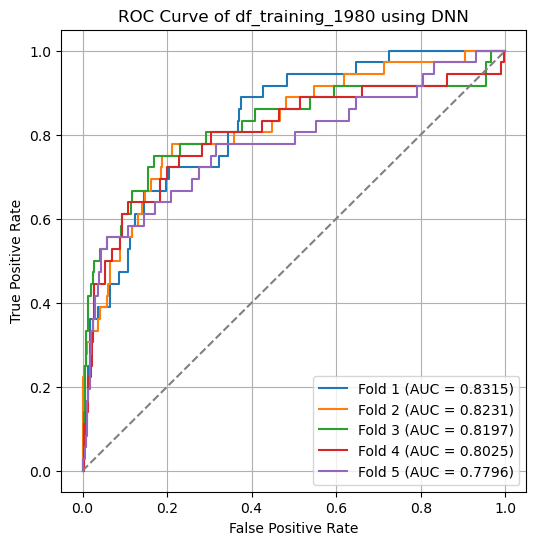

Training time: 37.8s


In [68]:
# Use 180 + 1800 samples (in df_training_1980) as training set
model_DNN_1980, oof_preds_DNN_1980 = train_dnn(df_training_1980)

Training DNN with 3780 samples on 1 GPU(s):
AUC: 0.7947 (95% CI: 0.7599 - 0.8474)
Sensitivity: 0.6889 (95% CI: 0.5917 - 0.7944)
Specificity: 0.8133 (95% CI: 0.6533 - 0.8862)
PPV: 0.1738 (95% CI: 0.1050 - 0.2256)
NPV: 0.9814 (95% CI: 0.9772 - 0.9847)
F1-score: 0.2727 (95% CI: 0.1848 - 0.3372)
MCC: 0.2775 (95% CI: 0.2000 - 0.3388)
PR-AUC: 0.3092 (95% CI: 0.2467 - 0.4128)


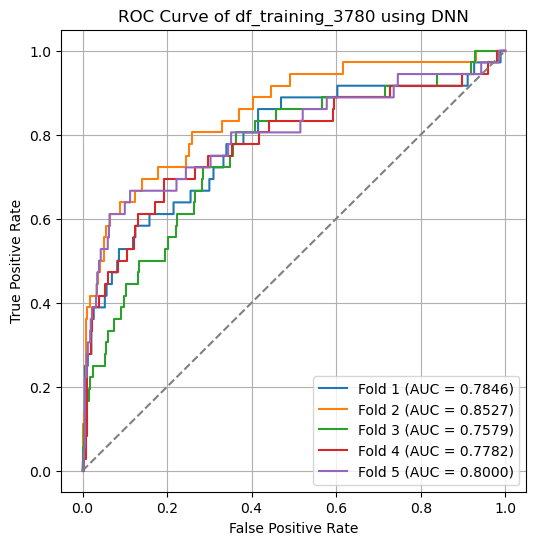

Training time: 73.9s


In [69]:
# Use 180 + 3600 samples (in df_training_3780) as training set
model_DNN_3780, oof_preds_DNN_3780 = train_dnn(df_training_3780)

Training DNN with 5580 samples on 1 GPU(s):
AUC: 0.8149 (95% CI: 0.7744 - 0.8612)
Sensitivity: 0.6944 (95% CI: 0.5861 - 0.8528)
Specificity: 0.8326 (95% CI: 0.7348 - 0.9365)
PPV: 0.1448 (95% CI: 0.0900 - 0.2390)
NPV: 0.9882 (95% CI: 0.9855 - 0.9935)
F1-score: 0.2304 (95% CI: 0.1615 - 0.3386)
MCC: 0.2590 (95% CI: 0.2029 - 0.3420)
PR-AUC: 0.3085 (95% CI: 0.2432 - 0.4462)


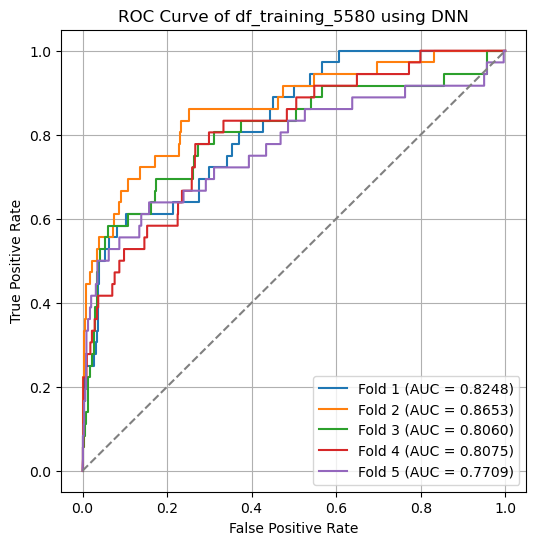

Training time: 98.8s


In [70]:
# Use 180 + 5400 samples (in df_training_5580) as training set
model_DNN_5580, oof_preds_DNN_5580 = train_dnn(df_training_5580)

# 8. Meta-Model (Ensemble) Training

Logistic regression meta-learner trained on out-of-fold predictions from RF, LightGBM, and DNN base models.

In [71]:
# X = meta-feature matrix (3 columns: RF, LGBM, DNN predictions)
oof_preds_X_360 = np.column_stack([oof_preds_RF_360, oof_preds_LGBM_360, oof_preds_DNN_360])
oof_preds_X_1980 = np.column_stack([oof_preds_RF_1980, oof_preds_LGBM_1980, oof_preds_DNN_1980])
oof_preds_X_3780 = np.column_stack([oof_preds_RF_3780, oof_preds_LGBM_3780, oof_preds_DNN_3780])
oof_preds_X_5580 = np.column_stack([oof_preds_RF_5580, oof_preds_LGBM_5580, oof_preds_DNN_5580])


# y = true labels for training data
y_meta_360 = df_training_360['CLASSIFIER'].values
y_meta_1980 = df_training_1980['CLASSIFIER'].values
y_meta_3780 = df_training_3780['CLASSIFIER'].values
y_meta_5580 = df_training_5580['CLASSIFIER'].values

In [72]:
# Train the LR meta-learner
meta_model_LR_360 = LogisticRegression(class_weight='balanced', penalty='l2', solver='lbfgs', max_iter=1000)
meta_model_LR_1980 = LogisticRegression(class_weight='balanced', penalty='l2', solver='lbfgs', max_iter=1000)
meta_model_LR_3780 = LogisticRegression(class_weight='balanced', penalty='l2', solver='lbfgs', max_iter=1000)
meta_model_LR_5580 = LogisticRegression(class_weight='balanced', penalty='l2', solver='lbfgs', max_iter=1000)
meta_model_LR = LogisticRegression(class_weight="balanced", penalty="l2", solver="lbfgs", max_iter=1000)

meta_model_LR_360.fit(oof_preds_X_360, y_meta_360)
meta_model_LR_1980.fit(oof_preds_X_1980, y_meta_1980)
meta_model_LR_3780.fit(oof_preds_X_3780, y_meta_3780)
meta_model_LR_5580.fit(oof_preds_X_5580, y_meta_5580)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [73]:
##############################################################################
# LR Meta-Model Coefficient Interpretation with Bootstrap 95% CIs
##############################################################################

def lr_coef_bootstrap_ci(oof_X, y_meta, n_bootstrap=200, seed=42):
    """Bootstrap CIs for LR meta-model coefficients."""
    np.random.seed(seed)
    n = len(y_meta)
    coefs, intercepts = [], []
    for _ in range(n_bootstrap):
        idx = np.random.choice(n, n, replace=True)
        lr = LogisticRegression(class_weight='balanced', penalty='l2', solver='lbfgs', max_iter=1000)
        try:
            lr.fit(oof_X[idx], y_meta[idx])
            coefs.append(lr.coef_[0])
            intercepts.append(lr.intercept_[0])
        except:
            continue
    coefs = np.array(coefs)
    intercepts = np.array(intercepts)
    return coefs, intercepts

base_model_names = ['RF', 'LightGBM', 'DNN']
meta_configs = [
    ('360',  meta_model_LR_360,  oof_preds_X_360,  y_meta_360),
    ('1980', meta_model_LR_1980, oof_preds_X_1980, y_meta_1980),
    ('3780', meta_model_LR_3780, oof_preds_X_3780, y_meta_3780),
    ('5580', meta_model_LR_5580, oof_preds_X_5580, y_meta_5580),
]

print("=" * 90)
print("LOGISTIC REGRESSION META-MODEL COEFFICIENTS (with bootstrap 95% CIs)")
print("=" * 90)
print(f"{'Train Size':<12} {'Intercept':<28} {'RF coef':<28} {'LGBM coef':<28} {'DNN coef':<28}")
print("-" * 90)

for size, model, oof_X, y_m in meta_configs:
    coefs_bs, ints_bs = lr_coef_bootstrap_ci(oof_X, y_m)
    int_val = model.intercept_[0]
    int_lo, int_hi = np.percentile(ints_bs, 2.5), np.percentile(ints_bs, 97.5)
    row = f"{size:<12} {int_val:+.3f} ({int_lo:+.3f}, {int_hi:+.3f})   "
    for j, name in enumerate(base_model_names):
        c = model.coef_[0][j]
        c_lo, c_hi = np.percentile(coefs_bs[:, j], 2.5), np.percentile(coefs_bs[:, j], 97.5)
        row += f"{c:+.3f} ({c_lo:+.3f}, {c_hi:+.3f})   "
    print(row)

LOGISTIC REGRESSION META-MODEL COEFFICIENTS (with bootstrap 95% CIs)
Train Size   Intercept                    RF coef                      LGBM coef                    DNN coef                    
------------------------------------------------------------------------------------------
360          -2.398 (-2.848, -2.016)   +3.316 (+2.369, +4.197)   +0.134 (-0.377, +0.742)   +1.766 (+1.106, +2.498)   
1980         -2.386 (-2.757, -2.008)   +8.957 (+7.418, +10.390)   +2.330 (+1.602, +3.053)   +0.935 (+0.461, +1.440)   
3780         -2.271 (-2.677, -1.974)   +10.589 (+8.690, +12.319)   +3.171 (+2.483, +3.945)   +1.195 (+0.610, +1.748)   
5580         -2.068 (-2.395, -1.761)   +12.576 (+10.363, +14.899)   +3.144 (+2.393, +3.758)   +1.559 (+0.901, +2.454)   


In [74]:
##############################################################################
# Training Time Summary
##############################################################################
print("=" * 65)
print("TRAINING TIME SUMMARY")
print("=" * 65)
print(f"{'Model':<20} {'Samples':<12} {'Time (s)':<12}")
print("-" * 65)
total = 0.0
for key in sorted(timing_results.keys()):
    model_name, n_samples = key.rsplit('_', 1)
    t = timing_results[key]
    total += t
    print(f"{model_name:<20} {n_samples:<12} {t:<12.1f}")
print("-" * 65)
print(f"{'TOTAL':<32} {total:<12.1f}")
print("=" * 65)

TRAINING TIME SUMMARY
Model                Samples      Time (s)    
-----------------------------------------------------------------
DNN                  1980         37.8        
DNN                  360          19.1        
DNN                  3780         73.9        
DNN                  5580         98.8        
LGBM                 1980         5.9         
LGBM                 360          1.9         
LGBM                 3780         5.9         
LGBM                 5580         6.9         
RF                   1980         6.7         
RF                   360          3.6         
RF                   3780         24.9        
RF                   5580         51.2        
-----------------------------------------------------------------
TOTAL                            336.6       


In [75]:
# Prepare test features and labels for 68, 374, 714, 1054, 7382 testing sets 
X_test_68 = df_testing_68.drop('CLASSIFIER', axis=1).values
X_test_374 = df_testing_374.drop('CLASSIFIER', axis=1).values
X_test_714 = df_testing_714.drop('CLASSIFIER', axis=1).values
X_test_1054 = df_testing_1054.drop('CLASSIFIER', axis=1).values
X_test_7382 = df_testing_7382.drop('CLASSIFIER', axis=1).values

# Prepare test features and labels for 68, 374, 714, 1054, 7382 testing sets of simulations
X_test_68_sim = df_testing_68_sim.drop('CLASSIFIER', axis=1).values
X_test_374_sim = df_testing_374_sim.drop('CLASSIFIER', axis=1).values
X_test_714_sim = df_testing_714_sim.drop('CLASSIFIER', axis=1).values
X_test_1054_sim = df_testing_1054_sim.drop('CLASSIFIER', axis=1).values


In [76]:
# Prepare test features and labels for classifiers

# Regular
y_test_68 = df_testing_68['CLASSIFIER'].values
y_test_374 = df_testing_374['CLASSIFIER'].values
y_test_714 = df_testing_714['CLASSIFIER'].values
y_test_1054 = df_testing_1054['CLASSIFIER'].values
y_test_7382 = df_testing_7382['CLASSIFIER'].values

# Simulation
y_test_68_sim = df_testing_68_sim['CLASSIFIER'].values
y_test_374_sim = df_testing_374_sim['CLASSIFIER'].values
y_test_714_sim = df_testing_714_sim['CLASSIFIER'].values
y_test_1054_sim = df_testing_1054_sim['CLASSIFIER'].values


In [77]:
# Predict probabilities for ramdon forest
# X_test structure: 34 +34, 34 + 340, 34 + 680, 34 + 1020, 34 + 1364, 34 + 7348  
# Regular 
test_preds_RF_360_68 = model_RF_360.predict_proba(X_test_68)[:, 1]
test_preds_RF_1980_68 = model_RF_1980.predict_proba(X_test_68)[:, 1]
test_preds_RF_3780_68 = model_RF_3780.predict_proba(X_test_68)[:, 1]
test_preds_RF_5580_68 = model_RF_5580.predict_proba(X_test_68)[:, 1]

test_preds_RF_360_374 = model_RF_360.predict_proba(X_test_374)[:, 1]
test_preds_RF_1980_374 = model_RF_1980.predict_proba(X_test_374)[:, 1]
test_preds_RF_3780_374 = model_RF_3780.predict_proba(X_test_374)[:, 1]
test_preds_RF_5580_374 = model_RF_5580.predict_proba(X_test_374)[:, 1]

test_preds_RF_360_714 = model_RF_360.predict_proba(X_test_714)[:, 1]
test_preds_RF_1980_714 = model_RF_1980.predict_proba(X_test_714)[:, 1]
test_preds_RF_3780_714 = model_RF_3780.predict_proba(X_test_714)[:, 1]
test_preds_RF_5580_714 = model_RF_5580.predict_proba(X_test_714)[:, 1]

test_preds_RF_360_1054 = model_RF_360.predict_proba(X_test_1054)[:, 1]
test_preds_RF_1980_1054 = model_RF_1980.predict_proba(X_test_1054)[:, 1]
test_preds_RF_3780_1054 = model_RF_3780.predict_proba(X_test_1054)[:, 1]
test_preds_RF_5580_1054 = model_RF_5580.predict_proba(X_test_1054)[:, 1]

test_preds_RF_360_7382 = model_RF_360.predict_proba(X_test_7382)[:, 1]
test_preds_RF_1980_7382 = model_RF_1980.predict_proba(X_test_7382)[:, 1]
test_preds_RF_3780_7382 = model_RF_3780.predict_proba(X_test_7382)[:, 1]
test_preds_RF_5580_7382 = model_RF_5580.predict_proba(X_test_7382)[:, 1]

# Simulation
test_preds_RF_360_68_sim = model_RF_360.predict_proba(X_test_68_sim)[:, 1]
test_preds_RF_1980_68_sim = model_RF_1980.predict_proba(X_test_68_sim)[:, 1]
test_preds_RF_3780_68_sim = model_RF_3780.predict_proba(X_test_68_sim)[:, 1]
test_preds_RF_5580_68_sim = model_RF_5580.predict_proba(X_test_68_sim)[:, 1]

test_preds_RF_360_374_sim = model_RF_360.predict_proba(X_test_374_sim)[:, 1]
test_preds_RF_1980_374_sim = model_RF_1980.predict_proba(X_test_374_sim)[:, 1]
test_preds_RF_3780_374_sim = model_RF_3780.predict_proba(X_test_374_sim)[:, 1]
test_preds_RF_5580_374_sim = model_RF_5580.predict_proba(X_test_374_sim)[:, 1]

test_preds_RF_360_714_sim = model_RF_360.predict_proba(X_test_714_sim)[:, 1]
test_preds_RF_1980_714_sim = model_RF_1980.predict_proba(X_test_714_sim)[:, 1]
test_preds_RF_3780_714_sim = model_RF_3780.predict_proba(X_test_714_sim)[:, 1]
test_preds_RF_5580_714_sim = model_RF_5580.predict_proba(X_test_714_sim)[:, 1]

test_preds_RF_360_1054_sim = model_RF_360.predict_proba(X_test_1054_sim)[:, 1]
test_preds_RF_1980_1054_sim = model_RF_1980.predict_proba(X_test_1054_sim)[:, 1]
test_preds_RF_3780_1054_sim = model_RF_3780.predict_proba(X_test_1054_sim)[:, 1]
test_preds_RF_5580_1054_sim = model_RF_5580.predict_proba(X_test_1054_sim)[:, 1]


In [78]:
# Predict probabilities for LightGBM
# X_test structure: 34 +34, 34 + 340, 34 + 680, 34 + 1020, 34 + 1364, 34 + 7348  
# Regular 
test_preds_LGBM_360_68 = model_LGBM_360.predict_proba(X_test_68)[:, 1]
test_preds_LGBM_1980_68 = model_LGBM_1980.predict_proba(X_test_68)[:, 1]
test_preds_LGBM_3780_68 = model_LGBM_3780.predict_proba(X_test_68)[:, 1]
test_preds_LGBM_5580_68 = model_LGBM_5580.predict_proba(X_test_68)[:, 1]

test_preds_LGBM_360_374 = model_LGBM_360.predict_proba(X_test_374)[:, 1]
test_preds_LGBM_1980_374 = model_LGBM_1980.predict_proba(X_test_374)[:, 1]
test_preds_LGBM_3780_374 = model_LGBM_3780.predict_proba(X_test_374)[:, 1]
test_preds_LGBM_5580_374 = model_LGBM_5580.predict_proba(X_test_374)[:, 1]

test_preds_LGBM_360_714 = model_LGBM_360.predict_proba(X_test_714)[:, 1]
test_preds_LGBM_1980_714 = model_LGBM_1980.predict_proba(X_test_714)[:, 1]
test_preds_LGBM_3780_714 = model_LGBM_3780.predict_proba(X_test_714)[:, 1]
test_preds_LGBM_5580_714 = model_LGBM_5580.predict_proba(X_test_714)[:, 1]

test_preds_LGBM_360_1054 = model_LGBM_360.predict_proba(X_test_1054)[:, 1]
test_preds_LGBM_1980_1054 = model_LGBM_1980.predict_proba(X_test_1054)[:, 1]
test_preds_LGBM_3780_1054 = model_LGBM_3780.predict_proba(X_test_1054)[:, 1]
test_preds_LGBM_5580_1054 = model_LGBM_5580.predict_proba(X_test_1054)[:, 1]

test_preds_LGBM_360_7382 = model_LGBM_360.predict_proba(X_test_7382)[:, 1]
test_preds_LGBM_1980_7382 = model_LGBM_1980.predict_proba(X_test_7382)[:, 1]
test_preds_LGBM_3780_7382 = model_LGBM_3780.predict_proba(X_test_7382)[:, 1]
test_preds_LGBM_5580_7382 = model_LGBM_5580.predict_proba(X_test_7382)[:, 1]

# Simulation
test_preds_LGBM_360_68_sim = model_LGBM_360.predict_proba(X_test_68_sim)[:, 1]
test_preds_LGBM_1980_68_sim = model_LGBM_1980.predict_proba(X_test_68_sim)[:, 1]
test_preds_LGBM_3780_68_sim = model_LGBM_3780.predict_proba(X_test_68_sim)[:, 1]
test_preds_LGBM_5580_68_sim = model_LGBM_5580.predict_proba(X_test_68_sim)[:, 1]

test_preds_LGBM_360_374_sim = model_LGBM_360.predict_proba(X_test_374_sim)[:, 1]
test_preds_LGBM_1980_374_sim = model_LGBM_1980.predict_proba(X_test_374_sim)[:, 1]
test_preds_LGBM_3780_374_sim = model_LGBM_3780.predict_proba(X_test_374_sim)[:, 1]
test_preds_LGBM_5580_374_sim = model_LGBM_5580.predict_proba(X_test_374_sim)[:, 1]

test_preds_LGBM_360_714_sim = model_LGBM_360.predict_proba(X_test_714_sim)[:, 1]
test_preds_LGBM_1980_714_sim = model_LGBM_1980.predict_proba(X_test_714_sim)[:, 1]
test_preds_LGBM_3780_714_sim = model_LGBM_3780.predict_proba(X_test_714_sim)[:, 1]
test_preds_LGBM_5580_714_sim = model_LGBM_5580.predict_proba(X_test_714_sim)[:, 1]

test_preds_LGBM_360_1054_sim = model_LGBM_360.predict_proba(X_test_1054_sim)[:, 1]
test_preds_LGBM_1980_1054_sim = model_LGBM_1980.predict_proba(X_test_1054_sim)[:, 1]
test_preds_LGBM_3780_1054_sim = model_LGBM_3780.predict_proba(X_test_1054_sim)[:, 1]
test_preds_LGBM_5580_1054_sim = model_LGBM_5580.predict_proba(X_test_1054_sim)[:, 1]

In [79]:
# For 360 DNNs, run forward pass and extract softmax scores
X_test_tensor_68 = torch.tensor(X_test_68, dtype=torch.float32).to(device)
X_test_tensor_374 = torch.tensor(X_test_374, dtype=torch.float32).to(device)
X_test_tensor_714 = torch.tensor(X_test_714, dtype=torch.float32).to(device)
X_test_tensor_1054 = torch.tensor(X_test_1054, dtype=torch.float32).to(device)
X_test_tensor_7382 = torch.tensor(X_test_7382, dtype=torch.float32).to(device)

X_test_tensor_68_sim = torch.tensor(X_test_68_sim, dtype=torch.float32).to(device)
X_test_tensor_374_sim = torch.tensor(X_test_374_sim, dtype=torch.float32).to(device)
X_test_tensor_714_sim = torch.tensor(X_test_714_sim, dtype=torch.float32).to(device)
X_test_tensor_1054_sim = torch.tensor(X_test_1054_sim, dtype=torch.float32).to(device)

In [80]:
# For Cost-sensitive DNN setting
# X_test structure: 34 +34, 34 + 340, 34 + 680, 34 + 1020, 34 + 1364, 34 + 7348  
model_DNN_360.eval()
with torch.no_grad():
    test_preds_DNN_360_68 = torch.softmax(model_DNN_360(X_test_tensor_68), dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_360_374 = torch.softmax(model_DNN_360(X_test_tensor_374), dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_360_714 = torch.softmax(model_DNN_360(X_test_tensor_714), dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_360_1054 = torch.softmax(model_DNN_360(X_test_tensor_1054), dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_360_7382 = torch.softmax(model_DNN_360(X_test_tensor_7382), dim=1)[:, 1].cpu().numpy()
    
    test_preds_DNN_360_68_sim = torch.softmax(model_DNN_360(X_test_tensor_68_sim), dim=1)[:, 1].cpu().numpy() 
    test_preds_DNN_360_374_sim = torch.softmax(model_DNN_360(X_test_tensor_374_sim), dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_360_714_sim = torch.softmax(model_DNN_360(X_test_tensor_714_sim), dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_360_1054_sim = torch.softmax(model_DNN_360(X_test_tensor_1054_sim), dim=1)[:, 1].cpu().numpy()
    

model_DNN_1980.eval()
with torch.no_grad():
    test_preds_DNN_1980_68 = torch.softmax(model_DNN_1980(X_test_tensor_68), dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_1980_374 = torch.softmax(model_DNN_1980(X_test_tensor_374), dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_1980_714 = torch.softmax(model_DNN_1980(X_test_tensor_714), dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_1980_1054 = torch.softmax(model_DNN_1980(X_test_tensor_1054), dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_1980_7382 = torch.softmax(model_DNN_1980(X_test_tensor_7382), dim=1)[:, 1].cpu().numpy()
    
    test_preds_DNN_1980_68_sim = torch.softmax(model_DNN_1980(X_test_tensor_68_sim), dim=1)[:, 1].cpu().numpy() 
    test_preds_DNN_1980_374_sim = torch.softmax(model_DNN_1980(X_test_tensor_374_sim), dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_1980_714_sim = torch.softmax(model_DNN_1980(X_test_tensor_714_sim), dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_1980_1054_sim = torch.softmax(model_DNN_1980(X_test_tensor_1054_sim), dim=1)[:, 1].cpu().numpy()


model_DNN_3780.eval()
with torch.no_grad():
    test_preds_DNN_3780_68 = torch.softmax(model_DNN_3780(X_test_tensor_68), dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_3780_374 = torch.softmax(model_DNN_3780(X_test_tensor_374), dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_3780_714 = torch.softmax(model_DNN_3780(X_test_tensor_714), dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_3780_1054 = torch.softmax(model_DNN_3780(X_test_tensor_1054), dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_3780_7382 = torch.softmax(model_DNN_3780(X_test_tensor_7382), dim=1)[:, 1].cpu().numpy()
    
    test_preds_DNN_3780_68_sim = torch.softmax(model_DNN_3780(X_test_tensor_68_sim), dim=1)[:, 1].cpu().numpy() 
    test_preds_DNN_3780_374_sim = torch.softmax(model_DNN_3780(X_test_tensor_374_sim), dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_3780_714_sim = torch.softmax(model_DNN_3780(X_test_tensor_714_sim), dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_3780_1054_sim = torch.softmax(model_DNN_3780(X_test_tensor_1054_sim), dim=1)[:, 1].cpu().numpy()

model_DNN_5580.eval()
with torch.no_grad():
    test_preds_DNN_5580_68 = torch.softmax(model_DNN_5580(X_test_tensor_68), dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_5580_374 = torch.softmax(model_DNN_5580(X_test_tensor_374), dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_5580_714 = torch.softmax(model_DNN_5580(X_test_tensor_714), dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_5580_1054 = torch.softmax(model_DNN_5580(X_test_tensor_1054), dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_5580_7382 = torch.softmax(model_DNN_5580(X_test_tensor_7382), dim=1)[:, 1].cpu().numpy()
    
    test_preds_DNN_5580_68_sim = torch.softmax(model_DNN_5580(X_test_tensor_68_sim), dim=1)[:, 1].cpu().numpy() 
    test_preds_DNN_5580_374_sim = torch.softmax(model_DNN_5580(X_test_tensor_374_sim), dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_5580_714_sim = torch.softmax(model_DNN_5580(X_test_tensor_714_sim), dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_5580_1054_sim = torch.softmax(model_DNN_5580(X_test_tensor_1054_sim), dim=1)[:, 1].cpu().numpy()

In [81]:
# Stack models predictions for testing set

# Regular
test_preds_stack_360_68 = np.column_stack([test_preds_RF_360_68, test_preds_LGBM_360_68, test_preds_DNN_360_68])
test_preds_stack_1980_68 = np.column_stack([test_preds_RF_1980_68, test_preds_LGBM_1980_68, test_preds_DNN_1980_68])
test_preds_stack_3780_68 = np.column_stack([test_preds_RF_3780_68, test_preds_LGBM_3780_68, test_preds_DNN_3780_68])
test_preds_stack_5580_68 = np.column_stack([test_preds_RF_5580_68, test_preds_LGBM_5580_68, test_preds_DNN_5580_68])

test_preds_stack_360_374 = np.column_stack([test_preds_RF_360_374, test_preds_LGBM_360_374, test_preds_DNN_360_374])
test_preds_stack_1980_374 = np.column_stack([test_preds_RF_1980_374, test_preds_LGBM_1980_374, test_preds_DNN_1980_374])
test_preds_stack_3780_374 = np.column_stack([test_preds_RF_3780_374, test_preds_LGBM_3780_374, test_preds_DNN_3780_374])
test_preds_stack_5580_374 = np.column_stack([test_preds_RF_5580_374, test_preds_LGBM_5580_374, test_preds_DNN_5580_374])

test_preds_stack_360_714 = np.column_stack([test_preds_RF_360_714, test_preds_LGBM_360_714, test_preds_DNN_360_714])
test_preds_stack_1980_714 = np.column_stack([test_preds_RF_1980_714, test_preds_LGBM_1980_714, test_preds_DNN_1980_714])
test_preds_stack_3780_714 = np.column_stack([test_preds_RF_3780_714, test_preds_LGBM_3780_714, test_preds_DNN_3780_714])
test_preds_stack_5580_714 = np.column_stack([test_preds_RF_5580_714, test_preds_LGBM_5580_714, test_preds_DNN_5580_714])

test_preds_stack_360_1054 = np.column_stack([test_preds_RF_360_1054, test_preds_LGBM_360_1054, test_preds_DNN_360_1054])
test_preds_stack_1980_1054 = np.column_stack([test_preds_RF_1980_1054, test_preds_LGBM_1980_1054, test_preds_DNN_1980_1054])
test_preds_stack_3780_1054 = np.column_stack([test_preds_RF_3780_1054, test_preds_LGBM_3780_1054, test_preds_DNN_3780_1054])
test_preds_stack_5580_1054 = np.column_stack([test_preds_RF_5580_1054, test_preds_LGBM_5580_1054, test_preds_DNN_5580_1054])

test_preds_stack_360_7382 = np.column_stack([test_preds_RF_360_7382, test_preds_LGBM_360_7382, test_preds_DNN_360_7382])
test_preds_stack_1980_7382 = np.column_stack([test_preds_RF_1980_7382, test_preds_LGBM_1980_7382, test_preds_DNN_1980_7382])
test_preds_stack_3780_7382 = np.column_stack([test_preds_RF_3780_7382, test_preds_LGBM_3780_7382, test_preds_DNN_3780_7382])
test_preds_stack_5580_7382 = np.column_stack([test_preds_RF_5580_7382, test_preds_LGBM_5580_7382, test_preds_DNN_5580_7382])

# Simulation
test_preds_stack_360_68_sim = np.column_stack([test_preds_RF_360_68_sim, test_preds_LGBM_360_68_sim, test_preds_DNN_360_68_sim])
test_preds_stack_1980_68_sim = np.column_stack([test_preds_RF_1980_68_sim, test_preds_LGBM_1980_68_sim, test_preds_DNN_1980_68_sim])
test_preds_stack_3780_68_sim = np.column_stack([test_preds_RF_3780_68_sim, test_preds_LGBM_3780_68_sim, test_preds_DNN_3780_68_sim])
test_preds_stack_5580_68_sim = np.column_stack([test_preds_RF_5580_68_sim, test_preds_LGBM_5580_68_sim, test_preds_DNN_5580_68_sim])

test_preds_stack_360_374_sim = np.column_stack([test_preds_RF_360_374_sim, test_preds_LGBM_360_374_sim, test_preds_DNN_360_374_sim])
test_preds_stack_1980_374_sim = np.column_stack([test_preds_RF_1980_374_sim, test_preds_LGBM_1980_374_sim, test_preds_DNN_1980_374_sim])
test_preds_stack_3780_374_sim = np.column_stack([test_preds_RF_3780_374_sim, test_preds_LGBM_3780_374_sim, test_preds_DNN_3780_374_sim])
test_preds_stack_5580_374_sim = np.column_stack([test_preds_RF_5580_374_sim, test_preds_LGBM_5580_374_sim, test_preds_DNN_5580_374_sim])

test_preds_stack_360_714_sim = np.column_stack([test_preds_RF_360_714_sim, test_preds_LGBM_360_714_sim, test_preds_DNN_360_714_sim])
test_preds_stack_1980_714_sim = np.column_stack([test_preds_RF_1980_714_sim, test_preds_LGBM_1980_714_sim, test_preds_DNN_1980_714_sim])
test_preds_stack_3780_714_sim = np.column_stack([test_preds_RF_3780_714_sim, test_preds_LGBM_3780_714_sim, test_preds_DNN_3780_714_sim])
test_preds_stack_5580_714_sim = np.column_stack([test_preds_RF_5580_714_sim, test_preds_LGBM_5580_714_sim, test_preds_DNN_5580_714_sim])

test_preds_stack_360_1054_sim = np.column_stack([test_preds_RF_360_1054_sim, test_preds_LGBM_360_1054_sim, test_preds_DNN_360_1054_sim])
test_preds_stack_1980_1054_sim = np.column_stack([test_preds_RF_1980_1054_sim, test_preds_LGBM_1980_1054_sim, test_preds_DNN_1980_1054_sim])
test_preds_stack_3780_1054_sim = np.column_stack([test_preds_RF_3780_1054_sim, test_preds_LGBM_3780_1054_sim, test_preds_DNN_3780_1054_sim])
test_preds_stack_5580_1054_sim = np.column_stack([test_preds_RF_5580_1054_sim, test_preds_LGBM_5580_1054_sim, test_preds_DNN_5580_1054_sim])

In [82]:
# Predict final probabilities from LR meta-model

# Regular
final_probs_LR_360_68 = meta_model_LR_360.predict_proba(test_preds_stack_360_68)[:, 1]
final_probs_LR_1980_68 = meta_model_LR_1980.predict_proba(test_preds_stack_1980_68)[:, 1]
final_probs_LR_3780_68 = meta_model_LR_3780.predict_proba(test_preds_stack_3780_68)[:, 1]
final_probs_LR_5580_68 = meta_model_LR_5580.predict_proba(test_preds_stack_5580_68)[:, 1]

final_probs_LR_360_374 = meta_model_LR_360.predict_proba(test_preds_stack_360_374)[:, 1]
final_probs_LR_1980_374 = meta_model_LR_1980.predict_proba(test_preds_stack_1980_374)[:, 1]
final_probs_LR_3780_374 = meta_model_LR_3780.predict_proba(test_preds_stack_3780_374)[:, 1]
final_probs_LR_5580_374 = meta_model_LR_5580.predict_proba(test_preds_stack_5580_374)[:, 1]

final_probs_LR_360_714 = meta_model_LR_360.predict_proba(test_preds_stack_360_714)[:, 1]
final_probs_LR_1980_714 = meta_model_LR_1980.predict_proba(test_preds_stack_1980_714)[:, 1]
final_probs_LR_3780_714 = meta_model_LR_3780.predict_proba(test_preds_stack_3780_714)[:, 1]
final_probs_LR_5580_714 = meta_model_LR_5580.predict_proba(test_preds_stack_5580_714)[:, 1]

final_probs_LR_360_1054 = meta_model_LR_360.predict_proba(test_preds_stack_360_1054)[:, 1]
final_probs_LR_1980_1054 = meta_model_LR_1980.predict_proba(test_preds_stack_1980_1054)[:, 1]
final_probs_LR_3780_1054 = meta_model_LR_3780.predict_proba(test_preds_stack_3780_1054)[:, 1]
final_probs_LR_5580_1054 = meta_model_LR_5580.predict_proba(test_preds_stack_5580_1054)[:, 1]

final_probs_LR_360_7382 = meta_model_LR_360.predict_proba(test_preds_stack_360_7382)[:, 1]
final_probs_LR_1980_7382 = meta_model_LR_1980.predict_proba(test_preds_stack_1980_7382)[:, 1]
final_probs_LR_3780_7382 = meta_model_LR_3780.predict_proba(test_preds_stack_3780_7382)[:, 1]
final_probs_LR_5580_7382 = meta_model_LR_5580.predict_proba(test_preds_stack_5580_7382)[:, 1]


# Simulation
final_probs_LR_360_68_sim = meta_model_LR_360.predict_proba(test_preds_stack_360_68_sim)[:, 1]
final_probs_LR_1980_68_sim = meta_model_LR_1980.predict_proba(test_preds_stack_1980_68_sim)[:, 1]
final_probs_LR_3780_68_sim = meta_model_LR_3780.predict_proba(test_preds_stack_3780_68_sim)[:, 1]
final_probs_LR_5580_68_sim = meta_model_LR_5580.predict_proba(test_preds_stack_5580_68_sim)[:, 1]

final_probs_LR_360_374_sim = meta_model_LR_360.predict_proba(test_preds_stack_360_374_sim)[:, 1]
final_probs_LR_1980_374_sim = meta_model_LR_1980.predict_proba(test_preds_stack_1980_374_sim)[:, 1]
final_probs_LR_3780_374_sim = meta_model_LR_3780.predict_proba(test_preds_stack_3780_374_sim)[:, 1]
final_probs_LR_5580_374_sim = meta_model_LR_5580.predict_proba(test_preds_stack_5580_374_sim)[:, 1]

final_probs_LR_360_714_sim = meta_model_LR_360.predict_proba(test_preds_stack_360_714_sim)[:, 1]
final_probs_LR_1980_714_sim = meta_model_LR_1980.predict_proba(test_preds_stack_1980_714_sim)[:, 1]
final_probs_LR_3780_714_sim = meta_model_LR_3780.predict_proba(test_preds_stack_3780_714_sim)[:, 1]
final_probs_LR_5580_714_sim = meta_model_LR_5580.predict_proba(test_preds_stack_5580_714_sim)[:, 1]

final_probs_LR_360_1054_sim = meta_model_LR_360.predict_proba(test_preds_stack_360_1054_sim)[:, 1]
final_probs_LR_1980_1054_sim = meta_model_LR_1980.predict_proba(test_preds_stack_1980_1054_sim)[:, 1]
final_probs_LR_3780_1054_sim = meta_model_LR_3780.predict_proba(test_preds_stack_3780_1054_sim)[:, 1]
final_probs_LR_5580_1054_sim = meta_model_LR_5580.predict_proba(test_preds_stack_5580_1054_sim)[:, 1]


In [83]:
# Set thresholds
# Regular
final_preds_LR_360_68 = (final_probs_LR_360_68 >= 0.5).astype(int)
final_preds_LR_1980_68 = (final_probs_LR_1980_68 >= 0.5).astype(int)
final_preds_LR_3780_68 = (final_probs_LR_3780_68 >= 0.5).astype(int)
final_preds_LR_5580_68 = (final_probs_LR_5580_68 >= 0.5).astype(int)

final_preds_LR_360_374 = (final_probs_LR_360_374 >= 0.5).astype(int)
final_preds_LR_1980_374 = (final_probs_LR_1980_374 >= 0.5).astype(int)
final_preds_LR_3780_374 = (final_probs_LR_3780_374 >= 0.5).astype(int)
final_preds_LR_5580_374 = (final_probs_LR_5580_374 >= 0.5).astype(int)

final_preds_LR_360_714 = (final_probs_LR_360_714 >= 0.5).astype(int)
final_preds_LR_1980_714 = (final_probs_LR_1980_714 >= 0.5).astype(int)
final_preds_LR_3780_714 = (final_probs_LR_3780_714 >= 0.5).astype(int)
final_preds_LR_5580_714 = (final_probs_LR_5580_714 >= 0.5).astype(int)

final_preds_LR_360_1054 = (final_probs_LR_360_1054 >= 0.5).astype(int)
final_preds_LR_1980_1054 = (final_probs_LR_1980_1054 >= 0.5).astype(int)
final_preds_LR_3780_1054 = (final_probs_LR_3780_1054 >= 0.5).astype(int)
final_preds_LR_5580_1054 = (final_probs_LR_5580_1054 >= 0.5).astype(int)

final_preds_LR_360_7382 = (final_probs_LR_360_7382 >= 0.5).astype(int)
final_preds_LR_1980_7382 = (final_probs_LR_1980_7382 >= 0.5).astype(int)
final_preds_LR_3780_7382 = (final_probs_LR_3780_7382 >= 0.5).astype(int)
final_preds_LR_5580_7382 = (final_probs_LR_5580_7382 >= 0.5).astype(int)


# Simulation
final_preds_LR_360_68_sim = (final_probs_LR_360_68_sim >= 0.5).astype(int)
final_preds_LR_1980_68_sim = (final_probs_LR_1980_68_sim >= 0.5).astype(int)
final_preds_LR_3780_68_sim = (final_probs_LR_3780_68_sim >= 0.5).astype(int)
final_preds_LR_5580_68_sim = (final_probs_LR_5580_68_sim >= 0.5).astype(int)

final_preds_LR_360_374_sim = (final_probs_LR_360_374_sim >= 0.5).astype(int)
final_preds_LR_1980_374_sim = (final_probs_LR_1980_374_sim >= 0.5).astype(int)
final_preds_LR_3780_374_sim = (final_probs_LR_3780_374_sim >= 0.5).astype(int)
final_preds_LR_5580_374_sim = (final_probs_LR_5580_374_sim >= 0.5).astype(int)

final_preds_LR_360_714_sim = (final_probs_LR_360_714_sim >= 0.5).astype(int)
final_preds_LR_1980_714_sim = (final_probs_LR_1980_714_sim >= 0.5).astype(int)
final_preds_LR_3780_714_sim = (final_probs_LR_3780_714_sim >= 0.5).astype(int)
final_preds_LR_5580_714_sim = (final_probs_LR_5580_714_sim >= 0.5).astype(int)

final_preds_LR_360_1054_sim = (final_probs_LR_360_1054_sim >= 0.5).astype(int)
final_preds_LR_1980_1054_sim = (final_probs_LR_1980_1054_sim >= 0.5).astype(int)
final_preds_LR_3780_1054_sim = (final_probs_LR_3780_1054_sim >= 0.5).astype(int)
final_preds_LR_5580_1054_sim = (final_probs_LR_5580_1054_sim >= 0.5).astype(int)

# 9. Evaluation -- Internal Test Sets

Raw AUC scores, bootstrap CI metrics, confusion matrices, and DeLong tests for all train/test configurations.

In [84]:
# Report tables
# Regular
print("Stacking Ensemble AUC of 360_68:", roc_auc_score(y_test_68, final_probs_LR_360_68))
print("Stacking Ensemble AUC of 1980_68:", roc_auc_score(y_test_68, final_probs_LR_1980_68))
print("Stacking Ensemble AUC of 3780_68", roc_auc_score(y_test_68, final_probs_LR_3780_68))
print("Stacking Ensemble AUC of 5580_68:\n", roc_auc_score(y_test_68, final_probs_LR_5580_68))

print("Classification Report of 360_374:\n", classification_report(y_test_374, final_preds_LR_360_374))
print("Classification Report of 1980_374:\n", classification_report(y_test_374, final_preds_LR_1980_374))
print("Classification Report of 3780_374:\n", classification_report(y_test_374, final_preds_LR_3780_374))
print("Classification Report of 5580_374:\n", classification_report(y_test_374, final_preds_LR_5580_374))

print("Stacking Ensemble AUC of 360_714:", roc_auc_score(y_test_714, final_probs_LR_360_714))
print("Stacking Ensemble AUC of 1980_714:", roc_auc_score(y_test_714, final_probs_LR_1980_714))
print("Stacking Ensemble AUC of 3780_714:", roc_auc_score(y_test_714, final_probs_LR_3780_714))
print("Stacking Ensemble AUC of 5580_714:\n", roc_auc_score(y_test_714, final_probs_LR_5580_714))

print("Classification Report of 360_714:\n", classification_report(y_test_714, final_preds_LR_360_714))
print("Classification Report of 1980_714:\n", classification_report(y_test_714, final_preds_LR_1980_714))
print("Classification Report of 3780_714:\n", classification_report(y_test_714, final_preds_LR_3780_714))
print("Classification Report of 5580_714:\n", classification_report(y_test_714, final_preds_LR_5580_714))

print("Stacking Ensemble AUC of 360_1054:", roc_auc_score(y_test_1054, final_probs_LR_360_1054))
print("Stacking Ensemble AUC of 1980_1054:", roc_auc_score(y_test_1054, final_probs_LR_1980_1054))
print("Stacking Ensemble AUC of 3780_1054:", roc_auc_score(y_test_1054, final_probs_LR_3780_1054))
print("Stacking Ensemble AUC of 5580_1054:\n", roc_auc_score(y_test_1054, final_probs_LR_5580_1054))

print("Classification Report of 360_1054:\n", classification_report(y_test_1054, final_preds_LR_360_1054))
print("Classification Report of 1980_1054:\n", classification_report(y_test_1054, final_preds_LR_1980_1054))
print("Classification Report of 3780_1054:\n", classification_report(y_test_1054, final_preds_LR_3780_1054))
print("Classification Report of 5580_1054:\n", classification_report(y_test_1054, final_preds_LR_5580_1054))

print("Stacking Ensemble AUC of 360_7382:", roc_auc_score(y_test_7382, final_probs_LR_360_7382))
print("Stacking Ensemble AUC of 1980_7382:", roc_auc_score(y_test_7382, final_probs_LR_1980_7382))
print("Stacking Ensemble AUC of 3780_7382:", roc_auc_score(y_test_7382, final_probs_LR_3780_7382))
print("Stacking Ensemble AUC of 5580_7382:\n", roc_auc_score(y_test_7382, final_probs_LR_5580_7382))

print("Classification Report of 360_7382:\n", classification_report(y_test_7382, final_preds_LR_360_7382))
print("Classification Report of 1980_7382:\n", classification_report(y_test_7382, final_preds_LR_1980_7382))
print("Classification Report of 3780_7382:\n", classification_report(y_test_7382, final_preds_LR_3780_7382))
print("Classification Report of 5580_7382:\n", classification_report(y_test_7382, final_preds_LR_5580_7382))

Stacking Ensemble AUC of 360_68: 0.9775086505190311
Stacking Ensemble AUC of 1980_68: 0.9628027681660899
Stacking Ensemble AUC of 3780_68 0.9498269896193772
Stacking Ensemble AUC of 5580_68:
 0.9437716262975778
Classification Report of 360_374:
               precision    recall  f1-score   support

           0       1.00      0.76      0.87       340
           1       0.29      0.97      0.45        34

    accuracy                           0.78       374
   macro avg       0.64      0.87      0.66       374
weighted avg       0.93      0.78      0.83       374

Classification Report of 1980_374:
               precision    recall  f1-score   support

           0       0.99      0.86      0.92       340
           1       0.39      0.88      0.54        34

    accuracy                           0.86       374
   macro avg       0.69      0.87      0.73       374
weighted avg       0.93      0.86      0.89       374

Classification Report of 3780_374:
               precision    r

In [85]:
# Simulation report
print("Stacking Ensemble AUC of 360_68_sim:", roc_auc_score(y_test_68, final_probs_LR_360_68_sim))
print("Stacking Ensemble AUC of 1980_68_sim:", roc_auc_score(y_test_68, final_probs_LR_1980_68_sim))
print("Stacking Ensemble AUC of 3780_68_sim:", roc_auc_score(y_test_68, final_probs_LR_3780_68_sim))
print("Stacking Ensemble AUC of 5580_68_sim:\n", roc_auc_score(y_test_68, final_probs_LR_5580_68_sim))

print("Classification Report of 360_374_sim:\n", classification_report(y_test_374, final_preds_LR_360_374_sim))
print("Classification Report of 1980_374_sim:\n", classification_report(y_test_374, final_preds_LR_1980_374_sim))
print("Classification Report of 3780_374_sim:\n", classification_report(y_test_374, final_preds_LR_3780_374_sim))
print("Classification Report of 5580_374_sim:\n", classification_report(y_test_374, final_preds_LR_5580_374_sim))

print("Stacking Ensemble AUC of 360_714_sim:", roc_auc_score(y_test_714, final_probs_LR_360_714_sim))
print("Stacking Ensemble AUC of 1980_714_sim:", roc_auc_score(y_test_714, final_probs_LR_1980_714_sim))
print("Stacking Ensemble AUC of 3780_714_sim:", roc_auc_score(y_test_714, final_probs_LR_3780_714_sim))
print("Stacking Ensemble AUC of 5580_714_sim:\n", roc_auc_score(y_test_714, final_probs_LR_5580_714_sim))

print("Classification Report of 360_714_sim:\n", classification_report(y_test_714, final_preds_LR_360_714_sim))
print("Classification Report of 1980_714_sim:\n", classification_report(y_test_714, final_preds_LR_1980_714_sim))
print("Classification Report of 3780_714_sim:\n", classification_report(y_test_714, final_preds_LR_3780_714_sim))
print("Classification Report of 5580_714_sim:\n", classification_report(y_test_714, final_preds_LR_5580_714_sim))

print("Stacking Ensemble AUC of 360_1054_sim:", roc_auc_score(y_test_1054, final_probs_LR_360_1054_sim))
print("Stacking Ensemble AUC of 1980_1054_sim:", roc_auc_score(y_test_1054, final_probs_LR_1980_1054_sim))
print("Stacking Ensemble AUC of 3780_1054_sim:", roc_auc_score(y_test_1054, final_probs_LR_3780_1054_sim))
print("Stacking Ensemble AUC of 5580_1054_sim:\n", roc_auc_score(y_test_1054, final_probs_LR_5580_1054_sim))

print("Classification Report of 360_1054_sim:\n", classification_report(y_test_1054, final_preds_LR_360_1054_sim))
print("Classification Report of 1980_1054_sim:\n", classification_report(y_test_1054, final_preds_LR_1980_1054_sim))
print("Classification Report of 3780_1054_sim:\n", classification_report(y_test_1054, final_preds_LR_3780_1054_sim))
print("Classification Report of 5580_1054_sim:\n", classification_report(y_test_1054, final_preds_LR_5580_1054_sim))


Stacking Ensemble AUC of 360_68_sim: 0.9645328719723183
Stacking Ensemble AUC of 1980_68_sim: 0.9541522491349481
Stacking Ensemble AUC of 3780_68_sim: 0.9541522491349481
Stacking Ensemble AUC of 5580_68_sim:
 0.9446366782006921
Classification Report of 360_374_sim:
               precision    recall  f1-score   support

           0       1.00      0.70      0.82       340
           1       0.25      0.97      0.39        34

    accuracy                           0.73       374
   macro avg       0.62      0.84      0.61       374
weighted avg       0.93      0.73      0.78       374

Classification Report of 1980_374_sim:
               precision    recall  f1-score   support

           0       0.99      0.84      0.91       340
           1       0.36      0.88      0.51        34

    accuracy                           0.84       374
   macro avg       0.67      0.86      0.71       374
weighted avg       0.93      0.84      0.87       374

Classification Report of 3780_374_sim:


In [86]:
# Re-defining the function since kernel reset might have cleared previous definitions

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, f1_score, roc_curve,
    matthews_corrcoef, average_precision_score
)

# Function to evaluate meta-learner with 95% CI and ROC plot
def evaluate_meta_model_with_ci(y_true, y_prob, threshold=0.1, n_bootstrap=1000, seed=42):
    np.random.seed(seed)
    y_pred = (y_prob >= threshold).astype(int)

    auc = roc_auc_score(y_true, y_prob)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ppv = tp / (tp + fp) if tp + fp > 0 else 0
    npv = tn / (tn + fn) if tn + fn > 0 else 0
    f1 = f1_score(y_true, y_pred)

    aucs, sens, specs, ppvs, npvs, f1s, mccs, praucs = [], [], [], [], [], [], [], []

    n = len(y_true)
    for _ in range(n_bootstrap):
        indices = np.random.choice(np.arange(n), size=n, replace=True)
        y_true_bs = y_true[indices]
        y_prob_bs = y_prob[indices]
        y_pred_bs = (y_prob_bs >= threshold).astype(int)

        try:
            aucs.append(roc_auc_score(y_true_bs, y_prob_bs))
            tn_b, fp_b, fn_b, tp_b = confusion_matrix(y_true_bs, y_pred_bs).ravel()
            sens.append(tp_b / (tp_b + fn_b))
            specs.append(tn_b / (tn_b + fp_b))
            ppvs.append(tp_b / (tp_b + fp_b) if tp_b + fp_b > 0 else 0)
            npvs.append(tn_b / (tn_b + fn_b) if tn_b + fn_b > 0 else 0)
            f1s.append(f1_score(y_true_bs, y_pred_bs))
            mccs.append(matthews_corrcoef(y_true_bs, y_pred_bs))
            praucs.append(average_precision_score(y_true_bs, y_prob_bs))
        except:
            continue

    def ci(data):
        return np.mean(data), np.percentile(data, 2.5), np.percentile(data, 97.5)

    metrics = {
        'AUC': ci(aucs),
        'Sensitivity': ci(sens),
        'Specificity': ci(specs),
        'PPV': ci(ppvs),
        'NPV': ci(npvs),
        'F1-score': ci(f1s),
        'MCC': ci(mccs),
        'PR-AUC': ci(praucs)
    }

    for metric, (mean, lower, upper) in metrics.items():
        print(f"{metric}: {mean:.4f} (95% CI: {lower:.4f} - {upper:.4f})")

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve of Stacking Meta-Learner")
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
    
    return metrics


AUC: 0.9766 (95% CI: 0.9342 - 1.0000)
Sensitivity: 0.9690 (95% CI: 0.9000 - 1.0000)
Specificity: 0.9391 (95% CI: 0.8438 - 1.0000)
PPV: 0.9415 (95% CI: 0.8529 - 1.0000)
NPV: 0.9682 (95% CI: 0.8947 - 1.0000)
F1-score: 0.9544 (95% CI: 0.8986 - 1.0000)
MCC: 0.9089 (95% CI: 0.7955 - 1.0000)
PR-AUC: 0.9709 (95% CI: 0.9164 - 1.0000)


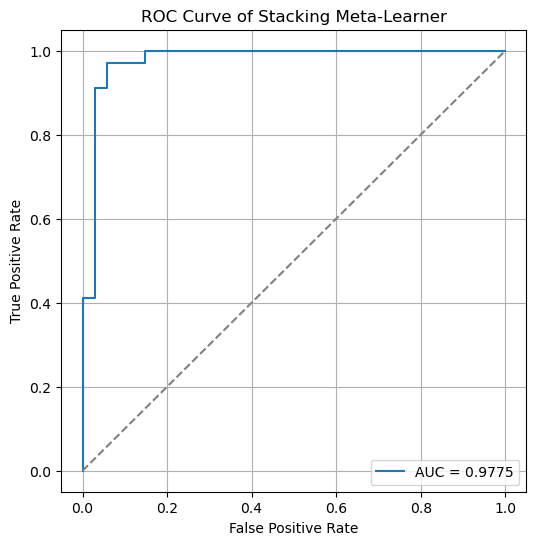

In [87]:
metrics_360_68 = evaluate_meta_model_with_ci(y_test_68, final_probs_LR_360_68, threshold=0.5)

AUC: 0.9624 (95% CI: 0.9128 - 0.9974)
Sensitivity: 0.8797 (95% CI: 0.7667 - 0.9722)
Specificity: 0.8826 (95% CI: 0.7576 - 0.9737)
PPV: 0.8825 (95% CI: 0.7500 - 0.9737)
NPV: 0.8799 (95% CI: 0.7647 - 0.9722)
F1-score: 0.8795 (95% CI: 0.7887 - 0.9538)
MCC: 0.7623 (95% CI: 0.5896 - 0.9112)
PR-AUC: 0.9575 (95% CI: 0.8985 - 0.9979)


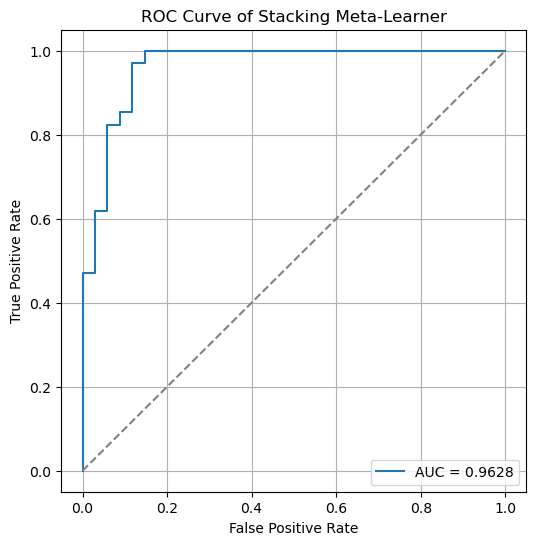

In [88]:
metrics_1980_68 = evaluate_meta_model_with_ci(y_test_68, final_probs_LR_1980_68, threshold=0.5)

AUC: 0.9492 (95% CI: 0.8915 - 0.9905)
Sensitivity: 0.8797 (95% CI: 0.7667 - 0.9722)
Specificity: 0.9408 (95% CI: 0.8438 - 1.0000)
PPV: 0.9372 (95% CI: 0.8333 - 1.0000)
NPV: 0.8865 (95% CI: 0.7777 - 0.9737)
F1-score: 0.9062 (95% CI: 0.8333 - 0.9722)
MCC: 0.8220 (95% CI: 0.6833 - 0.9427)
PR-AUC: 0.9491 (95% CI: 0.8808 - 0.9925)


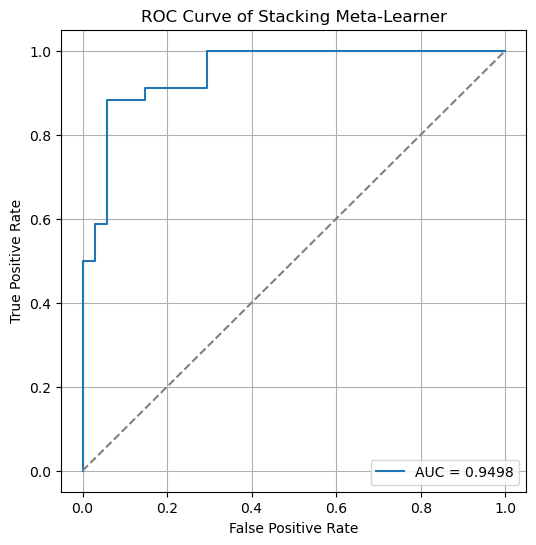

In [89]:
metrics_3780_68 = evaluate_meta_model_with_ci(y_test_68, final_probs_LR_3780_68, threshold=0.5)

AUC: 0.9424 (95% CI: 0.8840 - 0.9870)
Sensitivity: 0.8514 (95% CI: 0.7273 - 0.9655)
Specificity: 0.9122 (95% CI: 0.8064 - 1.0000)
PPV: 0.9066 (95% CI: 0.7879 - 1.0000)
NPV: 0.8601 (95% CI: 0.7368 - 0.9688)
F1-score: 0.8764 (95% CI: 0.7879 - 0.9552)
MCC: 0.7651 (95% CI: 0.6106 - 0.9120)
PR-AUC: 0.9491 (95% CI: 0.8906 - 0.9905)


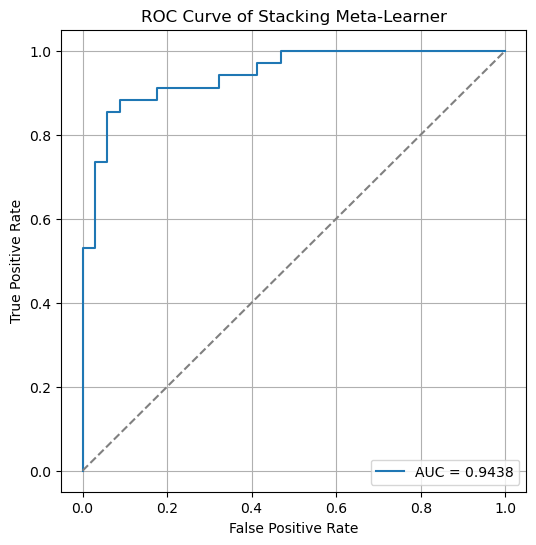

In [90]:
metrics_5580_68 = evaluate_meta_model_with_ci(y_test_68, final_probs_LR_5580_68, threshold=0.5)

AUC: 0.9475 (95% CI: 0.9165 - 0.9726)
Sensitivity: 0.9701 (95% CI: 0.9000 - 1.0000)
Specificity: 0.7641 (95% CI: 0.7211 - 0.8064)
PPV: 0.2937 (95% CI: 0.2095 - 0.3786)
NPV: 0.9961 (95% CI: 0.9880 - 1.0000)
F1-score: 0.4492 (95% CI: 0.3439 - 0.5443)
MCC: 0.4602 (95% CI: 0.3763 - 0.5375)
PR-AUC: 0.6696 (95% CI: 0.4979 - 0.8171)


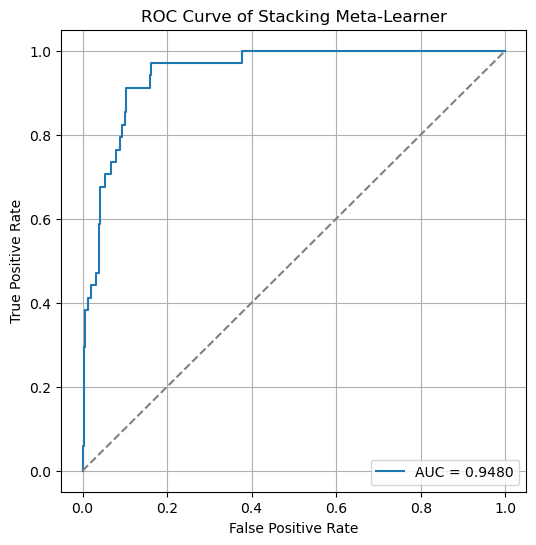

In [91]:
metrics_360_374 = evaluate_meta_model_with_ci(y_test_374, final_probs_LR_360_374, threshold=0.5)

AUC: 0.9521 (95% CI: 0.9245 - 0.9743)
Sensitivity: 0.8821 (95% CI: 0.7600 - 0.9730)
Specificity: 0.8612 (95% CI: 0.8247 - 0.8943)
PPV: 0.3913 (95% CI: 0.2823 - 0.5000)
NPV: 0.9864 (95% CI: 0.9718 - 0.9968)
F1-score: 0.5399 (95% CI: 0.4166 - 0.6452)
MCC: 0.5288 (95% CI: 0.4155 - 0.6251)
PR-AUC: 0.6595 (95% CI: 0.4888 - 0.8227)


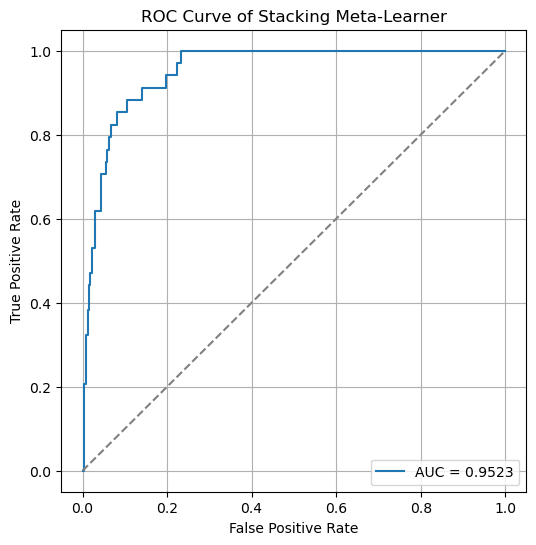

In [92]:
metrics_1980_374 = evaluate_meta_model_with_ci(y_test_374, final_probs_LR_1980_374, threshold=0.5)

AUC: 0.9389 (95% CI: 0.8984 - 0.9742)
Sensitivity: 0.8821 (95% CI: 0.7600 - 0.9730)
Specificity: 0.8728 (95% CI: 0.8377 - 0.9062)
PPV: 0.4120 (95% CI: 0.3051 - 0.5218)
NPV: 0.9865 (95% CI: 0.9721 - 0.9968)
F1-score: 0.5594 (95% CI: 0.4420 - 0.6667)
MCC: 0.5475 (95% CI: 0.4353 - 0.6489)
PR-AUC: 0.6751 (95% CI: 0.5017 - 0.8329)


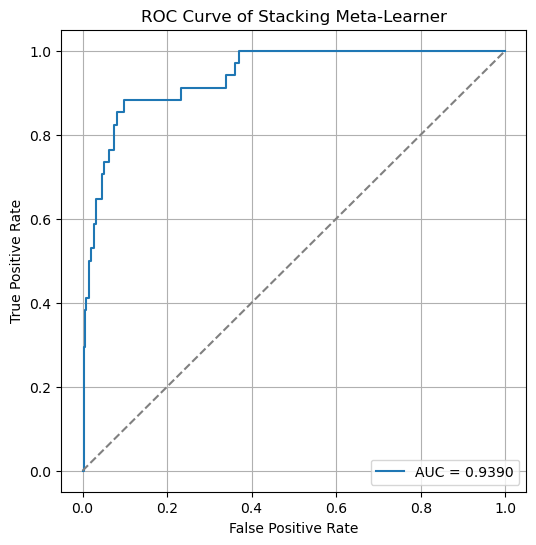

In [93]:
metrics_3780_374 = evaluate_meta_model_with_ci(y_test_374, final_probs_LR_3780_374, threshold=0.5)

AUC: 0.9312 (95% CI: 0.8851 - 0.9713)
Sensitivity: 0.8530 (95% CI: 0.7333 - 0.9677)
Specificity: 0.9026 (95% CI: 0.8727 - 0.9337)
PPV: 0.4698 (95% CI: 0.3499 - 0.5966)
NPV: 0.9838 (95% CI: 0.9683 - 0.9967)
F1-score: 0.6034 (95% CI: 0.4827 - 0.7158)
MCC: 0.5844 (95% CI: 0.4661 - 0.6929)
PR-AUC: 0.6799 (95% CI: 0.5065 - 0.8296)


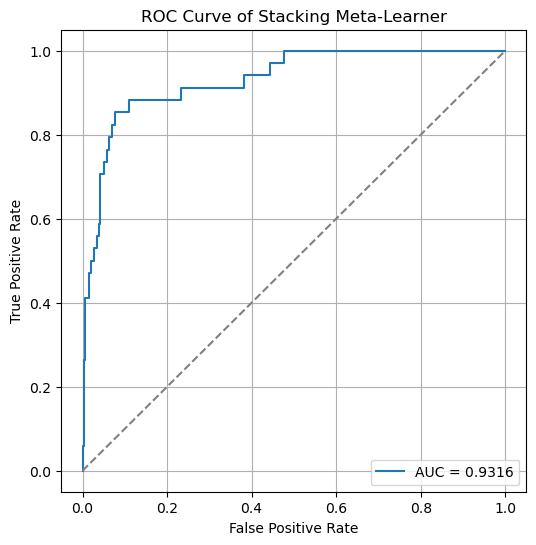

In [94]:
metrics_5580_374 = evaluate_meta_model_with_ci(y_test_374, final_probs_LR_5580_374, threshold=0.5)

AUC: 0.9507 (95% CI: 0.9210 - 0.9731)
Sensitivity: 0.9702 (95% CI: 0.9000 - 1.0000)
Specificity: 0.7370 (95% CI: 0.7031 - 0.7691)
PPV: 0.1561 (95% CI: 0.1071 - 0.2079)
NPV: 0.9980 (95% CI: 0.9939 - 1.0000)
F1-score: 0.2680 (95% CI: 0.1927 - 0.3435)
MCC: 0.3290 (95% CI: 0.2667 - 0.3913)
PR-AUC: 0.5843 (95% CI: 0.4163 - 0.7281)


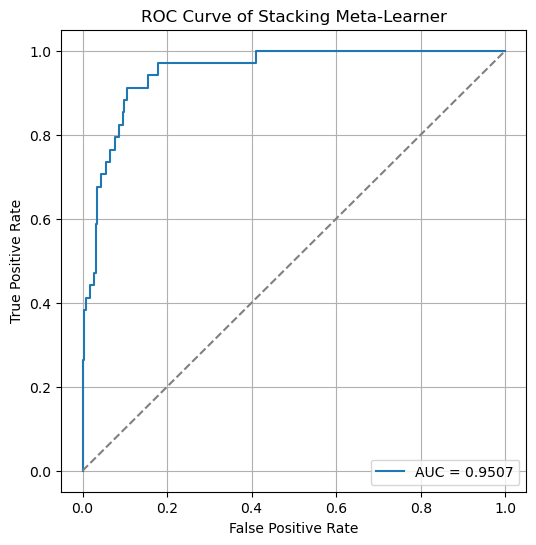

In [95]:
metrics_360_714 = evaluate_meta_model_with_ci(y_test_714, final_probs_LR_360_714, threshold=0.5)

AUC: 0.9534 (95% CI: 0.9266 - 0.9749)
Sensitivity: 0.8806 (95% CI: 0.7576 - 0.9706)
Specificity: 0.8633 (95% CI: 0.8375 - 0.8879)
PPV: 0.2440 (95% CI: 0.1703 - 0.3212)
NPV: 0.9931 (95% CI: 0.9862 - 0.9983)
F1-score: 0.3806 (95% CI: 0.2802 - 0.4748)
MCC: 0.4188 (95% CI: 0.3292 - 0.4995)
PR-AUC: 0.5658 (95% CI: 0.4020 - 0.7286)


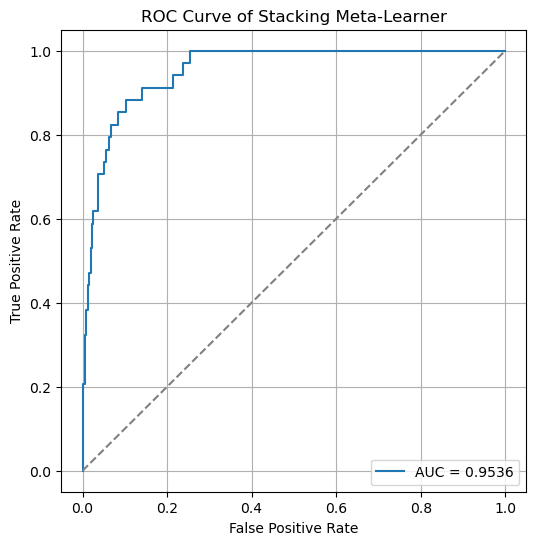

In [96]:
metrics_1980_714 = evaluate_meta_model_with_ci(y_test_714, final_probs_LR_1980_714, threshold=0.5)

AUC: 0.9393 (95% CI: 0.8957 - 0.9704)
Sensitivity: 0.8806 (95% CI: 0.7576 - 0.9706)
Specificity: 0.8518 (95% CI: 0.8252 - 0.8779)
PPV: 0.2294 (95% CI: 0.1579 - 0.3015)
NPV: 0.9930 (95% CI: 0.9860 - 0.9983)
F1-score: 0.3625 (95% CI: 0.2647 - 0.4520)
MCC: 0.4025 (95% CI: 0.3125 - 0.4779)
PR-AUC: 0.5928 (95% CI: 0.4051 - 0.7541)


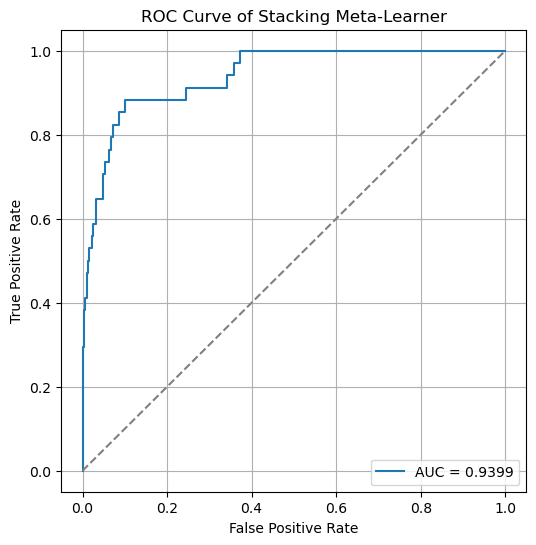

In [97]:
metrics_3780_714 = evaluate_meta_model_with_ci(y_test_714, final_probs_LR_3780_714, threshold=0.5)

AUC: 0.9307 (95% CI: 0.8802 - 0.9676)
Sensitivity: 0.8502 (95% CI: 0.7188 - 0.9615)
Specificity: 0.8750 (95% CI: 0.8507 - 0.8973)
PPV: 0.2542 (95% CI: 0.1750 - 0.3333)
NPV: 0.9915 (95% CI: 0.9830 - 0.9983)
F1-score: 0.3897 (95% CI: 0.2857 - 0.4841)
MCC: 0.4209 (95% CI: 0.3269 - 0.5049)
PR-AUC: 0.5986 (95% CI: 0.4314 - 0.7518)


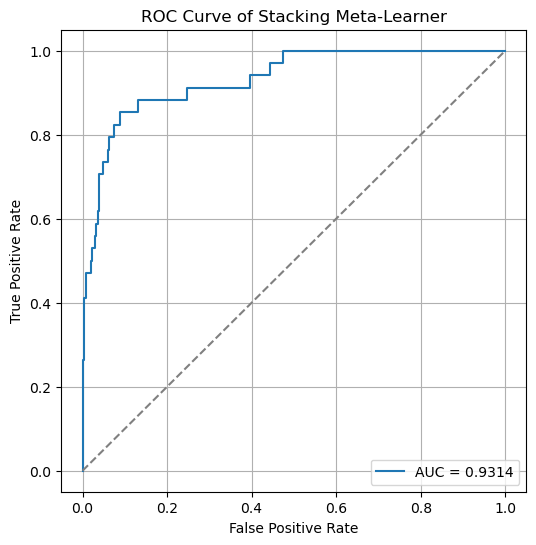

In [98]:
metrics_5580_714 = evaluate_meta_model_with_ci(y_test_714, final_probs_LR_5580_714, threshold=0.5)

AUC: 0.9494 (95% CI: 0.9202 - 0.9716)
Sensitivity: 0.9696 (95% CI: 0.9000 - 1.0000)
Specificity: 0.7366 (95% CI: 0.7097 - 0.7646)
PPV: 0.1081 (95% CI: 0.0753 - 0.1444)
NPV: 0.9986 (95% CI: 0.9960 - 1.0000)
F1-score: 0.1940 (95% CI: 0.1397 - 0.2520)
MCC: 0.2736 (95% CI: 0.2221 - 0.3232)
PR-AUC: 0.5123 (95% CI: 0.3408 - 0.6644)


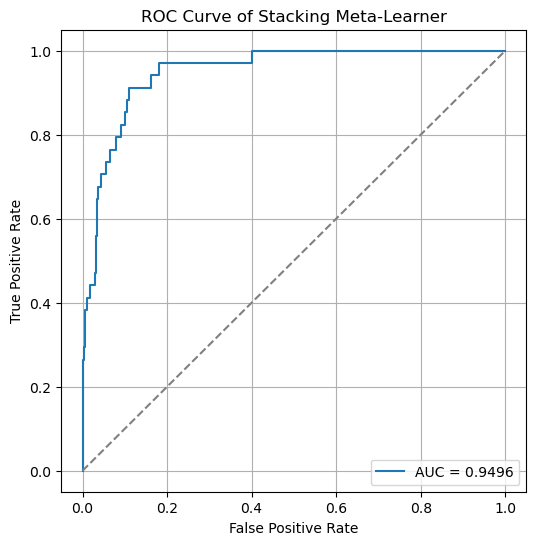

In [99]:
metrics_360_1054 = evaluate_meta_model_with_ci(y_test_1054, final_probs_LR_360_1054, threshold=0.5)

AUC: 0.9536 (95% CI: 0.9273 - 0.9755)
Sensitivity: 0.8831 (95% CI: 0.7632 - 0.9756)
Specificity: 0.8558 (95% CI: 0.8356 - 0.8771)
PPV: 0.1678 (95% CI: 0.1117 - 0.2235)
NPV: 0.9955 (95% CI: 0.9908 - 0.9989)
F1-score: 0.2810 (95% CI: 0.1970 - 0.3585)
MCC: 0.3463 (95% CI: 0.2667 - 0.4179)
PR-AUC: 0.5111 (95% CI: 0.3425 - 0.6756)


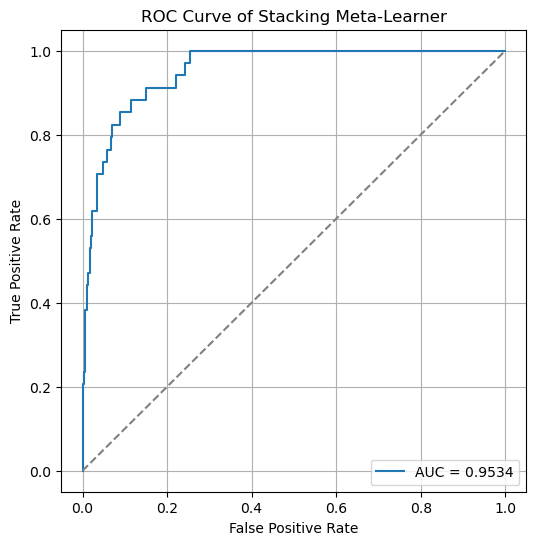

In [100]:
metrics_1980_1054 = evaluate_meta_model_with_ci(y_test_1054, final_probs_LR_1980_1054, threshold=0.5)

AUC: 0.9407 (95% CI: 0.9027 - 0.9720)
Sensitivity: 0.8831 (95% CI: 0.7632 - 0.9756)
Specificity: 0.8514 (95% CI: 0.8285 - 0.8722)
PPV: 0.1636 (95% CI: 0.1093 - 0.2222)
NPV: 0.9955 (95% CI: 0.9908 - 0.9989)
F1-score: 0.2751 (95% CI: 0.1939 - 0.3568)
MCC: 0.3408 (95% CI: 0.2625 - 0.4086)
PR-AUC: 0.5213 (95% CI: 0.3452 - 0.6783)


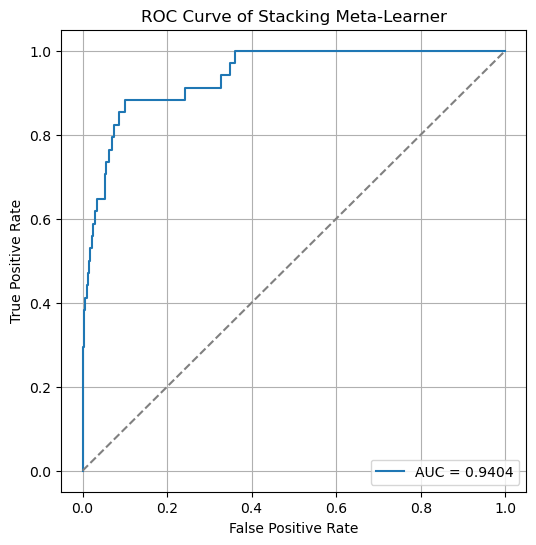

In [101]:
metrics_3780_1054 = evaluate_meta_model_with_ci(y_test_1054, final_probs_LR_3780_1054, threshold=0.5)

AUC: 0.9330 (95% CI: 0.8904 - 0.9695)
Sensitivity: 0.8545 (95% CI: 0.7272 - 0.9655)
Specificity: 0.8674 (95% CI: 0.8468 - 0.8877)
PPV: 0.1750 (95% CI: 0.1180 - 0.2349)
NPV: 0.9945 (95% CI: 0.9894 - 0.9989)
F1-score: 0.2895 (95% CI: 0.2051 - 0.3736)
MCC: 0.3488 (95% CI: 0.2632 - 0.4243)
PR-AUC: 0.5341 (95% CI: 0.3581 - 0.6858)


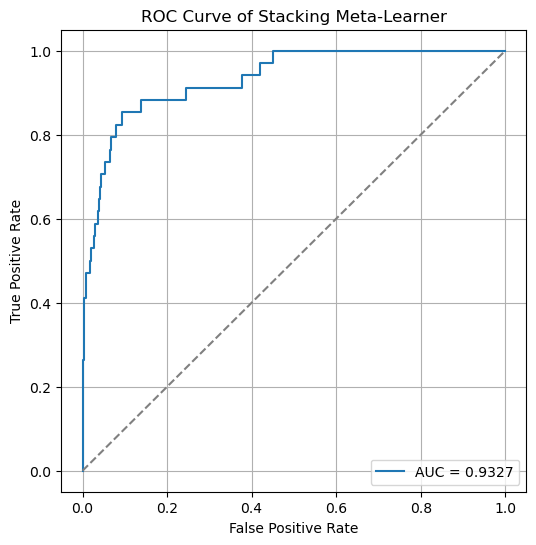

In [102]:
metrics_5580_1054 = evaluate_meta_model_with_ci(y_test_1054, final_probs_LR_5580_1054, threshold=0.5)

AUC: 0.9461 (95% CI: 0.9150 - 0.9700)
Sensitivity: 0.9708 (95% CI: 0.8999 - 1.0000)
Specificity: 0.7254 (95% CI: 0.7157 - 0.7345)
PPV: 0.0160 (95% CI: 0.0109 - 0.0220)
NPV: 0.9998 (95% CI: 0.9994 - 1.0000)
F1-score: 0.0315 (95% CI: 0.0215 - 0.0430)
MCC: 0.1045 (95% CI: 0.0838 - 0.1239)
PR-AUC: 0.1983 (95% CI: 0.0819 - 0.3450)


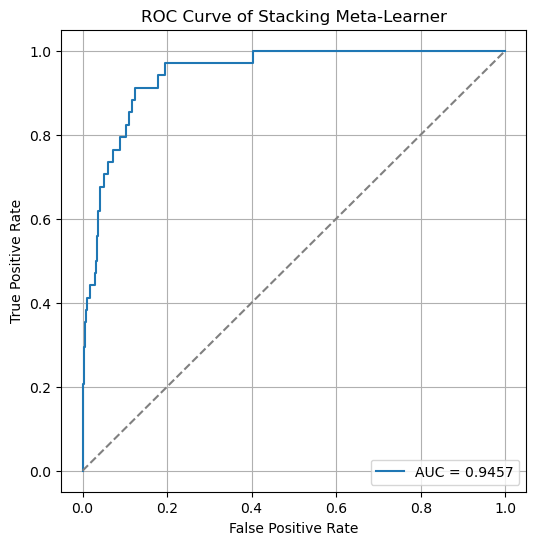

In [103]:
metrics_360_7382 = evaluate_meta_model_with_ci(y_test_7382, final_probs_LR_360_7382, threshold=0.5)

AUC: 0.9525 (95% CI: 0.9246 - 0.9741)
Sensitivity: 0.8825 (95% CI: 0.7500 - 0.9714)
Specificity: 0.8478 (95% CI: 0.8398 - 0.8562)
PPV: 0.0260 (95% CI: 0.0175 - 0.0360)
NPV: 0.9994 (95% CI: 0.9987 - 0.9998)
F1-score: 0.0504 (95% CI: 0.0341 - 0.0692)
MCC: 0.1355 (95% CI: 0.1040 - 0.1659)
PR-AUC: 0.1644 (95% CI: 0.0749 - 0.2834)


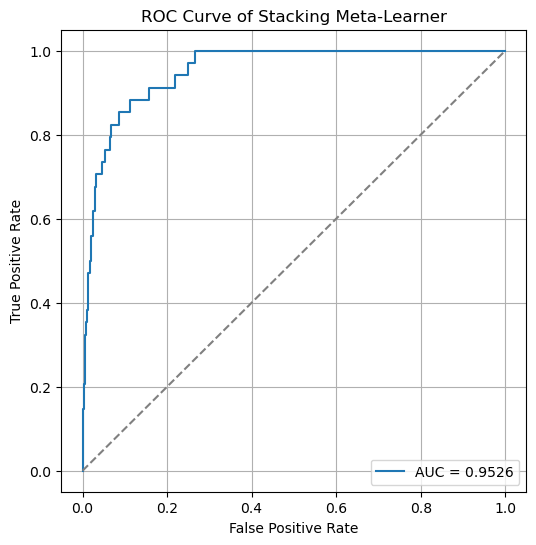

In [104]:
metrics_1980_7382 = evaluate_meta_model_with_ci(y_test_7382, final_probs_LR_1980_7382, threshold=0.5)

AUC: 0.9384 (95% CI: 0.8994 - 0.9700)
Sensitivity: 0.8825 (95% CI: 0.7500 - 0.9714)
Specificity: 0.8526 (95% CI: 0.8446 - 0.8605)
PPV: 0.0268 (95% CI: 0.0178 - 0.0372)
NPV: 0.9994 (95% CI: 0.9987 - 0.9998)
F1-score: 0.0520 (95% CI: 0.0349 - 0.0716)
MCC: 0.1382 (95% CI: 0.1063 - 0.1687)
PR-AUC: 0.1629 (95% CI: 0.0703 - 0.2893)


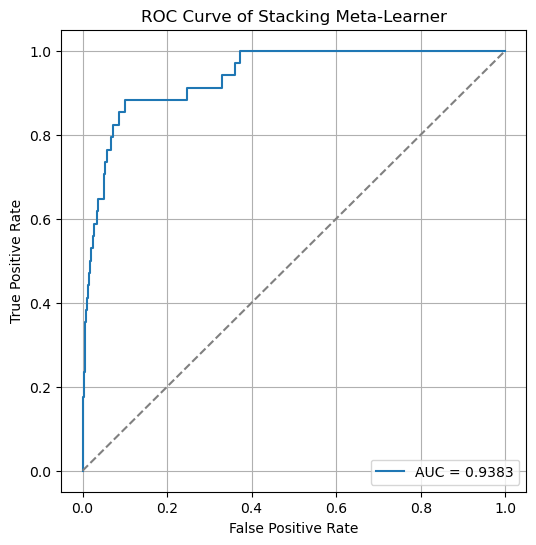

In [105]:
metrics_3780_7382 = evaluate_meta_model_with_ci(y_test_7382, final_probs_LR_3780_7382, threshold=0.5)

AUC: 0.9305 (95% CI: 0.8820 - 0.9671)
Sensitivity: 0.8540 (95% CI: 0.7222 - 0.9643)
Specificity: 0.8698 (95% CI: 0.8624 - 0.8776)
PPV: 0.0293 (95% CI: 0.0190 - 0.0409)
NPV: 0.9992 (95% CI: 0.9986 - 0.9998)
F1-score: 0.0566 (95% CI: 0.0372 - 0.0782)
MCC: 0.1431 (95% CI: 0.1072 - 0.1765)
PR-AUC: 0.2053 (95% CI: 0.0841 - 0.3398)


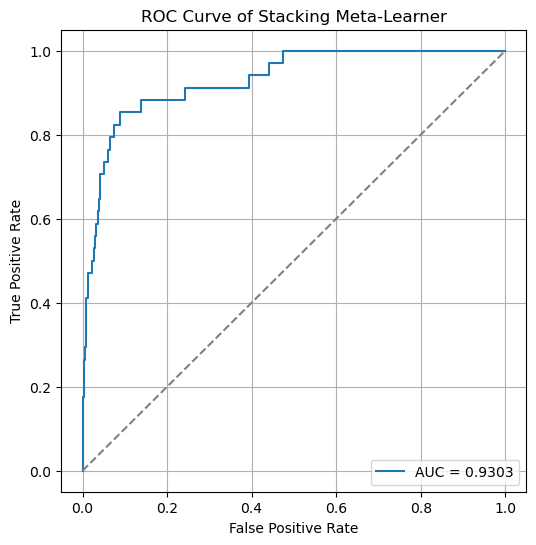

In [106]:
metrics_5580_7382 = evaluate_meta_model_with_ci(y_test_7382, final_probs_LR_5580_7382, threshold=0.5)

In [107]:
##############################################################################
# Baseline Single-Model Comparison + DeLong Test for Ensemble Superiority
##############################################################################

def delong_test(y_true, probs_a, probs_b):
    """DeLong test comparing two AUCs. Returns z-statistic and two-sided p-value."""
    n = len(y_true)
    pos = y_true == 1
    neg = y_true == 0
    n1, n0 = pos.sum(), neg.sum()

    def placement_values(probs):
        V10 = np.array([np.mean(probs[neg] < p) + 0.5 * np.mean(probs[neg] == p) for p in probs[pos]])
        V01 = np.array([np.mean(probs[pos] > q) + 0.5 * np.mean(probs[pos] == q) for q in probs[neg]])
        return V10, V01

    V10_a, V01_a = placement_values(probs_a)
    V10_b, V01_b = placement_values(probs_b)
    S10 = np.cov(np.vstack([V10_a, V10_b]))
    S01 = np.cov(np.vstack([V01_a, V01_b]))
    S = S10 / n1 + S01 / n0
    auc_a = roc_auc_score(y_true, probs_a)
    auc_b = roc_auc_score(y_true, probs_b)
    diff = auc_a - auc_b
    var = S[0, 0] + S[1, 1] - 2 * S[0, 1]
    z = diff / np.sqrt(var + 1e-10)
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p_value

def evaluate_single_model_ci(y_true, y_prob, threshold=0.5, n_bootstrap=1000, seed=42):
    """Bootstrap 95% CI for a single base model."""
    np.random.seed(seed)
    n = len(y_true)
    records = {'AUC': [], 'Sens': [], 'Spec': [], 'PPV': [], 'NPV': [], 'F1': [], 'MCC': [], 'PR-AUC': []}
    for _ in range(n_bootstrap):
        idx = np.random.choice(n, n, replace=True)
        yt, yp = y_true[idx], y_prob[idx]
        ypred = (yp >= threshold).astype(int)
        try:
            tn, fp, fn, tp = confusion_matrix(yt, ypred).ravel()
            records['AUC'].append(roc_auc_score(yt, yp))
            records['Sens'].append(tp / (tp + fn))
            records['Spec'].append(tn / (tn + fp))
            records['PPV'].append(tp / (tp + fp) if tp + fp > 0 else 0)
            records['NPV'].append(tn / (tn + fn) if tn + fn > 0 else 0)
            records['F1'].append(f1_score(yt, ypred))
            records['MCC'].append(matthews_corrcoef(yt, ypred))
            records['PR-AUC'].append(average_precision_score(yt, yp))
        except:
            continue
    result = {}
    for k, v in records.items():
        result[k] = (np.mean(v), np.percentile(v, 2.5), np.percentile(v, 97.5))
    return result

# --- Run comparison on training size 5580, test set 7382 ---
print("=" * 80)
print("BASELINE COMPARISON: Single Models vs. Ensemble (Train=5580, Test=7382)")
print("=" * 80)

models_preds = {
    'RF-only': test_preds_RF_5580_7382,
    'LGBM-only': test_preds_LGBM_5580_7382,
    'DNN-only': test_preds_DNN_5580_7382,
    'Ensemble': final_probs_LR_5580_7382
}

def find_optimal_threshold(y_true, y_prob):
    """Youden's J optimal threshold from ROC curve."""
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    j_scores = tpr - fpr
    return thresholds[np.argmax(j_scores)]

for name, probs in models_preds.items():
    opt_thresh = find_optimal_threshold(y_test_7382, probs)
    ci = evaluate_single_model_ci(y_test_7382, probs, threshold=opt_thresh)
    print(f"\n--- {name} (threshold={opt_thresh:.4f}) ---")
    for metric, (mean, lo, hi) in ci.items():
        print(f"  {metric}: {mean:.4f} (95% CI: {lo:.4f} - {hi:.4f})")

# DeLong tests: each single model vs ensemble
print("\n" + "=" * 80)
print("DeLong Test: Single Model AUC vs. Ensemble AUC")
print("=" * 80)
for name, probs in [('RF-only', test_preds_RF_5580_7382),
                     ('LGBM-only', test_preds_LGBM_5580_7382),
                     ('DNN-only', test_preds_DNN_5580_7382)]:
    z, p = delong_test(y_test_7382, final_probs_LR_5580_7382, probs)
    ens_auc = roc_auc_score(y_test_7382, final_probs_LR_5580_7382)
    base_auc = roc_auc_score(y_test_7382, probs)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"  Ensemble ({ens_auc:.4f}) vs {name} ({base_auc:.4f}): z={z:.3f}, p={p:.4f} {sig}")

BASELINE COMPARISON: Single Models vs. Ensemble (Train=5580, Test=7382)

--- RF-only (threshold=0.0560) ---
  AUC: 0.9576 (95% CI: 0.9327 - 0.9761)
  Sens: 0.9420 (95% CI: 0.8571 - 1.0000)
  Spec: 0.8671 (95% CI: 0.8596 - 0.8745)
  PPV: 0.0315 (95% CI: 0.0216 - 0.0433)
  NPV: 0.9997 (95% CI: 0.9992 - 1.0000)
  F1: 0.0610 (95% CI: 0.0421 - 0.0830)
  MCC: 0.1584 (95% CI: 0.1280 - 0.1900)
  PR-AUC: 0.1849 (95% CI: 0.0813 - 0.3171)

--- LGBM-only (threshold=0.4415) ---
  AUC: 0.8249 (95% CI: 0.7424 - 0.9016)
  Sens: 0.6818 (95% CI: 0.5161 - 0.8387)
  Spec: 0.8598 (95% CI: 0.8521 - 0.8679)
  PPV: 0.0219 (95% CI: 0.0133 - 0.0310)
  NPV: 0.9983 (95% CI: 0.9972 - 0.9992)
  F1: 0.0423 (95% CI: 0.0261 - 0.0596)
  MCC: 0.1041 (95% CI: 0.0688 - 0.1370)
  PR-AUC: 0.0998 (95% CI: 0.0348 - 0.2116)

--- DNN-only (threshold=0.0118) ---
  AUC: 0.8245 (95% CI: 0.7145 - 0.9090)
  Sens: 0.6795 (95% CI: 0.5135 - 0.8235)
  Spec: 0.8832 (95% CI: 0.8763 - 0.8904)
  PPV: 0.0261 (95% CI: 0.0164 - 0.0384)
  NPV: 

# 10. External Validation (eICU)

1. Check for data leakage.
2. Eliminate leaking features.
3. Run validation with trained models.

## 10.1 Data Leakage Check

In [67]:
# Read eICU raw dataset
meningitis_val_raw = pd.read_csv('Meningitis_val_raw.csv')
nonmeningitis_val_raw = pd.read_csv('nonmeningitis_val_raw.csv')

In [68]:
# Check whether there are meningitis related columns (starting with '32') in Meningitis external validation dataset
print("Checking for columns starting with '32' in meningitis_val_raw...")
print("="*60)

# Get all column names
all_columns_men_val = meningitis_val_raw.columns.tolist()

# Find columns that start with "32"
columns_starting_32_men_val = [col for col in all_columns_men_val if str(col).startswith(('320','321','322'))]

print(f"Total columns in dataset: {len(all_columns_men_val)}")
print(f"Columns starting with '32': {len(columns_starting_32_men_val)}")
print()

if columns_starting_32_men_val:
    print("Found columns starting with '32':")
    print("-" * 40)
    
    # Sort the columns for better readability
    columns_starting_32_sorted_men_val = sorted(columns_starting_32_men_val)
    
    for i, col in enumerate(columns_starting_32_sorted_men_val, 1):
        # Check how many patients have this code
        count = meningitis_val_raw[col].sum() if col in meningitis_val_raw.columns else 0
        percentage = (count / len(meningitis_val_raw)) * 100 if len(meningitis_val_raw) > 0 else 0
        
        # Check positive rate when this code is present
        if count > 0:
            pos_rate = meningitis_val_raw[meningitis_val_raw[col] == 1]['CLASSIFIER'].mean()
        else:
            pos_rate = 0
            
        print(f"{i:2d}. {str(col):<8} - Present in {int(count):4d} patients ({percentage:5.2f}%) - Pos rate: {pos_rate:.3f}")
    
    print()
    print("Detailed analysis of '32' codes:")
    print("-" * 50)
    
    # Group by length for better understanding
    length_groups = {}
    for col in columns_starting_32_sorted_men_val:
        length = len(str(col))
        if length not in length_groups:
            length_groups[length] = []
        length_groups[length].append(col)
    
    for length in sorted(length_groups.keys()):
        print(f"\nLength {length} codes ({len(length_groups[length])} codes):")
        for col in length_groups[length]:
            count = int(meningitis_val_raw[col].sum())
            percentage = (count / len(meningitis_val_raw)) * 100
            if count > 0:
                pos_rate = meningitis_val_raw[meningitis_val_raw[col] == 1]['CLASSIFIER'].mean()
                print(f"  {str(col)}: {count} patients ({percentage:.2f}%) - Meningitis rate: {pos_rate:.3f}")
            else:
                print(f"  {str(col)}: {count} patients ({percentage:.2f}%) - No patients with this code")

Checking for columns starting with '32' in meningitis_val_raw...
Total columns in dataset: 211
Columns starting with '32': 11

Found columns starting with '32':
----------------------------------------
 1. 3200     - Present in    4 patients ( 3.23%) - Pos rate: 1.000
 2. 3201     - Present in    3 patients ( 2.42%) - Pos rate: 1.000
 3. 3203     - Present in    1 patients ( 0.81%) - Pos rate: 1.000
 4. 3207     - Present in   36 patients (29.03%) - Pos rate: 1.000
 5. 32082    - Present in    2 patients ( 1.61%) - Pos rate: 1.000
 6. 3209     - Present in    5 patients ( 4.03%) - Pos rate: 1.000
 7. 3211     - Present in   10 patients ( 8.06%) - Pos rate: 1.000
 8. 3212     - Present in   10 patients ( 8.06%) - Pos rate: 1.000
 9. 3220     - Present in    3 patients ( 2.42%) - Pos rate: 1.000
10. 3222     - Present in   10 patients ( 8.06%) - Pos rate: 1.000
11. 3229     - Present in   41 patients (33.06%) - Pos rate: 1.000

Detailed analysis of '32' codes:
---------------------------

In [69]:
# Check whether there are meningitis related columns (starting with '32') in non-meningitis external validation dataset
print("Checking for columns starting with '32' in nonmeningitis_val_raw...")
print("="*60)

# Get all column names
all_columns_nonmen_val = nonmeningitis_val_raw.columns.tolist()

# Find columns that start with "32"
columns_starting_32_nonmen_val = [col for col in all_columns_nonmen_val if str(col).startswith(('320','321','322'))]

print(f"Total columns in dataset: {len(all_columns_nonmen_val)}")
print(f"Columns starting with '32': {len(columns_starting_32_nonmen_val)}")
print()

if columns_starting_32_nonmen_val:
    print("Found columns starting with '32':")
    print("-" * 40)
    
    # Sort the columns for better readability
    columns_starting_32_sorted_nonmen_val = sorted(columns_starting_32_nonmen_val)
    
    for i, col in enumerate(columns_starting_32_sorted_nonmen_val, 1):
        # Check how many patients have this code
        count = nonmeningitis_val_raw[col].sum() if col in nonmeningitis_val_raw.columns else 0
        percentage = (count / len(nonmeningitis_val_raw)) * 100 if len(nonmeningitis_val_raw) > 0 else 0
        
        # Check positive rate when this code is present
        if count > 0:
            pos_rate = nonmeningitis_val_raw[nonmeningitis_val_raw[col] == 1]['CLASSIFIER'].mean()
        else:
            pos_rate = 0
            
        print(f"{i:2d}. {str(col):<8} - Present in {int(count):4d} patients ({percentage:5.2f}%) - Pos rate: {pos_rate:.3f}")
    
    print()
    print("Detailed analysis of '32' codes:")
    print("-" * 50)
    
    # Group by length for better understanding
    length_groups = {}
    for col in columns_starting_32_sorted_nonmen_val:
        length = len(str(col))
        if length not in length_groups:
            length_groups[length] = []
        length_groups[length].append(col)
    
    for length in sorted(length_groups.keys()):
        print(f"\nLength {length} codes ({len(length_groups[length])} codes):")
        for col in length_groups[length]:
            count = int(nonmeningitis_val_raw[col].sum())
            percentage = (count / len(nonmeningitis_val_raw)) * 100
            if count > 0:
                pos_rate = nonmeningitis_val_raw[nonmeningitis_val_raw[col] == 1]['CLASSIFIER'].mean()
                print(f"  {str(col)}: {count} patients ({percentage:.2f}%) - Meningitis rate: {pos_rate:.3f}")
            else:
                print(f"  {str(col)}: {count} patients ({percentage:.2f}%) - No patients with this code")

Checking for columns starting with '32' in nonmeningitis_val_raw...
Total columns in dataset: 844
Columns starting with '32': 0



In [70]:
# # Create new dataset without meningitis code columns
meningitis_clean_val = meningitis_val_raw.drop(columns=columns_starting_32_men_val)

In [71]:
# Check columns that start with "('320','321','322')"
all_columns_clean_men_val = meningitis_clean_val.columns.tolist()

columns_starting_32_clean_val = [col for col in all_columns_clean_men_val if str(col).startswith(('320','321','322'))]

print(f"Total columns in dataset: {len(all_columns_clean_men_val)}")
print(f"Columns starting with '('320','321','322')': {len(columns_starting_32_clean_val)}")
print()

Total columns in dataset: 200
Columns starting with '('320','321','322')': 0



In [72]:
# Check if there is meningitis sample in nonmeningitis_val_raw
(nonmeningitis_val_raw["CLASSIFIER"] == 1).any()

False

In [73]:
# Check shapes
print(meningitis_clean_val.shape)
print(nonmeningitis_val_raw.shape)
print(meningitis_clean_val.head)
print(nonmeningitis_val_raw.head)

(124, 200)
(140645, 844)
<bound method NDFrame.head of      SUBJECT_ID  GENDER  00845  0270  0360  0389  042  0479  0499  0539  ...  \
0        165513       0      0     0     0     1    0     0     0     0  ...   
1        187781       0      0     0     0     0    0     0     0     0  ...   
2        190797       0      0     0     0     1    0     1     0     0  ...   
3        211066       1      0     0     0     0    0     0     0     0  ...   
4        218037       1      0     0     0     1    0     0     0     0  ...   
..          ...     ...    ...   ...   ...   ...  ...   ...   ...   ...  ...   
119     2620178       0      0     0     0     1    0     0     0     0  ...   
120     2628810       1      0     0     0     0    0     0     0     0  ...   
121     2630479       0      0     0     0     0    0     0     0     0  ...   
122     2645000       0      0     0     0     0    0     0     0     0  ...   
123     2721993       1      0     0     0     1    0     0     0

In [74]:
# Ramdonly extract 124*10 = 1240, 124*20 = 2480, 124*30 = 3720, 124*218 = 27032 from nonmeningitis_val_raw for multiple external validation
non_men_1240_val = nonmeningitis_val_raw.sample(n=1240, random_state=42)
non_men_2480_val = nonmeningitis_val_raw.sample(n=2480, random_state=42)
non_men_3720_val = nonmeningitis_val_raw.sample(n=3720, random_state=42)
non_men_27032_val = nonmeningitis_val_raw.sample(n=27032, random_state=42)

In [75]:
print(non_men_1240_val)
print(non_men_2480_val)
print(non_men_3720_val)
print(non_men_27032_val)

        SUBJECT_ID  GENDER  0030  0049  0059  00800  00843  00845  0091  \
84955      1684464       1     0     0     0      0      0      0     0   
70884      1336950       1     0     0     0      0      0      0     0   
37021       759197       0     0     0     0      0      0      0     0   
18159       441147       1     0     0     0      0      0      0     0   
103237     2179235       1     0     0     0      0      0      0     0   
...            ...     ...   ...   ...   ...    ...    ...    ...   ...   
105776     2217563       0     0     0     0      0      0      0     0   
1644        150773       1     0     0     0      0      0      0     0   
58078      1168768       1     0     0     0      0      0      0     0   
110836     2291698       1     0     0     0      0      0      0     0   
27271       614226       0     0     0     0      0      0      0     0   

        01160  ...  99779  9980  99811  99831  99832  9984  99859  9989  9998  \
84955       0  ...

In [76]:
# Concatinate meningitis and nonmeningitis validation datasets
val_concat_1364 = pd.concat([meningitis_clean_val, non_men_1240_val], ignore_index = True)
val_concat_2604 = pd.concat([meningitis_clean_val, non_men_2480_val], ignore_index = True)
val_concat_3844 = pd.concat([meningitis_clean_val, non_men_3720_val], ignore_index = True)
val_concat_27156 = pd.concat([meningitis_clean_val, non_men_27032_val], ignore_index = True)

In [77]:
# Drop SUBJECT_ID of validation sets
val_IDdrop_1364 = val_concat_1364.drop('SUBJECT_ID', axis = 1)
val_IDdrop_2604 = val_concat_2604.drop('SUBJECT_ID', axis = 1)
val_IDdrop_3844 = val_concat_3844.drop('SUBJECT_ID', axis = 1)
val_IDdrop_27156 = val_concat_27156.drop('SUBJECT_ID', axis = 1)

In [78]:
# Shuffle the validation set to ensure random distribution
val_shuffled_1364 = val_IDdrop_1364.sample(frac=1, random_state=42).reset_index(drop=True)
val_shuffled_2604 = val_IDdrop_2604.sample(frac=1, random_state=42).reset_index(drop=True)
val_shuffled_3844 = val_IDdrop_3844.sample(frac=1, random_state=42).reset_index(drop=True)
val_shuffled_27156 = val_IDdrop_27156.sample(frac=1, random_state=42).reset_index(drop=True)

In [79]:
print(val_shuffled_1364.shape)
print(val_shuffled_2604.shape)
print(val_shuffled_3844.shape)
print(val_shuffled_27156.shape)

(1364, 846)
(2604, 846)
(3844, 846)
(27156, 846)


In [80]:
print("\n" + "NaN values in validation data (1364 samples):\n", val_shuffled_1364.isnull().sum())
print("\n" + "NaN values in validation data (2604 samples):\n", val_shuffled_2604.isnull().sum())
print("\n" + "NaN values in validation data (3844 samples):\n", val_shuffled_3844.isnull().sum())
print("\n" + "NaN values in validation data (27156 samples):\n", val_shuffled_27156.isnull().sum())


NaN values in validation data (1364 samples):
 GENDER       0
00845        0
0270      1240
0360      1240
0389         0
          ... 
99831      124
99832      124
9984       124
9989       124
9998       124
Length: 846, dtype: int64

NaN values in validation data (2604 samples):
 GENDER       0
00845        0
0270      2480
0360      2480
0389         0
          ... 
99831      124
99832      124
9984       124
9989       124
9998       124
Length: 846, dtype: int64

NaN values in validation data (3844 samples):
 GENDER       0
00845        0
0270      3720
0360      3720
0389         0
          ... 
99831      124
99832      124
9984       124
9989       124
9998       124
Length: 846, dtype: int64

NaN values in validation data (27156 samples):
 GENDER        0
00845         0
0270      27032
0360      27032
0389          0
          ...  
99831       124
99832       124
9984        124
9989        124
9998        124
Length: 846, dtype: int64


In [81]:
# Replace NaN values with 0 in each dataset
df_val_1364 = val_shuffled_1364.fillna(0)
df_val_2604 = val_shuffled_2604.fillna(0)
df_val_3844 = val_shuffled_3844.fillna(0)
df_val_27156 = val_shuffled_27156.fillna(0)

# Verify if NaN are replaced
print("\n" + "NaN values in validation data (1364 samples):\n", df_val_1364.isnull().sum())
print("\n" + "NaN values in validation data (2604 samples):\n", df_val_2604.isnull().sum())
print("\n" + "NaN values in validation data (3844 samples):\n", df_val_3844.isnull().sum())
print("\n" + "NaN values in validation data (27156 samples):\n", df_val_27156.isnull().sum())


NaN values in validation data (1364 samples):
 GENDER    0
00845     0
0270      0
0360      0
0389      0
         ..
99831     0
99832     0
9984      0
9989      0
9998      0
Length: 846, dtype: int64

NaN values in validation data (2604 samples):
 GENDER    0
00845     0
0270      0
0360      0
0389      0
         ..
99831     0
99832     0
9984      0
9989      0
9998      0
Length: 846, dtype: int64

NaN values in validation data (3844 samples):
 GENDER    0
00845     0
0270      0
0360      0
0389      0
         ..
99831     0
99832     0
9984      0
9989      0
9998      0
Length: 846, dtype: int64

NaN values in validation data (27156 samples):
 GENDER    0
00845     0
0270      0
0360      0
0389      0
         ..
99831     0
99832     0
9984      0
9989      0
9998      0
Length: 846, dtype: int64


In [82]:
# Check duplicate column names in validation datasets
print(df_val_1364.columns[df_val_1364.columns.duplicated()].unique()) 
print(df_val_2604.columns[df_val_2604.columns.duplicated()].unique()) 
print(df_val_3844.columns[df_val_3844.columns.duplicated()].unique()) 
print(df_val_27156.columns[df_val_27156.columns.duplicated()].unique()) 

Index([], dtype='object')
Index([], dtype='object')
Index([], dtype='object')
Index([], dtype='object')


In [83]:
# Use df_training
# Extract all column names from the training data as reference
train_columns = df_training.columns.tolist()
print(f"Training data has {len(train_columns)} columns")

Training data has 6970 columns


In [84]:
# Separate the target column (CLASSIFIER) from feature columns
# We align features only — the target column is handled separately
target_col = 'CLASSIFIER'
train_feature_cols = [col for col in train_columns if col != target_col]
print(f"Training has {len(train_feature_cols)} feature columns + '{target_col}'")

Training has 6969 feature columns + 'CLASSIFIER'


In [85]:
def align_to_train(df_val, train_feature_cols, target_col='CLASSIFIER'):
    """
    Align a validation DataFrame so its features match training exactly
    without iterative column insertion.
    """
    val_feature_cols = [c for c in df_val.columns if c != target_col]
    missing_cols = list(set(train_feature_cols) - set(val_feature_cols))
    
    print(f" Missing columns to add: {len(missing_cols)}")
    
    # Create a new DataFrame for all missing columns filled with 0 at once
    # This prevents the "highly fragmented" warning
    if missing_cols:
        missing_df = pd.DataFrame(0, index=df_val.index, columns=missing_cols)
        df_val = pd.concat([df_val, missing_df], axis=1)

    # Select only training features (in correct order) + target column
    df_val = df_val[train_feature_cols + [target_col]].copy()
    
    return df_val

In [86]:
# Align df_val_1364
print("Aligning df_val_1364:")
df_val_1364 = align_to_train(df_val_1364, train_feature_cols)
print(f"  Result shape: {df_val_1364.shape}\n")

Aligning df_val_1364:
 Missing columns to add: 6186
  Result shape: (1364, 6970)



In [87]:
# Align df_val_2604
print("Aligning df_val_2604:")
df_val_2604 = align_to_train(df_val_2604, train_feature_cols)
print(f"  Result shape: {df_val_2604.shape}\n")

Aligning df_val_2604:
 Missing columns to add: 6186
  Result shape: (2604, 6970)



In [88]:
# Align df_val_3844
print("Aligning df_val_3844:")
df_val_3844 = align_to_train(df_val_3844, train_feature_cols)
print(f"  Result shape: {df_val_3844.shape}\n")

Aligning df_val_3844:
 Missing columns to add: 6186
  Result shape: (3844, 6970)



In [89]:
# Align df_val_27156
print("Aligning df_val_27156:")
df_val_27156 = align_to_train(df_val_27156, train_feature_cols)
print(f"  Result shape: {df_val_27156.shape}\n")

Aligning df_val_27156:
 Missing columns to add: 6186
  Result shape: (27156, 6970)



In [90]:
# Align df_val_2604
print("Aligning df_val_2604:")
df_val_2604 = align_to_train(df_val_2604, train_feature_cols)
print(f"  Result shape: {df_val_2604.shape}\n")

Aligning df_val_2604:
 Missing columns to add: 0
  Result shape: (2604, 6970)



In [91]:
# Align df_val_3844
print("Aligning df_val_3844:")
df_val_3844 = align_to_train(df_val_3844, train_feature_cols)
print(f"  Result shape: {df_val_3844.shape}\n")

Aligning df_val_3844:
 Missing columns to add: 0
  Result shape: (3844, 6970)



In [92]:
# Align df_val_27156
print("Aligning df_val_27156:")
df_val_27156 = align_to_train(df_val_27156, train_feature_cols)
print(f"  Result shape: {df_val_27156.shape}\n")

Aligning df_val_27156:
 Missing columns to add: 0
  Result shape: (27156, 6970)



In [93]:
# Reorder validation columns to exactly match df_training column order
df_val_1364 = df_val_1364[df_training.columns]
df_val_2604 = df_val_2604[df_training.columns]
df_val_3844 = df_val_3844[df_training.columns]
df_val_27156 = df_val_27156[df_training.columns]

print("✓ All validation sets reordered to match training column order")

✓ All validation sets reordered to match training column order


In [94]:
# Verify all aligned shapes and column order match training
for name, df_val in [("df_val_1364", df_val_1364),
                      ("df_val_2604", df_val_2604),
                      ("df_val_3844", df_val_3844),
                      ("df_val_27156", df_val_27156)]:

    assert df_val.shape[1] == df_training.shape[1], \
        f"{name} has {df_val.shape[1]} cols, expected {df_training.shape[1]}"

    assert list(df_val.columns) == list(df_training.columns), \
        f"{name} columns do not match training columns"

    print(f"✓ {name} aligned — shape: {df_val.shape}")

✓ df_val_1364 aligned — shape: (1364, 6970)
✓ df_val_2604 aligned — shape: (2604, 6970)
✓ df_val_3844 aligned — shape: (3844, 6970)
✓ df_val_27156 aligned — shape: (27156, 6970)


In [95]:
# ──────────────────────────────────────────────────────────────────
# Step 1: Separate features (X) and labels (y) for each validation set
# Same pattern as: X_test_68 = df_testing_68.drop('CLASSIFIER', axis=1).values
# ──────────────────────────────────────────────────────────────────

X_val_1364  = df_val_1364.drop('CLASSIFIER', axis=1).values
X_val_2604  = df_val_2604.drop('CLASSIFIER', axis=1).values
X_val_3844  = df_val_3844.drop('CLASSIFIER', axis=1).values
X_val_27156 = df_val_27156.drop('CLASSIFIER', axis=1).values

y_val_1364  = df_val_1364['CLASSIFIER'].values
y_val_2604  = df_val_2604['CLASSIFIER'].values
y_val_3844  = df_val_3844['CLASSIFIER'].values
y_val_27156 = df_val_27156['CLASSIFIER'].values

print(f"X_val_1364:  {X_val_1364.shape},  y_val_1364:  {y_val_1364.shape}")
print(f"X_val_2604:  {X_val_2604.shape},  y_val_2604:  {y_val_2604.shape}")
print(f"X_val_3844:  {X_val_3844.shape},  y_val_3844:  {y_val_3844.shape}")
print(f"X_val_27156: {X_val_27156.shape}, y_val_27156: {y_val_27156.shape}")

X_val_1364:  (1364, 6969),  y_val_1364:  (1364,)
X_val_2604:  (2604, 6969),  y_val_2604:  (2604,)
X_val_3844:  (3844, 6969),  y_val_3844:  (3844,)
X_val_27156: (27156, 6969), y_val_27156: (27156,)


In [96]:
# ──────────────────────────────────────────────────────────────────
# Step 2: Get RF base model predictions (probability of class 1)
# Each trained model variant (360, 1980, 3780, 5580) predicts on
# each validation set → 4 models × 4 val sets = 16 prediction arrays
# ──────────────────────────────────────────────────────────────────

# RF predictions — model trained on 360 samples
test_preds_RF_360_1364  = model_RF_360.predict_proba(X_val_1364)[:, 1]
test_preds_RF_360_2604  = model_RF_360.predict_proba(X_val_2604)[:, 1]
test_preds_RF_360_3844  = model_RF_360.predict_proba(X_val_3844)[:, 1]
test_preds_RF_360_27156 = model_RF_360.predict_proba(X_val_27156)[:, 1]

# RF predictions — model trained on 1980 samples
test_preds_RF_1980_1364  = model_RF_1980.predict_proba(X_val_1364)[:, 1]
test_preds_RF_1980_2604  = model_RF_1980.predict_proba(X_val_2604)[:, 1]
test_preds_RF_1980_3844  = model_RF_1980.predict_proba(X_val_3844)[:, 1]
test_preds_RF_1980_27156 = model_RF_1980.predict_proba(X_val_27156)[:, 1]

# RF predictions — model trained on 3780 samples
test_preds_RF_3780_1364  = model_RF_3780.predict_proba(X_val_1364)[:, 1]
test_preds_RF_3780_2604  = model_RF_3780.predict_proba(X_val_2604)[:, 1]
test_preds_RF_3780_3844  = model_RF_3780.predict_proba(X_val_3844)[:, 1]
test_preds_RF_3780_27156 = model_RF_3780.predict_proba(X_val_27156)[:, 1]

# RF predictions — model trained on 5580 samples
test_preds_RF_5580_1364  = model_RF_5580.predict_proba(X_val_1364)[:, 1]
test_preds_RF_5580_2604  = model_RF_5580.predict_proba(X_val_2604)[:, 1]
test_preds_RF_5580_3844  = model_RF_5580.predict_proba(X_val_3844)[:, 1]
test_preds_RF_5580_27156 = model_RF_5580.predict_proba(X_val_27156)[:, 1]

print("✓ RF predictions complete for all validation sets")

✓ RF predictions complete for all validation sets


In [97]:
# ──────────────────────────────────────────────────────────────────
# Step 3: Get LightGBM base model predictions (probability of class 1)
# Same approach: 4 models × 4 val sets = 16 prediction arrays
# ──────────────────────────────────────────────────────────────────

# LGBM predictions — model trained on 360 samples
test_preds_LGBM_360_1364  = model_LGBM_360.predict_proba(X_val_1364)[:, 1]
test_preds_LGBM_360_2604  = model_LGBM_360.predict_proba(X_val_2604)[:, 1]
test_preds_LGBM_360_3844  = model_LGBM_360.predict_proba(X_val_3844)[:, 1]
test_preds_LGBM_360_27156 = model_LGBM_360.predict_proba(X_val_27156)[:, 1]

# LGBM predictions — model trained on 1980 samples
test_preds_LGBM_1980_1364  = model_LGBM_1980.predict_proba(X_val_1364)[:, 1]
test_preds_LGBM_1980_2604  = model_LGBM_1980.predict_proba(X_val_2604)[:, 1]
test_preds_LGBM_1980_3844  = model_LGBM_1980.predict_proba(X_val_3844)[:, 1]
test_preds_LGBM_1980_27156 = model_LGBM_1980.predict_proba(X_val_27156)[:, 1]

# LGBM predictions — model trained on 3780 samples
test_preds_LGBM_3780_1364  = model_LGBM_3780.predict_proba(X_val_1364)[:, 1]
test_preds_LGBM_3780_2604  = model_LGBM_3780.predict_proba(X_val_2604)[:, 1]
test_preds_LGBM_3780_3844  = model_LGBM_3780.predict_proba(X_val_3844)[:, 1]
test_preds_LGBM_3780_27156 = model_LGBM_3780.predict_proba(X_val_27156)[:, 1]

# LGBM predictions — model trained on 5580 samples
test_preds_LGBM_5580_1364  = model_LGBM_5580.predict_proba(X_val_1364)[:, 1]
test_preds_LGBM_5580_2604  = model_LGBM_5580.predict_proba(X_val_2604)[:, 1]
test_preds_LGBM_5580_3844  = model_LGBM_5580.predict_proba(X_val_3844)[:, 1]
test_preds_LGBM_5580_27156 = model_LGBM_5580.predict_proba(X_val_27156)[:, 1]

print("✓ LightGBM predictions complete for all validation sets")

✓ LightGBM predictions complete for all validation sets


In [140]:
# ──────────────────────────────────────────────────────────────────
# Step 4: Get DNN base model predictions
# DNN requires: (a) convert to PyTorch tensor, (b) forward pass,
# (c) apply softmax, (d) extract class-1 probability
# ──────────────────────────────────────────────────────────────────

# Convert validation features to PyTorch tensors on the correct device
X_val_tensor_1364  = torch.tensor(X_val_1364,  dtype=torch.float32).to(device)
X_val_tensor_2604  = torch.tensor(X_val_2604,  dtype=torch.float32).to(device)
X_val_tensor_3844  = torch.tensor(X_val_3844,  dtype=torch.float32).to(device)
X_val_tensor_27156 = torch.tensor(X_val_27156, dtype=torch.float32).to(device)

# DNN predictions — using all 4 model variants (360, 1980, 3780, 5580)
# Put each model in eval mode and disable gradient computation
for model_name, model_obj in [("DNN_360", model_DNN_360),
                               ("DNN_1980", model_DNN_1980),
                               ("DNN_3780", model_DNN_3780),
                               ("DNN_5580", model_DNN_5580)]:
    model_obj.eval()

with torch.no_grad():
    # model_DNN_360 predictions
    test_preds_DNN_360_1364  = torch.softmax(model_DNN_360(X_val_tensor_1364),  dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_360_2604  = torch.softmax(model_DNN_360(X_val_tensor_2604),  dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_360_3844  = torch.softmax(model_DNN_360(X_val_tensor_3844),  dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_360_27156 = torch.softmax(model_DNN_360(X_val_tensor_27156), dim=1)[:, 1].cpu().numpy()

    # model_DNN_1980 predictions
    test_preds_DNN_1980_1364  = torch.softmax(model_DNN_1980(X_val_tensor_1364),  dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_1980_2604  = torch.softmax(model_DNN_1980(X_val_tensor_2604),  dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_1980_3844  = torch.softmax(model_DNN_1980(X_val_tensor_3844),  dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_1980_27156 = torch.softmax(model_DNN_1980(X_val_tensor_27156), dim=1)[:, 1].cpu().numpy()

    # model_DNN_3780 predictions
    test_preds_DNN_3780_1364  = torch.softmax(model_DNN_3780(X_val_tensor_1364),  dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_3780_2604  = torch.softmax(model_DNN_3780(X_val_tensor_2604),  dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_3780_3844  = torch.softmax(model_DNN_3780(X_val_tensor_3844),  dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_3780_27156 = torch.softmax(model_DNN_3780(X_val_tensor_27156), dim=1)[:, 1].cpu().numpy()

    # model_DNN_5580 predictions
    test_preds_DNN_5580_1364  = torch.softmax(model_DNN_5580(X_val_tensor_1364),  dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_5580_2604  = torch.softmax(model_DNN_5580(X_val_tensor_2604),  dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_5580_3844  = torch.softmax(model_DNN_5580(X_val_tensor_3844),  dim=1)[:, 1].cpu().numpy()
    test_preds_DNN_5580_27156 = torch.softmax(model_DNN_5580(X_val_tensor_27156), dim=1)[:, 1].cpu().numpy()

print("✓ DNN predictions complete for all validation sets")

✓ DNN predictions complete for all validation sets


In [141]:
# ──────────────────────────────────────────────────────────────────
# Step 5: Stack RF + LGBM + DNN predictions into 3-column matrices
# Each row = one sample; each column = one base model's P(class=1)
# These become the input features for the LR meta-learner
# ──────────────────────────────────────────────────────────────────

# Stacked predictions for val_1364
test_preds_stack_360_1364  = np.column_stack([test_preds_RF_360_1364,  test_preds_LGBM_360_1364,  test_preds_DNN_360_1364])
test_preds_stack_1980_1364 = np.column_stack([test_preds_RF_1980_1364, test_preds_LGBM_1980_1364, test_preds_DNN_1980_1364])
test_preds_stack_3780_1364 = np.column_stack([test_preds_RF_3780_1364, test_preds_LGBM_3780_1364, test_preds_DNN_3780_1364])
test_preds_stack_5580_1364 = np.column_stack([test_preds_RF_5580_1364, test_preds_LGBM_5580_1364, test_preds_DNN_5580_1364])

# Stacked predictions for val_2604
test_preds_stack_360_2604  = np.column_stack([test_preds_RF_360_2604,  test_preds_LGBM_360_2604,  test_preds_DNN_360_2604])
test_preds_stack_1980_2604 = np.column_stack([test_preds_RF_1980_2604, test_preds_LGBM_1980_2604, test_preds_DNN_1980_2604])
test_preds_stack_3780_2604 = np.column_stack([test_preds_RF_3780_2604, test_preds_LGBM_3780_2604, test_preds_DNN_3780_2604])
test_preds_stack_5580_2604 = np.column_stack([test_preds_RF_5580_2604, test_preds_LGBM_5580_2604, test_preds_DNN_5580_2604])

# Stacked predictions for val_3844
test_preds_stack_360_3844  = np.column_stack([test_preds_RF_360_3844,  test_preds_LGBM_360_3844,  test_preds_DNN_360_3844])
test_preds_stack_1980_3844 = np.column_stack([test_preds_RF_1980_3844, test_preds_LGBM_1980_3844, test_preds_DNN_1980_3844])
test_preds_stack_3780_3844 = np.column_stack([test_preds_RF_3780_3844, test_preds_LGBM_3780_3844, test_preds_DNN_3780_3844])
test_preds_stack_5580_3844 = np.column_stack([test_preds_RF_5580_3844, test_preds_LGBM_5580_3844, test_preds_DNN_5580_3844])

# Stacked predictions for val_27156
test_preds_stack_360_27156  = np.column_stack([test_preds_RF_360_27156,  test_preds_LGBM_360_27156,  test_preds_DNN_360_27156])
test_preds_stack_1980_27156 = np.column_stack([test_preds_RF_1980_27156, test_preds_LGBM_1980_27156, test_preds_DNN_1980_27156])
test_preds_stack_3780_27156 = np.column_stack([test_preds_RF_3780_27156, test_preds_LGBM_3780_27156, test_preds_DNN_3780_27156])
test_preds_stack_5580_27156 = np.column_stack([test_preds_RF_5580_27156, test_preds_LGBM_5580_27156, test_preds_DNN_5580_27156])

print("✓ All base model predictions stacked into meta-features")
print(f"   Example shape: {test_preds_stack_360_1364.shape}")  # Should be (n_samples, 3)

✓ All base model predictions stacked into meta-features
   Example shape: (1364, 3)


In [142]:
# ──────────────────────────────────────────────────────────────────
# Step 6: Feed stacked predictions into the LR meta-learner
# Each meta-model variant (360, 1980, 3780, 5580) predicts on each
# validation set. Output: probability of class 1 → binary prediction
# ──────────────────────────────────────────────────────────────────

# --- val_1364 ---
final_probs_LR_360_1364  = meta_model_LR_360.predict_proba(test_preds_stack_360_1364)[:, 1]
final_probs_LR_1980_1364 = meta_model_LR_1980.predict_proba(test_preds_stack_1980_1364)[:, 1]
final_probs_LR_3780_1364 = meta_model_LR_3780.predict_proba(test_preds_stack_3780_1364)[:, 1]
final_probs_LR_5580_1364 = meta_model_LR_5580.predict_proba(test_preds_stack_5580_1364)[:, 1]

final_preds_LR_360_1364  = (final_probs_LR_360_1364  >= 0.5).astype(int)
final_preds_LR_1980_1364 = (final_probs_LR_1980_1364 >= 0.5).astype(int)
final_preds_LR_3780_1364 = (final_probs_LR_3780_1364 >= 0.5).astype(int)
final_preds_LR_5580_1364 = (final_probs_LR_5580_1364 >= 0.5).astype(int)

# --- val_2604 ---
final_probs_LR_360_2604  = meta_model_LR_360.predict_proba(test_preds_stack_360_2604)[:, 1]
final_probs_LR_1980_2604 = meta_model_LR_1980.predict_proba(test_preds_stack_1980_2604)[:, 1]
final_probs_LR_3780_2604 = meta_model_LR_3780.predict_proba(test_preds_stack_3780_2604)[:, 1]
final_probs_LR_5580_2604 = meta_model_LR_5580.predict_proba(test_preds_stack_5580_2604)[:, 1]

final_preds_LR_360_2604  = (final_probs_LR_360_2604  >= 0.5).astype(int)
final_preds_LR_1980_2604 = (final_probs_LR_1980_2604 >= 0.5).astype(int)
final_preds_LR_3780_2604 = (final_probs_LR_3780_2604 >= 0.5).astype(int)
final_preds_LR_5580_2604 = (final_probs_LR_5580_2604 >= 0.5).astype(int)

# --- val_3844 ---
final_probs_LR_360_3844  = meta_model_LR_360.predict_proba(test_preds_stack_360_3844)[:, 1]
final_probs_LR_1980_3844 = meta_model_LR_1980.predict_proba(test_preds_stack_1980_3844)[:, 1]
final_probs_LR_3780_3844 = meta_model_LR_3780.predict_proba(test_preds_stack_3780_3844)[:, 1]
final_probs_LR_5580_3844 = meta_model_LR_5580.predict_proba(test_preds_stack_5580_3844)[:, 1]

final_preds_LR_360_3844  = (final_probs_LR_360_3844  >= 0.5).astype(int)
final_preds_LR_1980_3844 = (final_probs_LR_1980_3844 >= 0.5).astype(int)
final_preds_LR_3780_3844 = (final_probs_LR_3780_3844 >= 0.5).astype(int)
final_preds_LR_5580_3844 = (final_probs_LR_5580_3844 >= 0.5).astype(int)

# --- val_27156 ---
final_probs_LR_360_27156  = meta_model_LR_360.predict_proba(test_preds_stack_360_27156)[:, 1]
final_probs_LR_1980_27156 = meta_model_LR_1980.predict_proba(test_preds_stack_1980_27156)[:, 1]
final_probs_LR_3780_27156 = meta_model_LR_3780.predict_proba(test_preds_stack_3780_27156)[:, 1]
final_probs_LR_5580_27156 = meta_model_LR_5580.predict_proba(test_preds_stack_5580_27156)[:, 1]

final_preds_LR_360_27156  = (final_probs_LR_360_27156  >= 0.5).astype(int)
final_preds_LR_1980_27156 = (final_probs_LR_1980_27156 >= 0.5).astype(int)
final_preds_LR_3780_27156 = (final_probs_LR_3780_27156 >= 0.5).astype(int)
final_preds_LR_5580_27156 = (final_probs_LR_5580_27156 >= 0.5).astype(int)

print("✓ All ensemble predictions complete for validation sets")

✓ All ensemble predictions complete for validation sets


AUC: 0.6318 (95% CI: 0.5799 - 0.6822)
Sensitivity: 0.7165 (95% CI: 0.6381 - 0.7931)
Specificity: 0.4377 (95% CI: 0.4118 - 0.4649)
PPV: 0.1131 (95% CI: 0.0915 - 0.1346)
NPV: 0.9391 (95% CI: 0.9191 - 0.9578)
F1-score: 0.1952 (95% CI: 0.1613 - 0.2294)
MCC: 0.0896 (95% CI: 0.0398 - 0.1373)
PR-AUC: 0.2003 (95% CI: 0.1428 - 0.2611)


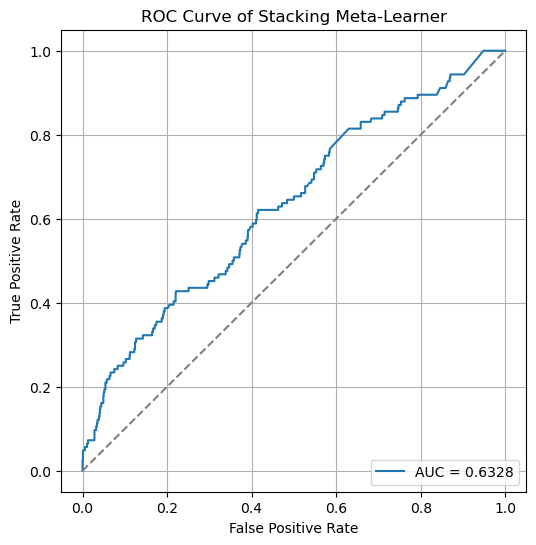

In [144]:
metrics_val_360_1364  = evaluate_meta_model_with_ci(y_val_1364, final_probs_LR_360_1364,  threshold=0.2)

AUC: 0.6853 (95% CI: 0.6337 - 0.7393)
Sensitivity: 0.9043 (95% CI: 0.8532 - 0.9535)
Specificity: 0.1691 (95% CI: 0.1479 - 0.1895)
PPV: 0.0982 (95% CI: 0.0823 - 0.1158)
NPV: 0.9464 (95% CI: 0.9155 - 0.9736)
F1-score: 0.1771 (95% CI: 0.1499 - 0.2055)
MCC: 0.0572 (95% CI: 0.0152 - 0.0966)
PR-AUC: 0.2435 (95% CI: 0.1719 - 0.3188)


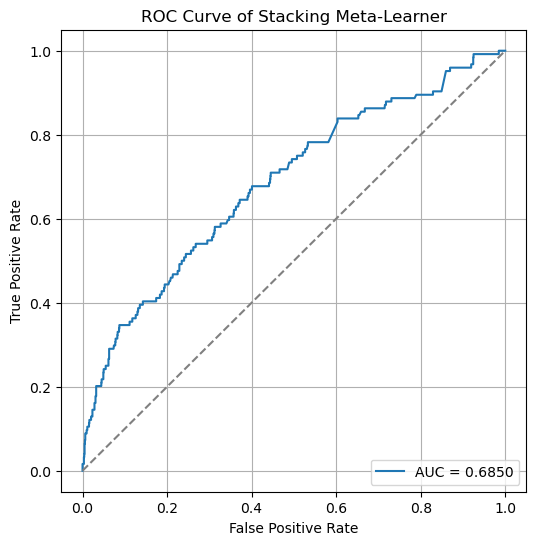

In [145]:
metrics_val_1980_1364 = evaluate_meta_model_with_ci(y_val_1364, final_probs_LR_1980_1364, threshold=0.2)

AUC: 0.6757 (95% CI: 0.6203 - 0.7294)
Sensitivity: 0.9762 (95% CI: 0.9455 - 1.0000)
Specificity: 0.0678 (95% CI: 0.0543 - 0.0820)
PPV: 0.0949 (95% CI: 0.0794 - 0.1122)
NPV: 0.9662 (95% CI: 0.9213 - 1.0000)
F1-score: 0.1728 (95% CI: 0.1468 - 0.2011)
MCC: 0.0517 (95% CI: 0.0113 - 0.0810)
PR-AUC: 0.2810 (95% CI: 0.2077 - 0.3603)


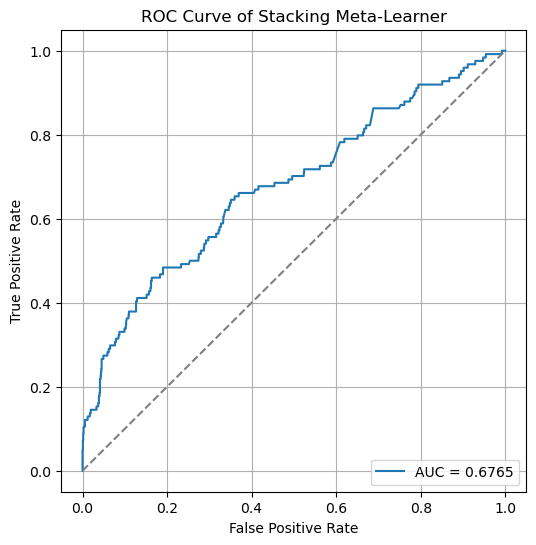

In [146]:
metrics_val_3780_1364 = evaluate_meta_model_with_ci(y_val_1364, final_probs_LR_3780_1364, threshold=0.2)

AUC: 0.6793 (95% CI: 0.6262 - 0.7326)
Sensitivity: 0.9678 (95% CI: 0.9338 - 0.9925)
Specificity: 0.1013 (95% CI: 0.0857 - 0.1183)
PPV: 0.0973 (95% CI: 0.0812 - 0.1147)
NPV: 0.9693 (95% CI: 0.9363 - 0.9928)
F1-score: 0.1767 (95% CI: 0.1500 - 0.2049)
MCC: 0.0677 (95% CI: 0.0328 - 0.0972)
PR-AUC: 0.2910 (95% CI: 0.2155 - 0.3664)


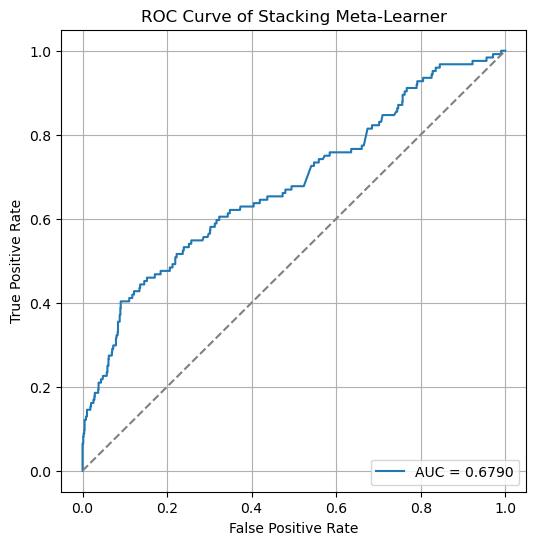

In [147]:
metrics_val_5580_1364 = evaluate_meta_model_with_ci(y_val_1364, final_probs_LR_5580_1364, threshold=0.2)

AUC: 0.6446 (95% CI: 0.5942 - 0.6966)
Sensitivity: 0.7166 (95% CI: 0.6357 - 0.7946)
Specificity: 0.4490 (95% CI: 0.4293 - 0.4691)
PPV: 0.0613 (95% CI: 0.0484 - 0.0739)
NPV: 0.9693 (95% CI: 0.9590 - 0.9791)
F1-score: 0.1129 (95% CI: 0.0905 - 0.1347)
MCC: 0.0711 (95% CI: 0.0337 - 0.1075)
PR-AUC: 0.1338 (95% CI: 0.0879 - 0.1908)


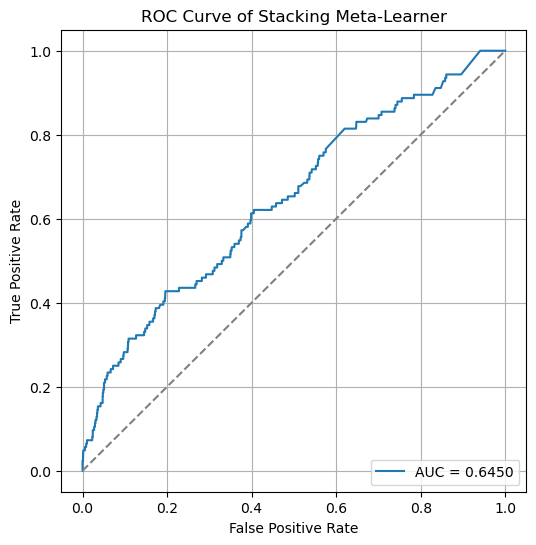

In [148]:
metrics_val_360_2604  = evaluate_meta_model_with_ci(y_val_2604, final_probs_LR_360_2604,  threshold=0.2)

AUC: 0.6951 (95% CI: 0.6449 - 0.7465)
Sensitivity: 0.9030 (95% CI: 0.8448 - 0.9531)
Specificity: 0.1869 (95% CI: 0.1715 - 0.2032)
PPV: 0.0528 (95% CI: 0.0429 - 0.0621)
NPV: 0.9746 (95% CI: 0.9590 - 0.9879)
F1-score: 0.0998 (95% CI: 0.0818 - 0.1163)
MCC: 0.0496 (95% CI: 0.0167 - 0.0794)
PR-AUC: 0.1661 (95% CI: 0.1110 - 0.2340)


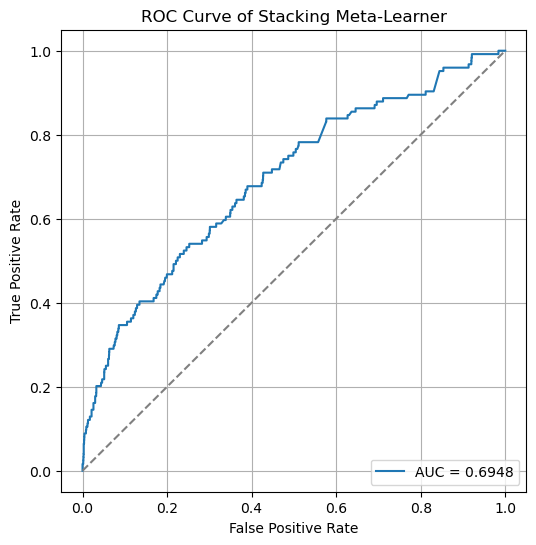

In [149]:
metrics_val_1980_2604 = evaluate_meta_model_with_ci(y_val_2604, final_probs_LR_1980_2604, threshold=0.2)

AUC: 0.6842 (95% CI: 0.6362 - 0.7351)
Sensitivity: 0.9763 (95% CI: 0.9470 - 1.0000)
Specificity: 0.0729 (95% CI: 0.0628 - 0.0827)
PPV: 0.0502 (95% CI: 0.0412 - 0.0585)
NPV: 0.9840 (95% CI: 0.9630 - 1.0000)
F1-score: 0.0955 (95% CI: 0.0791 - 0.1105)
MCC: 0.0410 (95% CI: 0.0145 - 0.0622)
PR-AUC: 0.2000 (95% CI: 0.1355 - 0.2673)


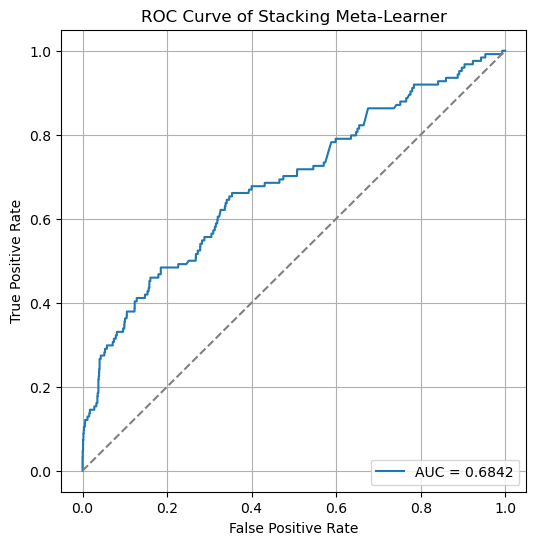

In [150]:
metrics_val_3780_2604 = evaluate_meta_model_with_ci(y_val_2604, final_probs_LR_3780_2604, threshold=0.2)

AUC: 0.6867 (95% CI: 0.6365 - 0.7399)
Sensitivity: 0.9688 (95% CI: 0.9348 - 1.0000)
Specificity: 0.1060 (95% CI: 0.0943 - 0.1183)
PPV: 0.0516 (95% CI: 0.0424 - 0.0601)
NPV: 0.9855 (95% CI: 0.9695 - 1.0000)
F1-score: 0.0980 (95% CI: 0.0812 - 0.1133)
MCC: 0.0526 (95% CI: 0.0267 - 0.0745)
PR-AUC: 0.2146 (95% CI: 0.1434 - 0.2857)


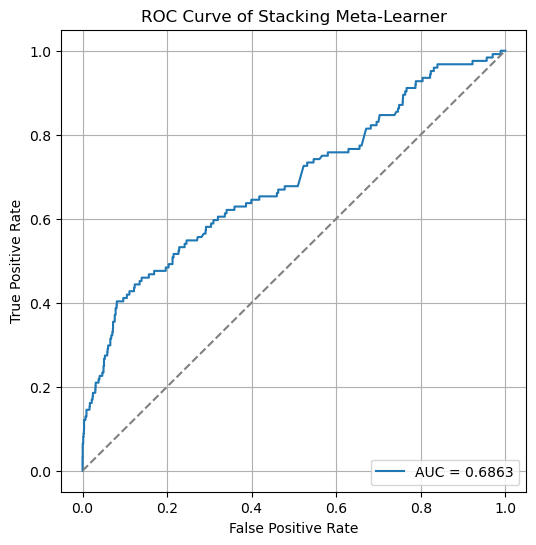

In [151]:
metrics_val_5580_2604 = evaluate_meta_model_with_ci(y_val_2604, final_probs_LR_5580_2604, threshold=0.2)

AUC: 0.6459 (95% CI: 0.5944 - 0.6946)
Sensitivity: 0.7180 (95% CI: 0.6423 - 0.7913)
Specificity: 0.4511 (95% CI: 0.4349 - 0.4670)
PPV: 0.0419 (95% CI: 0.0338 - 0.0509)
NPV: 0.9795 (95% CI: 0.9728 - 0.9859)
F1-score: 0.0791 (95% CI: 0.0645 - 0.0952)
MCC: 0.0601 (95% CI: 0.0312 - 0.0887)
PR-AUC: 0.1048 (95% CI: 0.0631 - 0.1527)


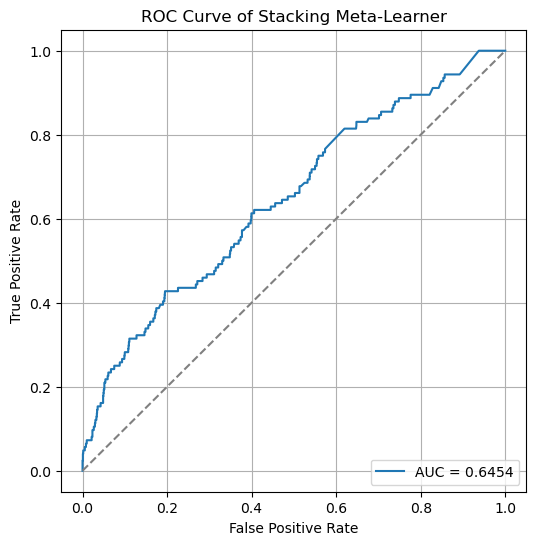

In [152]:
metrics_val_360_3844  = evaluate_meta_model_with_ci(y_val_3844, final_probs_LR_360_3844,  threshold=0.2)

AUC: 0.6942 (95% CI: 0.6443 - 0.7397)
Sensitivity: 0.9039 (95% CI: 0.8504 - 0.9524)
Specificity: 0.1881 (95% CI: 0.1762 - 0.1998)
PPV: 0.0358 (95% CI: 0.0293 - 0.0427)
NPV: 0.9832 (95% CI: 0.9739 - 0.9917)
F1-score: 0.0689 (95% CI: 0.0567 - 0.0817)
MCC: 0.0419 (95% CI: 0.0169 - 0.0649)
PR-AUC: 0.1157 (95% CI: 0.0733 - 0.1661)


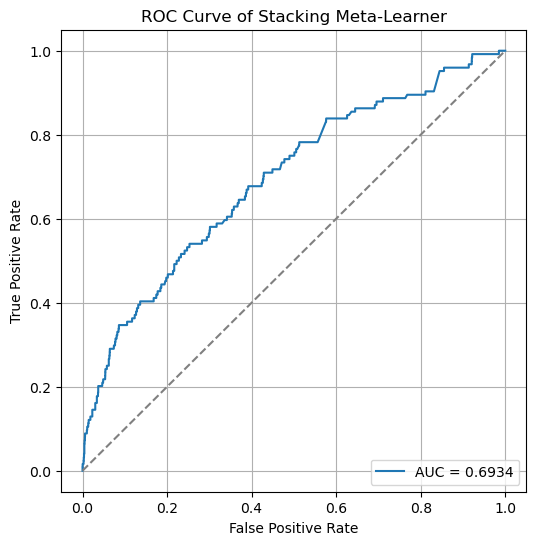

In [153]:
metrics_val_1980_3844 = evaluate_meta_model_with_ci(y_val_3844, final_probs_LR_1980_3844, threshold=0.2)

AUC: 0.6838 (95% CI: 0.6313 - 0.7332)
Sensitivity: 0.9757 (95% CI: 0.9444 - 1.0000)
Specificity: 0.0720 (95% CI: 0.0634 - 0.0808)
PPV: 0.0339 (95% CI: 0.0281 - 0.0403)
NPV: 0.9889 (95% CI: 0.9752 - 1.0000)
F1-score: 0.0655 (95% CI: 0.0547 - 0.0773)
MCC: 0.0329 (95% CI: 0.0126 - 0.0502)
PR-AUC: 0.1621 (95% CI: 0.0977 - 0.2288)


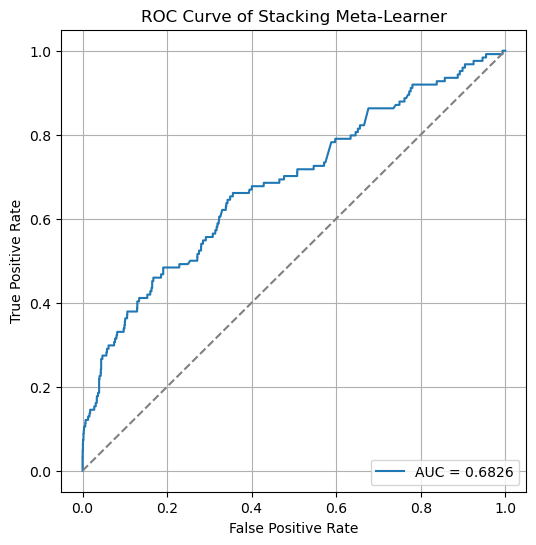

In [154]:
metrics_val_3780_3844 = evaluate_meta_model_with_ci(y_val_3844, final_probs_LR_3780_3844, threshold=0.2)

AUC: 0.6845 (95% CI: 0.6322 - 0.7343)
Sensitivity: 0.9277 (95% CI: 0.8780 - 0.9685)
Specificity: 0.2076 (95% CI: 0.1945 - 0.2210)
PPV: 0.0376 (95% CI: 0.0312 - 0.0449)
NPV: 0.9885 (95% CI: 0.9804 - 0.9949)
F1-score: 0.0723 (95% CI: 0.0603 - 0.0856)
MCC: 0.0594 (95% CI: 0.0365 - 0.0788)
PR-AUC: 0.1605 (95% CI: 0.0955 - 0.2264)


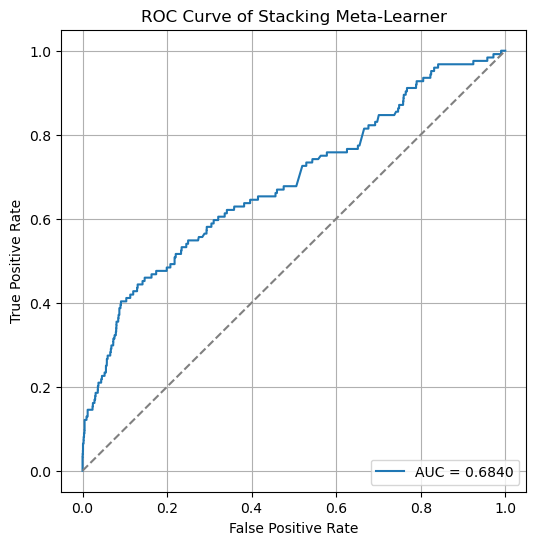

In [155]:
metrics_val_5580_3844 = evaluate_meta_model_with_ci(y_val_3844, final_probs_LR_5580_3844, threshold=0.3)

AUC: 0.6415 (95% CI: 0.5891 - 0.6889)
Sensitivity: 0.8959 (95% CI: 0.8425 - 0.9474)
Specificity: 0.1852 (95% CI: 0.1806 - 0.1897)
PPV: 0.0050 (95% CI: 0.0041 - 0.0060)
NPV: 0.9974 (95% CI: 0.9960 - 0.9988)
F1-score: 0.0099 (95% CI: 0.0081 - 0.0118)
MCC: 0.0140 (95% CI: 0.0047 - 0.0230)
PR-AUC: 0.0230 (95% CI: 0.0088 - 0.0484)


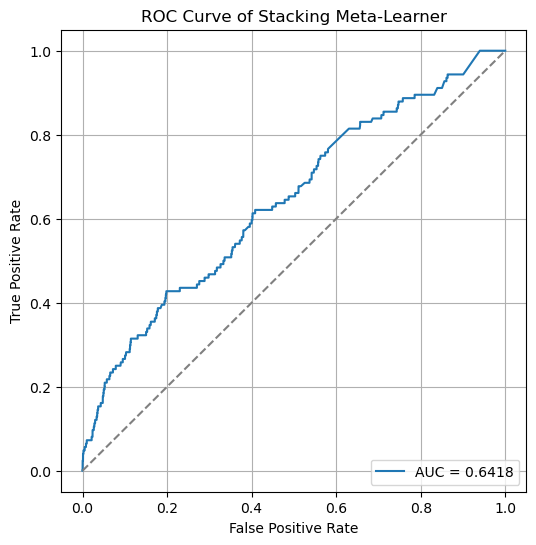

In [156]:
metrics_val_360_27156  = evaluate_meta_model_with_ci(y_val_27156, final_probs_LR_360_27156,  threshold=0.15)

AUC: 0.6895 (95% CI: 0.6398 - 0.7344)
Sensitivity: 0.8873 (95% CI: 0.8292 - 0.9417)
Specificity: 0.2802 (95% CI: 0.2747 - 0.2855)
PPV: 0.0056 (95% CI: 0.0046 - 0.0067)
NPV: 0.9982 (95% CI: 0.9972 - 0.9991)
F1-score: 0.0111 (95% CI: 0.0091 - 0.0133)
MCC: 0.0251 (95% CI: 0.0161 - 0.0333)
PR-AUC: 0.0174 (95% CI: 0.0102 - 0.0295)


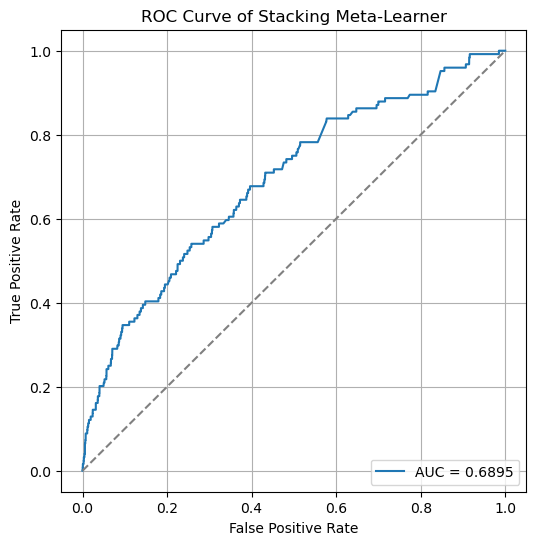

In [157]:
metrics_val_1980_27156 = evaluate_meta_model_with_ci(y_val_27156, final_probs_LR_1980_27156, threshold=0.22)

AUC: 0.6786 (95% CI: 0.6260 - 0.7276)
Sensitivity: 0.9351 (95% CI: 0.8860 - 0.9744)
Specificity: 0.1500 (95% CI: 0.1459 - 0.1543)
PPV: 0.0050 (95% CI: 0.0041 - 0.0059)
NPV: 0.9980 (95% CI: 0.9965 - 0.9993)
F1-score: 0.0100 (95% CI: 0.0082 - 0.0118)
MCC: 0.0160 (95% CI: 0.0066 - 0.0237)
PR-AUC: 0.0345 (95% CI: 0.0153 - 0.0651)


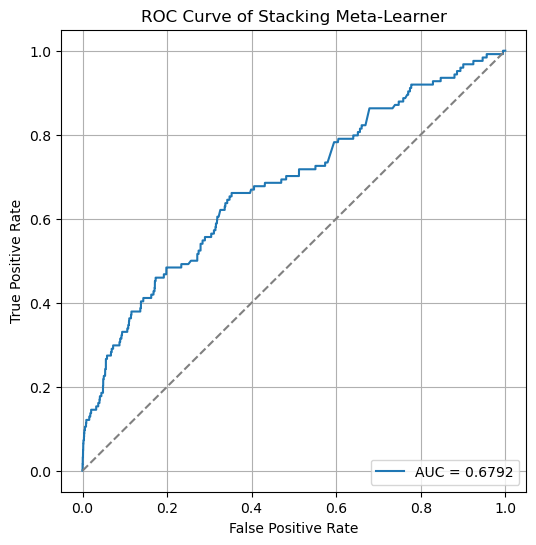

In [158]:
metrics_val_3780_27156 = evaluate_meta_model_with_ci(y_val_27156, final_probs_LR_3780_27156, threshold=0.25)

AUC: 0.6834 (95% CI: 0.6271 - 0.7371)
Sensitivity: 0.9268 (95% CI: 0.8788 - 0.9675)
Specificity: 0.2124 (95% CI: 0.2075 - 0.2170)
PPV: 0.0053 (95% CI: 0.0044 - 0.0063)
NPV: 0.9984 (95% CI: 0.9974 - 0.9993)
F1-score: 0.0106 (95% CI: 0.0087 - 0.0126)
MCC: 0.0229 (95% CI: 0.0147 - 0.0295)
PR-AUC: 0.0322 (95% CI: 0.0141 - 0.0602)


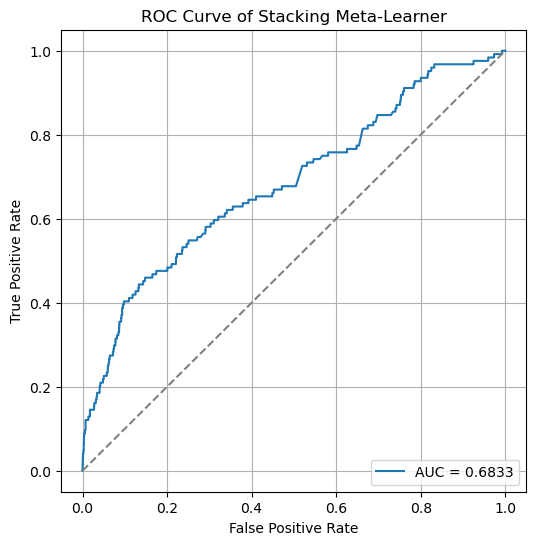

In [159]:
metrics_val_5580_27156 = evaluate_meta_model_with_ci(y_val_27156, final_probs_LR_5580_27156, threshold=0.3)

# 11. SHAP Interpretability

SHAP (SHapley Additive exPlanations) analysis for LightGBM model interpretation.

# 11a. Calibration and Decision Curve Analysis

Calibration curves, Brier scores, and decision curve analysis for clinical utility assessment.

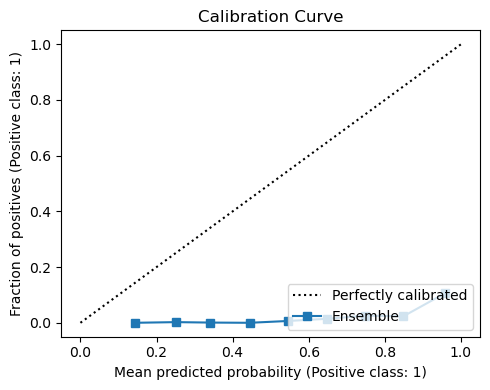

Brier Score: 0.1211


In [160]:
# Calibration Curve + Brier Score
fig, ax = plt.subplots(figsize=(5, 4))
CalibrationDisplay.from_predictions(y_test_7382, final_probs_LR_5580_7382, n_bins=10, ax=ax, name="Ensemble")
ax.set_title("Calibration Curve"); plt.tight_layout(); plt.show()
print(f"Brier Score: {brier_score_loss(y_test_7382, final_probs_LR_5580_7382):.4f}")

Optimal threshold (Youden's J): 0.5958


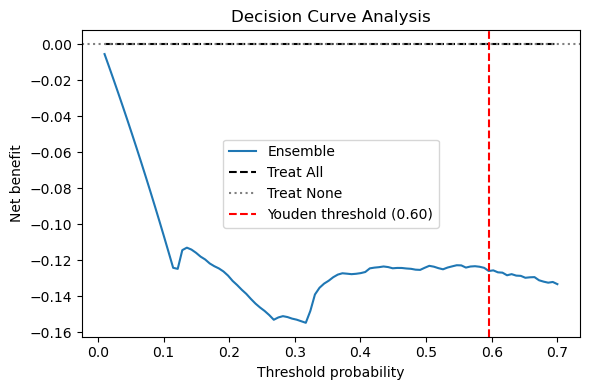

In [161]:
# Decision Curve Analysis
from sklearn.metrics import roc_curve

# Compute Youden's J optimal threshold
fpr, tpr, thresh = roc_curve(y_test_7382, final_probs_LR_5580_7382)
opt_thresh = thresh[np.argmax(tpr - fpr)]
print(f"Optimal threshold (Youden's J): {opt_thresh:.4f}")

# DCA
def dca(y_true, y_prob, thresholds=np.linspace(0.01, 0.70, 100)):
    net_benefit = []
    n = len(y_true)
    for t in thresholds:
        tp = ((y_prob >= t) & (y_true == 1)).sum()
        fp = ((y_prob >= t) & (y_true == 0)).sum()
        nb = tp/n - fp/n * (t/(1-t))
        net_benefit.append(nb)
    return thresholds, np.array(net_benefit)

t, nb = dca(y_test_7382, final_probs_LR_5580_7382)
plt.figure(figsize=(6, 4))
plt.plot(t, nb, label="Ensemble")
plt.plot(t, (y_test_7382.mean() - t/(1-t)*(1-y_test_7382.mean())).clip(0), 'k--', label="Treat All")
plt.axhline(0, color='gray', linestyle=':', label="Treat None")
plt.axvline(opt_thresh, color='red', linestyle='--', label=f"Youden threshold ({opt_thresh:.2f})")
plt.xlabel("Threshold probability"); plt.ylabel("Net benefit")
plt.title("Decision Curve Analysis"); plt.legend(); plt.tight_layout(); plt.show()

# 12. Meta-Learner SHAP Analysis

SHAP analysis through the full stacking pipeline (RF + LGBM + DNN → Meta-Learner) to attribute importance back to the original ICD-9 features.

In [194]:
feature_names = df_testing_7382.drop('CLASSIFIER', axis=1).columns.tolist()

def ensemble_predict_proba(X_raw):
    """Raw features → 3 base models → meta-learner → P(meningitis)."""
    X_np = np.array(X_raw, dtype=np.float32)
    p_rf = model_RF_5580.predict_proba(X_np)[:, 1]
    p_lgbm = model_LGBM_5580.predict_proba(X_np)[:, 1]
    X_t = torch.tensor(X_np).to(device)
    model_DNN_5580.eval()
    with torch.no_grad():
        p_dnn = torch.softmax(model_DNN_5580(X_t), dim=1)[:, 1].cpu().numpy()
    stack = np.column_stack([p_rf, p_lgbm, p_dnn])
    return meta_model_LR_5580.predict_proba(stack)[:, 1]

background = shap.sample(pd.DataFrame(X_test_7382, columns=feature_names), 50)
explainer_e2e = shap.KernelExplainer(ensemble_predict_proba, background)

X_explain = shap.sample(pd.DataFrame(X_test_7382, columns=feature_names), 300)
shap_vals_e2e = explainer_e2e.shap_values(X_explain, nsamples=300)
print("End-to-end SHAP shape:", shap_vals_e2e.shape)

  0%|          | 0/300 [00:00<?, ?it/s]

End-to-end SHAP shape: (300, 6969)


In [200]:
# Build SHAP Explanation object for reuse
base_val = float(explainer_e2e.expected_value)
exp_e2e = shap.Explanation(
    values=shap_vals_e2e,
    base_values=np.full(shap_vals_e2e.shape[0], base_val),
    data=X_explain.values,
    feature_names=feature_names
)

# Print top 10 features
mean_abs = np.abs(shap_vals_e2e).mean(axis=0)
top20_df = pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs}) \
    .sort_values("mean_abs_shap", ascending=False).head(10)
print("Top 10 Features (End-to-End Ensemble SHAP):")
print(top20_df.to_string(index=False))

Top 20 Features (End-to-End Ensemble SHAP):
feature  mean_abs_shap
  41401       0.045853
   V290       0.027717
  42731       0.011468
  53081       0.008354
  99592       0.007810
   3314       0.007286
    496       0.006431
  78039       0.006131
  51881       0.005933
   7907       0.005849


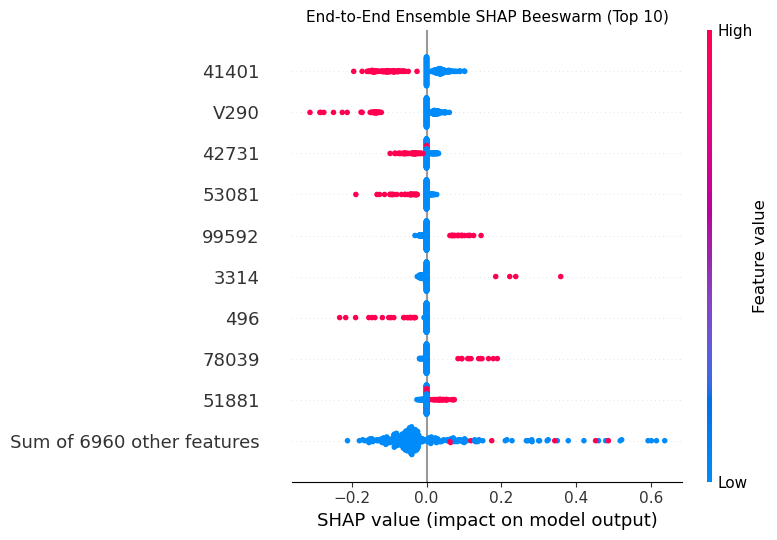

In [201]:
# Beeswarm — top 10 original features
plt.figure(figsize=(8, 6))
shap.plots.beeswarm(exp_e2e, max_display=10, show=False)
plt.title("End-to-End Ensemble SHAP Beeswarm (Top 10)", fontsize=11)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/shap_e2e_beeswarm.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{SAVE_DIR}/shap_e2e_beeswarm.pdf", dpi=300, bbox_inches="tight")
plt.show()

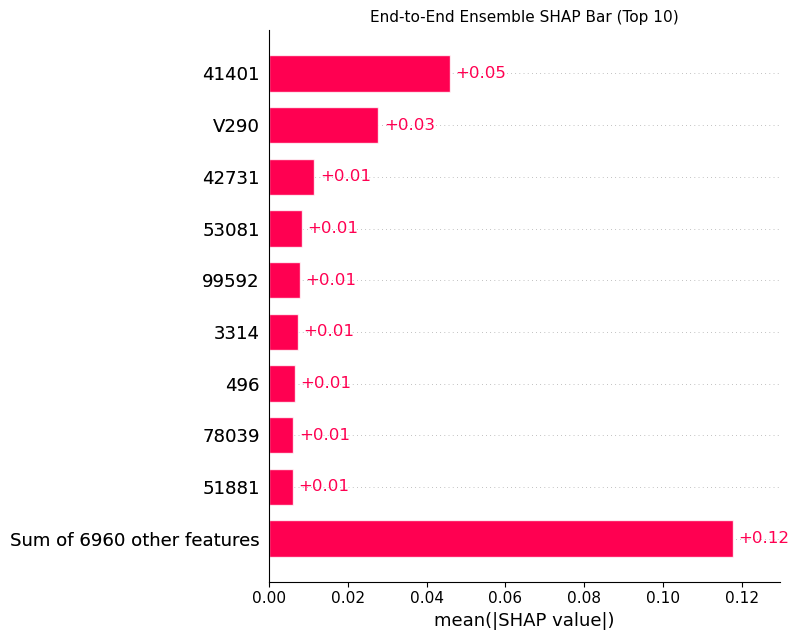

In [203]:
# Bar Plot — top 10 mean |SHAP|
plt.figure(figsize=(7, 5))
shap.plots.bar(exp_e2e, max_display=10, show=False)
plt.title("End-to-End Ensemble SHAP Bar (Top 10)", fontsize=11)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/shap_e2e_bar.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{SAVE_DIR}/shap_e2e_bar.pdf", dpi=300, bbox_inches="tight")
plt.show()

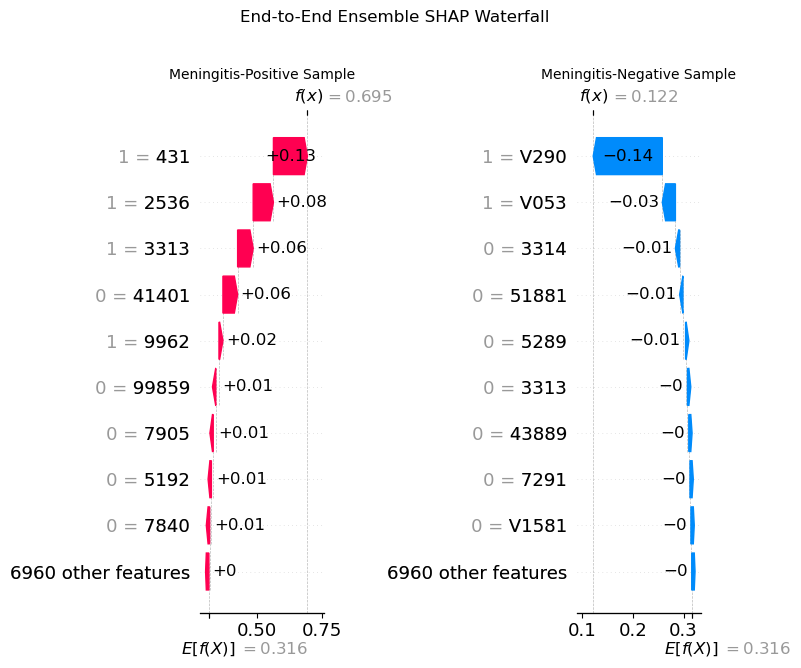

In [206]:
# Waterfall — one positive, one negative sample from explained subset
y_explain = y_test_7382[X_explain.index]
pos_idx = np.where(y_explain == 1)[0]
neg_idx = np.where(y_explain == 0)[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plt.sca(axes[0])
shap.plots.waterfall(exp_e2e[pos_idx[0]], max_display=10, show=False)
axes[0].set_title("Meningitis-Positive Sample", fontsize=10)
plt.sca(axes[1])
shap.plots.waterfall(exp_e2e[neg_idx[0]], max_display=10, show=False)
axes[1].set_title("Meningitis-Negative Sample", fontsize=10)
plt.suptitle("End-to-End Ensemble SHAP Waterfall", fontsize=12, y=1.02)
plt.suptitle("End-to-End Ensemble SHAP Waterfall", fontsize=12, y=1.02)
for ax in fig.get_axes():
    for text in ax.texts:
        text.set_color("black")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/shap_e2e_waterfall.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{SAVE_DIR}/shap_e2e_waterfall.pdf", dpi=300, bbox_inches="tight")
plt.show()

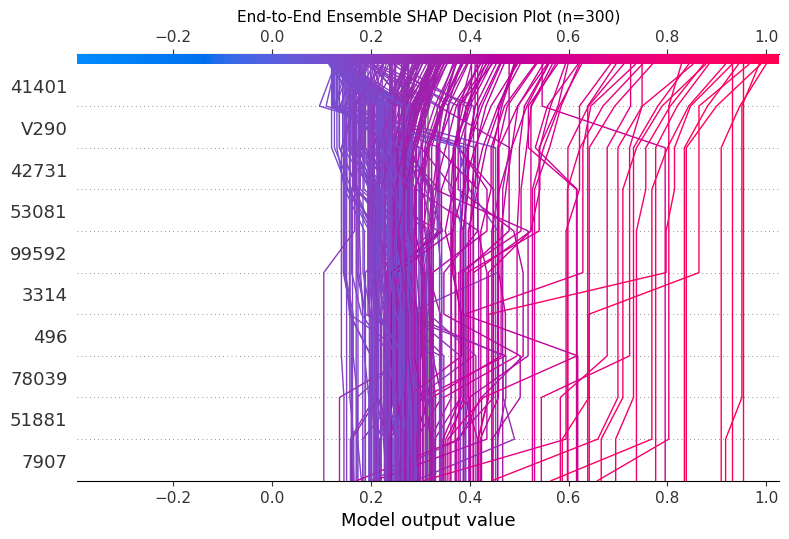

In [209]:
# Decision Plot — all explained samples, top 10 features
plt.figure(figsize=(8, 6))
shap.decision_plot(explainer_e2e.expected_value, shap_vals_e2e,
                   feature_names=feature_names,
                   feature_display_range=slice(-1, -11, -1),
                   show=False)
plt.title("End-to-End Ensemble SHAP Decision Plot (n=300)", fontsize=11)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/shap_e2e_decision.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{SAVE_DIR}/shap_e2e_decision.pdf", dpi=300, bbox_inches="tight")
plt.show()